# NHANES: 3-классовая классификация

- **0** — Здоров  
- **1** — Преддиабет  
- **2** — Диабет  

Данные: `nhanes_ml_ready.csv`. Feature engineering (Age×BMI, HOMA-IR и др.), Train/Test 80/20 (стратификация), `StandardScaler`, балансировка train через **SMOTEENN** (`imblearn`).

**Зависимости:** `pip install -r requirements-ml-notebook.txt` (или вручную: `imbalanced-learn`, `xgboost`, `lightgbm`, `catboost`).

Ниже — отдельный блок **сравнения методов балансировки** (без балансировки, **веса классов balanced**, SMOTE, ADASYN, BorderlineSMOTE, SMOTETomek, SMOTEENN) по метрикам на тесте.


In [2]:
from __future__ import annotations

import importlib.util
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from catboost import CatBoostClassifier
from imblearn.combine import SMOTEENN, SMOTETomek
from imblearn.over_sampling import ADASYN, BorderlineSMOTE, SMOTE
from lightgbm import LGBMClassifier
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    precision_recall_curve,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.svm import LinearSVC
from xgboost import XGBClassifier

# --- Конфиг ---
RANDOM_STATE = 42
TEST_SIZE = 0.2
TARGET_COL = "target"
DATA_PATH = Path("nhanes_ml_ready.csv")
MODELS_DIR = Path("models")
STANDARD_SCALER_PATH = Path("standard_scaler.joblib")
PHENOAGE_NHANES2021_PATH = MODELS_DIR / "phenoage_nhanes2021_2023_best_ridageyr.joblib"
MODELS_DIR.mkdir(exist_ok=True)

import numpy as np
import pandas as pd

# PhenoAge (Levine et al., 2018): единицы как в публикации; NHANES → см. комментарии ниже.
PHENOAGE_GAMMA = 0.0076927
PHENOAGE_LIN_INTERCEPT = -19.907
PHENOAGE_PHENO_INTERCEPT = 141.50225
PHENOAGE_PHENO_SLOPE = 0.090165
PHENOAGE_MORTALITY_INNER = -0.00553

# PhenoAge: в формуле xb участвует LBXGLU; включается в add_engineered_features при наличии всех PHENOAGE_INPUT_COLS.
PHENOAGE_INPUT_COLS: tuple[str, ...] = (
    "RIDAGEYR",
    "LBXSAL",
    "LBXSCR",
    "LBXGLU",
    "LBXCRP",
    "LBXLYPCT",
    "LBXMCVSI",
    "LBXRDW",
    "LBXSAPSI",
    "LBXWBCSI",
)


def phenoage_mortality_from_xb(xb: np.ndarray) -> np.ndarray:
    """10-летний риск смерти M по модели Гомперца (шаг 2a)."""
    xb = np.asarray(xb, dtype=float)
    b = (np.exp(120.0 * PHENOAGE_GAMMA) - 1.0) / PHENOAGE_GAMMA
    return 1.0 - np.exp(-np.exp(xb) * b)


def phenoage_years_from_mortality(m: np.ndarray) -> np.ndarray:
    """PhenoAge = 141.50225 + ln(-0.00553 * ln(1 - M)) / 0.090165 (шаг 2b)."""
    m = np.asarray(m, dtype=float)
    m = np.clip(m, 1e-12, 1.0 - 1e-12)
    inner = PHENOAGE_MORTALITY_INNER * np.log(1.0 - m)
    inner = np.maximum(inner, 1e-300)
    return PHENOAGE_PHENO_INTERCEPT + np.log(inner) / PHENOAGE_PHENO_SLOPE


def phenoage_xb_from_nhanes(out: pd.DataFrame) -> np.ndarray:
    """
    Линейный индекс xb: возраст (лет), альбумин (г/л), креатинин (мкмоль/л), глюкоза (ммоль/л),
    ln(CRP мг/л), лимфоциты %, MCV (фл), RDW %, ALP (Ед/л), WBC (10^9/л).
    NHANES: LBXSAL г/дл×10→г/л; LBXSCR мг/дл×88.42→мкмоль/л; LBXGLU мг/дл/18.0182→ммоль/л;
    LBXCRP мг/дл×10→мг/л.
    """
    age = pd.to_numeric(out["RIDAGEYR"], errors="coerce")
    albumin_gl = pd.to_numeric(out["LBXSAL"], errors="coerce") * 10.0
    creat_umol = pd.to_numeric(out["LBXSCR"], errors="coerce") * 88.42
    glucose_mmol = pd.to_numeric(out["LBXGLU"], errors="coerce") / 18.0182
    crp_mgl = pd.to_numeric(out["LBXCRP"], errors="coerce") * 10.0
    lymph = pd.to_numeric(out["LBXLYPCT"], errors="coerce")
    mcv = pd.to_numeric(out["LBXMCVSI"], errors="coerce")
    rdw = pd.to_numeric(out["LBXRDW"], errors="coerce")
    alp = pd.to_numeric(out["LBXSAPSI"], errors="coerce")
    wbc = pd.to_numeric(out["LBXWBCSI"], errors="coerce")
    log_crp = np.log(np.maximum(np.asarray(crp_mgl, dtype=float), 1e-6))
    xb = (
        PHENOAGE_LIN_INTERCEPT
        + 0.0804 * np.asarray(age, dtype=float)
        - 0.0336 * np.asarray(albumin_gl, dtype=float)
        + 0.0095 * np.asarray(creat_umol, dtype=float)
        + 0.1953 * np.asarray(glucose_mmol, dtype=float)
        + 0.0954 * log_crp
        - 0.0120 * np.asarray(lymph, dtype=float)
        + 0.0268 * np.asarray(mcv, dtype=float)
        + 0.3306 * np.asarray(rdw, dtype=float)
        + 0.00188 * np.asarray(alp, dtype=float)
        + 0.0554 * np.asarray(wbc, dtype=float)
    )
    bad = np.zeros(len(out), dtype=bool)
    for arr in (age, albumin_gl, creat_umol, glucose_mmol, crp_mgl, lymph, mcv, rdw, alp, wbc):
        bad |= np.asarray(pd.isna(arr))
    xb = np.where(bad, np.nan, xb)
    return xb


def add_engineered_features(frame: pd.DataFrame) -> pd.DataFrame:
    """Расширенный инжиниринг: производные признаки — здесь, не в build_nhanes_target_v2."""
    out = frame.copy()

    waist = pd.to_numeric(out["BMXWAIST"], errors="coerce")
    glu_mgdl = pd.to_numeric(out["LBXGLU"], errors="coerce")
    height_cm = pd.to_numeric(out.get("BMXHT"), errors="coerce")
    out["WHtR"] = waist / np.clip(height_cm, 1e-8, None)

    out["Age_x_WC"] = out["RIDAGEYR"] * waist
    out["Age_x_Glucose"] = out["RIDAGEYR"] * glu_mgdl

    if "LBXTR" in out.columns:
        tg = pd.to_numeric(out["LBXTR"], errors="coerce")
        out["TyG_Index"] = np.log(np.clip((tg * glu_mgdl) / 2.0, 1e-8, None))
    else:
        tc = pd.to_numeric(out["LBXTC"], errors="coerce")
        out["TyG_Index"] = np.log(np.clip((tc * glu_mgdl) / 2.0, 1e-8, None))

    out["TyG_WC"] = out["TyG_Index"] * waist

    if all(col in out.columns for col in ["LBXGLU", "LBXTR", "BMXWAIST", "LBDHDD"]):
        tg2 = pd.to_numeric(out["LBXTR"], errors="coerce")
        hdl = pd.to_numeric(out["LBDHDD"], errors="coerce")
        out["METS_IR"] = (np.log(2 * glu_mgdl + tg2) * waist) / np.log(np.clip(hdl, 1.0, None))

    if "LBXSAT" in out.columns and "LBXSASS" in out.columns:
        out["ALT_AST_Ratio"] = out["LBXSAT"] / (out["LBXSASS"] + 0.1)

    if "LBXCRP" in out.columns:
        out["Log_CRP"] = np.log1p(out["LBXCRP"])

    if "LBXSUA" in out.columns:
        out["Log_SUA"] = np.log1p(out["LBXSUA"])

    if "URXUMA" in out.columns:
        out["URXUMA"] = np.log1p(pd.to_numeric(out["URXUMA"], errors="coerce"))

    if all(c in out.columns for c in PHENOAGE_INPUT_COLS):
        xb = phenoage_xb_from_nhanes(out)
        pheno = np.full(len(out), np.nan, dtype=float)
        fin = np.isfinite(xb)
        if fin.any():
            pheno[fin] = phenoage_years_from_mortality(phenoage_mortality_from_xb(xb[fin]))
        out["PhenoAge"] = pheno
        out["PhenoAge_accel"] = out["PhenoAge"] - pd.to_numeric(out["RIDAGEYR"], errors="coerce")

    DROP_COLS = (
    "LBXSUA"
    # "Log_SUA",   # дубль LBXSUA
    "LBXCRP",    # дубль Log_CRP
    # "Log_CRP",   # дубль LBXCRP
    # "MSQ160E",
    # "MCQ160F",
    "LBXSCR",    # дубль eGFR; нужен только для PhenoAge — дропаем после
    # "LBXLYPCT",
    "PhenoAge",
    # "RIAGENDR",
    "SEQN"
    )
    out = out.drop(columns=[c for c in DROP_COLS if c in out.columns], errors="ignore")

    return out


np.random.seed(RANDOM_STATE)

# Проверка зависимостей (опционально — для понятной ошибки)
for pkg in ("imblearn", "xgboost", "lightgbm", "catboost"):
    if importlib.util.find_spec(pkg) is None:
        print(f"Установите пакет: pip install {pkg}", file=sys.stderr)

df = pd.read_csv(DATA_PATH)
_n_before_dedup = len(df)
df = df.drop_duplicates().reset_index(drop=True)
if len(df) < _n_before_dedup:
    print(
        f"Удалено полных дубликатов строк: {_n_before_dedup - len(df)} "
        f"(было {_n_before_dedup}, стало {len(df)})"
    )
df = add_engineered_features(df)
feature_cols = [c for c in df.columns if c != TARGET_COL]
X = df[feature_cols]
y = df[TARGET_COL].astype(int)

print(f"Строк: {len(df)}, признаков: {len(feature_cols)}")
print("Распределение target:\n", y.value_counts().sort_index())


Строк: 33882, признаков: 44
Распределение target:
 target
0    22722
1     7827
2     3333
Name: count, dtype: int64


In [3]:
# Дополнительные производные признаки (без изменения существующих колонок)

waist = pd.to_numeric(df["BMXWAIST"], errors="coerce")
if "BMXHT" in df.columns:
    height = pd.to_numeric(df["BMXHT"], errors="coerce")
    height_safe = np.maximum(np.asarray(height, dtype=float), 1e-8)
    whtr = np.asarray(waist, dtype=float) / height_safe
    whtr = np.clip(whtr, 0.3, 0.7)
else:
    whtr = np.full(len(df), np.nan, dtype=float)

triglycerides = pd.to_numeric(df["LBXTR"], errors="coerce")
glucose = pd.to_numeric(df["LBXGLU"], errors="coerce")
tyg = np.log(np.clip((np.asarray(triglycerides, dtype=float) * np.asarray(glucose, dtype=float)) / 2.0, 1e-8, None))
tyg = np.clip(tyg, 3.0, 7.0)

total_chol = pd.to_numeric(df["LBXTC"], errors="coerce")
hdl = pd.to_numeric(df["LBDHDD"], errors="coerce")
non_hdl = np.asarray(total_chol, dtype=float) - np.asarray(hdl, dtype=float)
non_hdl = np.clip(non_hdl, 50.0, 250.0)

if "WHtR" not in df.columns:
    df["WHtR"] = whtr
if "TyG" not in df.columns:
    df["TyG"] = tyg
if "non_HDL" not in df.columns:
    df["non_HDL"] = non_hdl

for col in ("WHtR", "TyG", "non_HDL"):
    if col in df.columns:
        print(f"{col} NaN value_counts:")
        print(df[col].isna().value_counts(dropna=False))
        print()

WHtR NaN value_counts:
WHtR
False    32394
True      1488
Name: count, dtype: int64

TyG NaN value_counts:
TyG
False    33274
True       608
Name: count, dtype: int64

non_HDL NaN value_counts:
non_HDL
False    33407
True       475
Name: count, dtype: int64



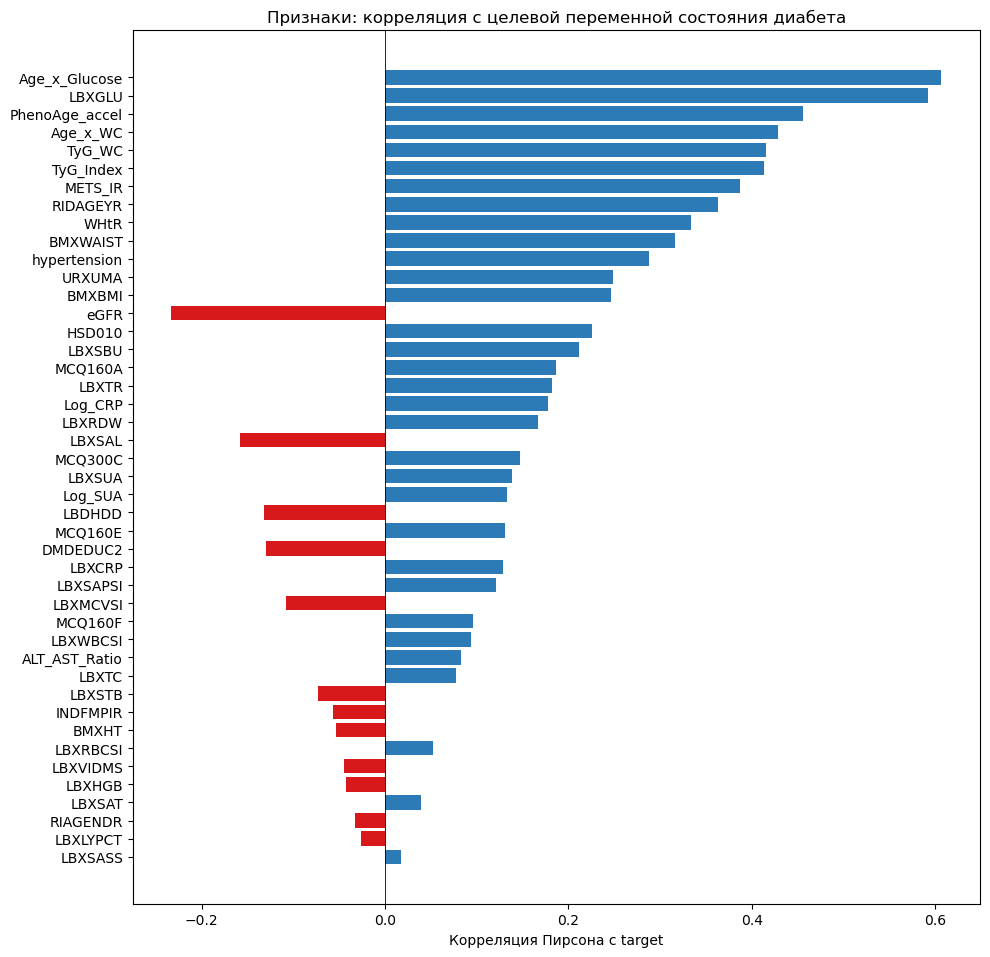

In [4]:
# Корреляция Пирсона числовых признаков с целевой переменной (состояние диабета: 0 — здоров, 1 — преддиабет, 2 — диабет)
_corr = (
    df[feature_cols]
    .select_dtypes(include=[np.number])
    .corrwith(df[TARGET_COL])
    .dropna()
)
_corr = _corr.reindex(_corr.abs().sort_values(ascending=False).index)

_h = max(6.0, 0.22 * len(_corr))
fig, ax = plt.subplots(figsize=(10, _h))
_colors = np.where(_corr.values >= 0.0, "#2c7bb6", "#d7191c")
ax.barh(_corr.index, _corr.values, color=_colors)
ax.axvline(0.0, color="black", linewidth=0.6)
ax.set_xlabel("Корреляция Пирсона с target")
ax.set_title("Признаки: корреляция с целевой переменной состояния диабета")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

### Feature engineering

Добавлены признаки: `Age_x_WC`, `Age_x_Glucose`, `HOMA_IR`, `Risk_Factor_Count`, `TyG_Index`, `TyG_WC`, `METS_IR`, `CRP_WC`.

**PhenoAge** (Levine et al., 2018): линейный индекс `xb` по возрасту и 9 маркерам (альбумин, креатинин, глюкоза, ln(CRP), лимфоциты %, MCV, RDW, ALP, WBC), затем 10-летний риск по Гомперцу и перевод в годы: `PhenoAge`, плюс **`PhenoAge_accel` = PhenoAge − возраст**. Единицы NHANES приведены к единицам формулы (альбумин г/дл→г/л, креатинин мг/дл→мкмоль/л, глюкоза мг/дл→ммоль/л, CRP мг/дл→мг/л). Нужны все колонки из `PHENOAGE_INPUT_COLS` в данных.

`TyG_Index = ln((TG * GLU) / 2)` при наличии `LBXTR`; иначе `TG = LBXTC`.

В `nhanes_ml_ready.csv`: **`LBXGLU`** (мг/дл), **`LBXIN`** = log1p(инсулин). **HOMA_IR**, **TyG_Index** и прочие производные считаются в `add_engineered_features` (HOMA через `expm1(LBXIN)`).


Сохранён скалер: /Users/yaroslav/Documents/diplom_nhames — обновление/standard_scaler.joblib
Train (до SMOTEENN): {0: 18177, 1: 6262, 2: 2666}
Train (после SMOTEENN): {0: 7076, 1: 15661, 2: 18096}
Test: {0: 4545, 1: 1565, 2: 667}
Сохранены: X_train_final.csv, X_test_final.csv, y_train_final.csv, y_test_final.csv


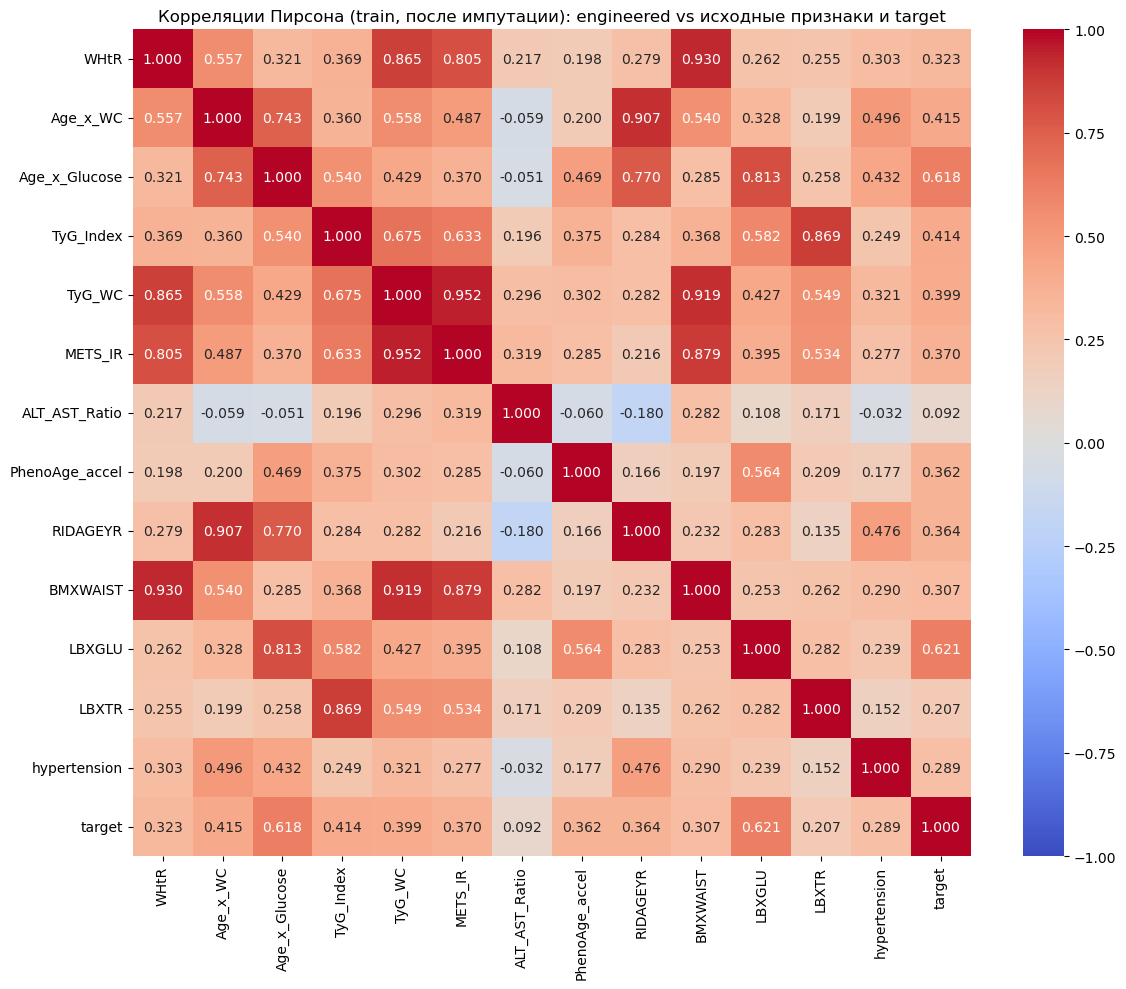


Engineered признаки: корреляции Пирсона с target
                pearson
Age_x_Glucose    0.6177
Age_x_WC         0.4153
TyG_Index        0.4136
TyG_WC           0.3991
METS_IR          0.3703
PhenoAge_accel   0.3624
WHtR             0.3226
ALT_AST_Ratio    0.0922

Engineered признаки: корреляции Спирмена с target
                spearman
Age_x_Glucose     0.5195
Age_x_WC          0.4274
TyG_WC            0.3719
METS_IR           0.3503
TyG_Index         0.3481
WHtR              0.3246
PhenoAge_accel    0.2750
ALT_AST_Ratio     0.0914

Сравнение Пирсон vs Спирмен для engineered признаков
                pearson  spearman   delta  abs_delta
Age_x_Glucose    0.6177    0.5195  0.0983     0.0983
Age_x_WC         0.4153    0.4274 -0.0121     0.0121
TyG_Index        0.4136    0.3481  0.0655     0.0655
TyG_WC           0.3991    0.3719  0.0272     0.0272
METS_IR          0.3703    0.3503  0.0200     0.0200
PhenoAge_accel   0.3624    0.2750  0.0874     0.0874
WHtR             0.3226    0.3246

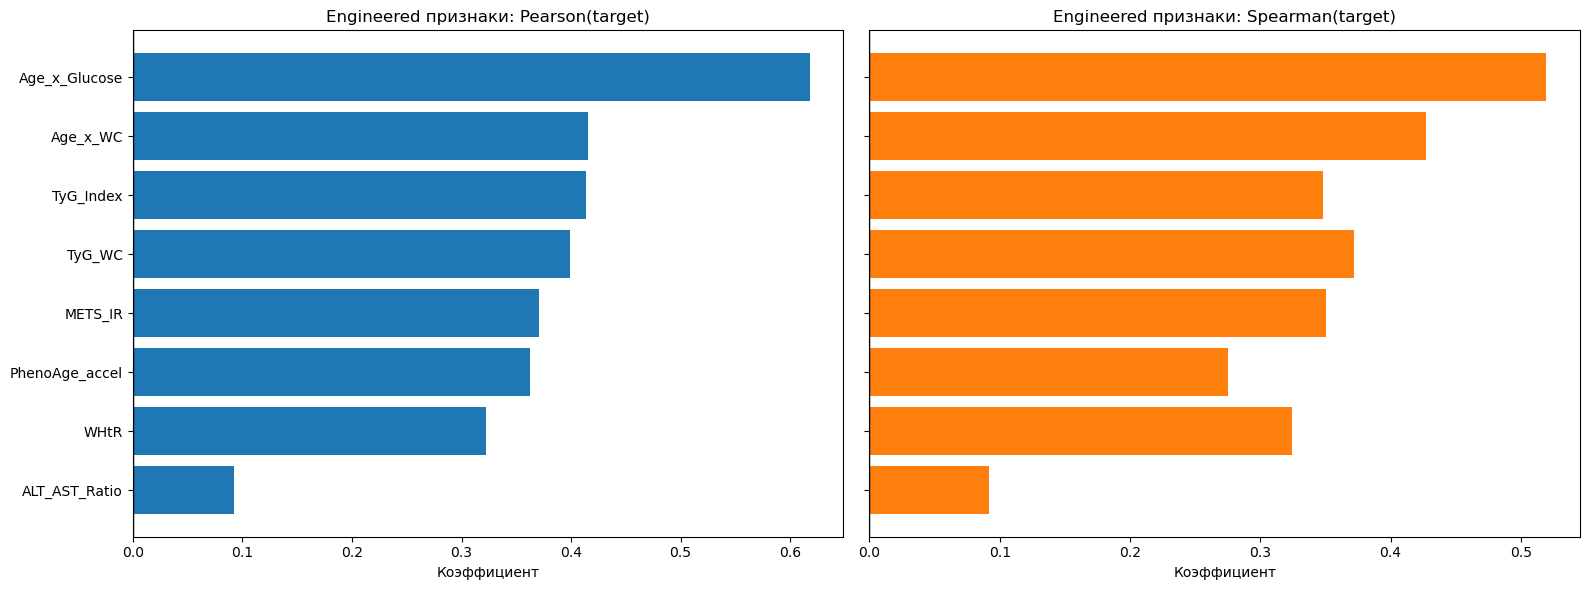

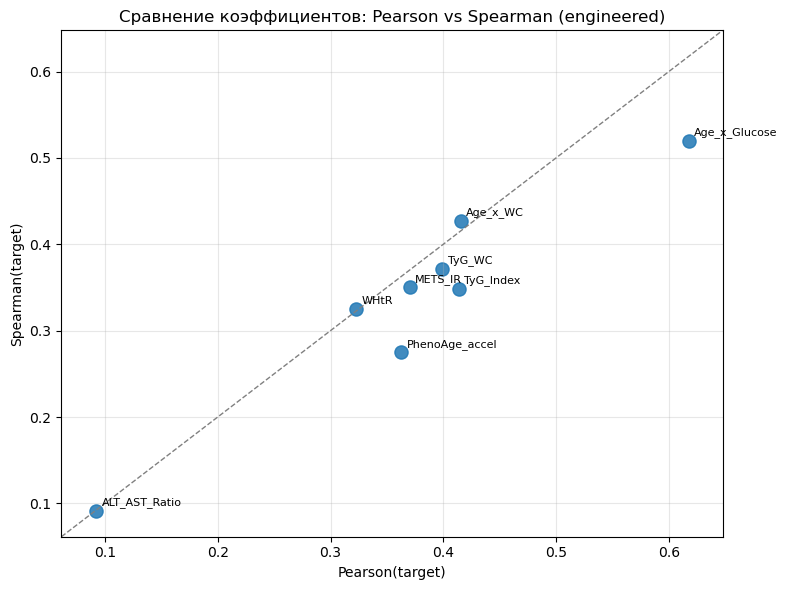


Корреляции Пирсона с target (|значение| по убыванию), все признаки:
LBXGLU            0.6209
Age_x_Glucose     0.6177
Age_x_WC          0.4153
TyG_Index         0.4136
TyG_WC            0.3991
METS_IR           0.3703
RIDAGEYR          0.3636
PhenoAge_accel    0.3624
WHtR              0.3226
BMXWAIST          0.3075
hypertension      0.2888
BMXBMI            0.2463
URXUMA            0.2425
eGFR             -0.2309
HSD010            0.2201
LBXSBU            0.2109
LBXTR             0.2066
LBXRDW            0.1872
MCQ160A           0.1871
LBXSAL           -0.1605
DMDEDUC2         -0.1554
MCQ300C           0.1476
LBXSAPSI          0.1394
LBXSUA            0.1382
Log_SUA           0.1353
LBDHDD           -0.1351
MCQ160E           0.1258
LBXCRP            0.1226
Log_CRP           0.1154
LBXMCVSI         -0.1126
LBXWBCSI          0.1042
MCQ160F           0.0980
ALT_AST_Ratio     0.0922
LBXTC             0.0794
LBXSTB           -0.0783
LBXSAT            0.0681
INDFMPIR         -0.0560
LBXRBC

In [5]:
from sklearn.preprocessing import RobustScaler

from build_nhanes_target_v2 import SKIP_PERCENTILE_CLIP, build_preprocessor


def replace_inf_with_nan(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    num_cols = out.select_dtypes(include=[np.number]).columns
    for col in num_cols:
        out[col] = pd.to_numeric(out[col], errors="coerce").replace([np.inf, -np.inf], np.nan)
    return out


def one_hot_ridreth1_train_test(
    X_tr: pd.DataFrame, X_te: pd.DataFrame
) -> tuple[pd.DataFrame, pd.DataFrame]:
    if "RIDRETH1" not in X_tr.columns:
        return X_tr, X_te
    X_tr_ohe = pd.get_dummies(X_tr, columns=["RIDRETH1"], prefix="RIDRETH1", dummy_na=True)
    X_te_ohe = pd.get_dummies(X_te, columns=["RIDRETH1"], prefix="RIDRETH1", dummy_na=True)
    X_te_ohe = X_te_ohe.reindex(columns=X_tr_ohe.columns, fill_value=0)
    return X_tr_ohe, X_te_ohe


X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

X_train = replace_inf_with_nan(X_train)
X_test = replace_inf_with_nan(X_test)

# Полностью исключаем расу из preprocessing и модели.
if "RIDRETH1" in X_train.columns:
    X_train = X_train.drop(columns=["RIDRETH1"])
if "RIDRETH1" in X_test.columns:
    X_test = X_test.drop(columns=["RIDRETH1"])

cat_cols = [c for c in ["DMDEDUC2"] if c in X_train.columns]
numeric_cols = [c for c in X_train.columns if c not in cat_cols]

preprocessor = build_preprocessor(
    X_train=X_train,
    numeric_cols=numeric_cols,
    categorical_cols=cat_cols,
    skip_percentile_clip=SKIP_PERCENTILE_CLIP,
)

X_train_prep = preprocessor.transform(X_train)
X_test_prep = preprocessor.transform(X_test)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_prep)
X_test_scaled = scaler.transform(X_test_prep)
joblib.dump(scaler, STANDARD_SCALER_PATH)
print(f"Сохранён скалер: {STANDARD_SCALER_PATH.resolve()}")

feature_cols = list(X_train_prep.columns)

smote_enn = SMOTEENN(random_state=RANDOM_STATE)
X_train_res, y_train_res = smote_enn.fit_resample(X_train_scaled, y_train)

print("Train (до SMOTEENN):", pd.Series(y_train).value_counts().sort_index().to_dict())
print("Train (после SMOTEENN):", pd.Series(y_train_res).value_counts().sort_index().to_dict())
print("Test:", pd.Series(y_test).value_counts().sort_index().to_dict())

pd.DataFrame(X_train_res, columns=feature_cols).to_csv("X_train_final.csv", index=False)
pd.DataFrame(X_test_scaled, columns=feature_cols).to_csv("X_test_final.csv", index=False)
pd.Series(y_train_res, name=TARGET_COL).to_csv("y_train_final.csv", index=False)
pd.Series(y_test, name=TARGET_COL).to_csv("y_test_final.csv", index=False)
print(
    "Сохранены: X_train_final.csv, X_test_final.csv, y_train_final.csv, y_test_final.csv"
)

# Корреляции (train после импутации, до StandardScaler): новые vs исходные и target
corr_train = X_train_prep.copy()
corr_train[TARGET_COL] = y_train.values
corr_full = corr_train.select_dtypes(include=[np.number]).corr(method="pearson")
eng_candidates = [
    "WHtR",
    "Age_x_WC",
    "Age_x_Glucose",
    "HOMA_IR",
    "TyG_Index",
    "TyG_WC",
    "METS_IR",
    "ALT_AST_Ratio",
    "PhenoAge_accel",
    "Log_URXUMA",
]
base_cols = ["RIDAGEYR", "BMXWAIST", "LBXGLU", "LBXTR", "hypertension"]
eng_cols = [c for c in eng_candidates if c in corr_train.columns]

heatmap_cols = [c for c in eng_cols + base_cols + [TARGET_COL] if c in corr_full.columns]
corr_subset = corr_full.loc[heatmap_cols, heatmap_cols]

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr_subset,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
)
plt.title(
    "Корреляции Пирсона (train, после импутации): engineered vs исходные признаки и target"
)
plt.tight_layout()
plt.show()

if TARGET_COL in corr_train.columns and eng_cols:
    corr_pearson = corr_train[eng_cols + [TARGET_COL]].corr(method="pearson")[TARGET_COL].drop(TARGET_COL)
    corr_spearman = corr_train[eng_cols + [TARGET_COL]].corr(method="spearman")[TARGET_COL].drop(TARGET_COL)

    pearson_df = (
        corr_pearson.reindex(corr_pearson.abs().sort_values(ascending=False).index)
        .rename("pearson")
        .to_frame()
        .round(4)
    )
    spearman_df = (
        corr_spearman.reindex(corr_spearman.abs().sort_values(ascending=False).index)
        .rename("spearman")
        .to_frame()
        .round(4)
    )

    compare_df = (
        pd.concat([corr_pearson.rename("pearson"), corr_spearman.rename("spearman")], axis=1)
        .assign(
            abs_pearson=lambda d: d["pearson"].abs(),
            abs_spearman=lambda d: d["spearman"].abs(),
            delta=lambda d: d["pearson"] - d["spearman"],
            abs_delta=lambda d: d["delta"].abs(),
        )
        .sort_values("abs_pearson", ascending=False)
        .round(4)
    )

    print("\nEngineered признаки: корреляции Пирсона с target")
    print(pearson_df.to_string())

    print("\nEngineered признаки: корреляции Спирмена с target")
    print(spearman_df.to_string())

    print("\nСравнение Пирсон vs Спирмен для engineered признаков")
    print(compare_df[["pearson", "spearman", "delta", "abs_delta"]].to_string())

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

    pearson_plot = pearson_df.sort_values("pearson")
    axes[0].barh(pearson_plot.index, pearson_plot["pearson"], color="#1f77b4")
    axes[0].axvline(0, color="black", linewidth=1)
    axes[0].set_title("Engineered признаки: Pearson(target)")
    axes[0].set_xlabel("Коэффициент")

    spearman_plot = spearman_df.sort_values("spearman")
    axes[1].barh(spearman_plot.index, spearman_plot["spearman"], color="#ff7f0e")
    axes[1].axvline(0, color="black", linewidth=1)
    axes[1].set_title("Engineered признаки: Spearman(target)")
    axes[1].set_xlabel("Коэффициент")

    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, 6))
    plt.scatter(compare_df["pearson"], compare_df["spearman"], s=90, alpha=0.85)
    for feature_name, row in compare_df.iterrows():
        plt.annotate(feature_name, (row["pearson"], row["spearman"]), fontsize=8, xytext=(4, 4), textcoords="offset points")
    lim_min = float(min(compare_df["pearson"].min(), compare_df["spearman"].min()) - 0.03)
    lim_max = float(max(compare_df["pearson"].max(), compare_df["spearman"].max()) + 0.03)
    plt.plot([lim_min, lim_max], [lim_min, lim_max], linestyle="--", color="gray", linewidth=1)
    plt.xlim(lim_min, lim_max)
    plt.ylim(lim_min, lim_max)
    plt.xlabel("Pearson(target)")
    plt.ylabel("Spearman(target)")
    plt.title("Сравнение коэффициентов: Pearson vs Spearman (engineered)")
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

if TARGET_COL in corr_full.columns:
    tgt = corr_full[TARGET_COL].drop(TARGET_COL)
    print("\nКорреляции Пирсона с target (|значение| по убыванию), все признаки:")
    _tgt_sorted = tgt.reindex(tgt.abs().sort_values(ascending=False).index).round(4)
    print(_tgt_sorted.to_string())
    eng_idx = [c for c in eng_cols if c in corr_full.index]
    base_idx = [c for c in base_cols if c in corr_full.index]
    print("\nСравнение корреляций Пирсона с target: engineered vs базовые признаки")
    print(
        pd.concat(
            [
                pd.DataFrame(
                    {"corr_with_target": [corr_full.loc[c, TARGET_COL] for c in eng_idx]},
                    index=eng_idx,
                ).assign(group="engineered"),
                pd.DataFrame(
                    {"corr_with_target": [corr_full.loc[c, TARGET_COL] for c in base_idx]},
                    index=base_idx,
                ).assign(group="base"),
            ]
        ).round(4)
    )



In [6]:
def _model_feature_count(model) -> int | None:
    if hasattr(model, "n_features_in_"):
        return int(model.n_features_in_)
    if hasattr(model, "feature_count_"):
        return int(model.feature_count_)
    return None


def load_or_train(name: str, path: Path, model_fn, fit_x, fit_y):
    path = Path(path)
    expected_features = int(fit_x.shape[1])

    if path.exists():
        print(f"Загрузка: {name} ← {path}")

        if path.suffix == ".cbm":
            loaded_model = CatBoostClassifier()
            loaded_model.load_model(str(path))
        elif path.suffix == ".json":
            loaded_model = XGBClassifier()
            loaded_model.load_model(str(path))
        else:
            loaded_model = joblib.load(path)

        loaded_features = _model_feature_count(loaded_model)
        if loaded_features is None or loaded_features == expected_features:
            return loaded_model

        print(
            f"Переобучение: {name} (features: {loaded_features} -> {expected_features})"
        )
    else:
        print(f"Обучение: {name} ...")

    model = model_fn()
    model.fit(fit_x, fit_y)

    if path.suffix == ".cbm":
        model.save_model(str(path))
    elif path.suffix == ".json":
        model.save_model(str(path))
    else:
        joblib.dump(model, path)

    return model


models: dict[str, object] = {}

models["LogisticRegression"] = load_or_train(
    "LogisticRegression",
    MODELS_DIR / "logistic_regression.joblib",
    lambda: LogisticRegression(
        max_iter=2000,
        random_state=RANDOM_STATE,
        multi_class="multinomial",
        solver="lbfgs",
    ),
    X_train_res,
    y_train_res,
)

models["RandomForest"] = load_or_train(
    "RandomForest",
    MODELS_DIR / "random_forest.joblib",
    lambda: RandomForestClassifier(
        n_estimators=300,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        class_weight=None,
    ),
    X_train_res,
    y_train_res,
)

models["XGBoost"] = load_or_train(
    "XGBoost",
    MODELS_DIR / "xgboost.json",
    lambda: XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.1,
        objective="multi:softprob",
        num_class=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        eval_metric="mlogloss",
    ),
    X_train_res,
    y_train_res,
)

models["LightGBM"] = load_or_train(
    "LightGBM",
    MODELS_DIR / "lightgbm.joblib",
    lambda: LGBMClassifier(
        n_estimators=300,
        max_depth=-1,
        learning_rate=0.1,
        objective="multiclass",
        num_class=3,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1,
    ),
    X_train_res,
    y_train_res,
)

models["CatBoost"] = load_or_train(
    "CatBoost",
    MODELS_DIR / "catboost.cbm",
    lambda: CatBoostClassifier(
        iterations=400,
        depth=6,
        learning_rate=0.1,
        loss_function="MultiClass",
        random_seed=RANDOM_STATE,
        verbose=False,
    ),
    X_train_res,
    y_train_res,
)

models["LinearSVC"] = load_or_train(
    "LinearSVC",
    MODELS_DIR / "linear_svc.joblib",
    lambda: LinearSVC(
        dual=False,
        random_state=RANDOM_STATE,
        max_iter=5000,
    ),
    X_train_res,
    y_train_res,
)

print("Готово. Моделей:", list(models.keys()))


Загрузка: LogisticRegression ← models/logistic_regression.joblib
Загрузка: RandomForest ← models/random_forest.joblib
Загрузка: XGBoost ← models/xgboost.json
Загрузка: LightGBM ← models/lightgbm.joblib
Загрузка: CatBoost ← models/catboost.cbm
Переобучение: CatBoost (features: 0 -> 44)
Загрузка: LinearSVC ← models/linear_svc.joblib
Готово. Моделей: ['LogisticRegression', 'RandomForest', 'XGBoost', 'LightGBM', 'CatBoost', 'LinearSVC']



Модель: LogisticRegression

Classification Report:

                precision    recall  f1-score   support

    Здоров (0)     0.9407    0.4785    0.6344      4545
Преддиабет (1)     0.3336    0.7502    0.4618      1565
    Диабет (2)     0.5719    0.8111    0.6708       667

      accuracy                         0.5740      6777
     macro avg     0.6154    0.6799    0.5890      6777
  weighted avg     0.7642    0.5740    0.5981      6777


>>> Класс 1 (Преддиабет): Precision=0.3336  Recall=0.7502  F1=0.4618

Balanced Accuracy: 0.6799
MCC: 0.3931
One-vs-Rest ROC-AUC по классам:
  Класс 0: 0.8474
  Класс 1: 0.6971
  Класс 2: 0.9506


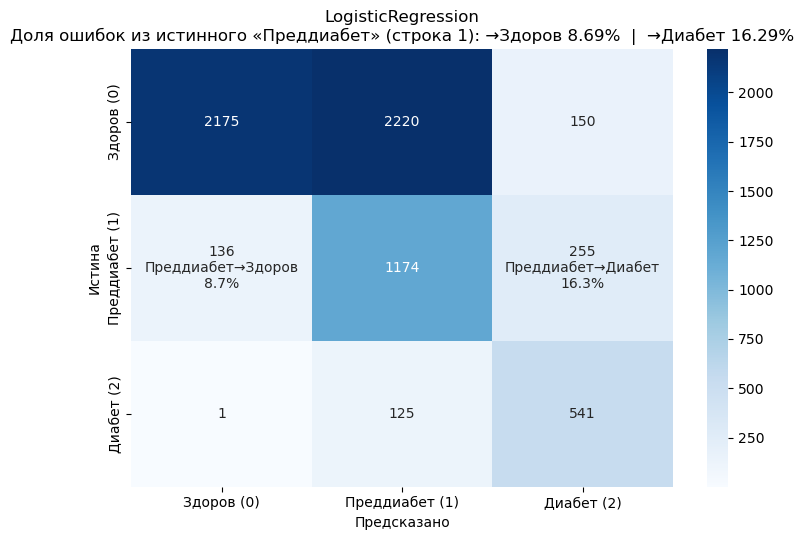


Модель: RandomForest

Classification Report:

                precision    recall  f1-score   support

    Здоров (0)     0.9340    0.5234    0.6709      4545
Преддиабет (1)     0.3533    0.7681    0.4840      1565
    Диабет (2)     0.6256    0.7766    0.6930       667

      accuracy                         0.6048      6777
     macro avg     0.6377    0.6894    0.6160      6777
  weighted avg     0.7696    0.6048    0.6299      6777


>>> Класс 1 (Преддиабет): Precision=0.3533  Recall=0.7681  F1=0.4840

Balanced Accuracy: 0.6894
MCC: 0.4187
One-vs-Rest ROC-AUC по классам:
  Класс 0: 0.8425
  Класс 1: 0.7259
  Класс 2: 0.9573


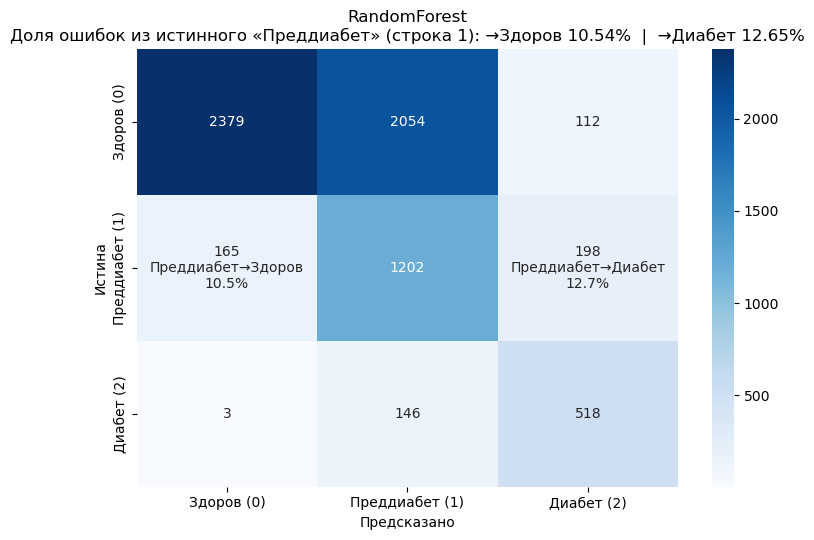


Модель: XGBoost

Classification Report:

                precision    recall  f1-score   support

    Здоров (0)     0.9269    0.6055    0.7325      4545
Преддиабет (1)     0.3877    0.7508    0.5113      1565
    Диабет (2)     0.6667    0.7766    0.7175       667

      accuracy                         0.6559      6777
     macro avg     0.6604    0.7110    0.6538      6777
  weighted avg     0.7768    0.6559    0.6799      6777


>>> Класс 1 (Преддиабет): Precision=0.3877  Recall=0.7508  F1=0.5113

Balanced Accuracy: 0.7110
MCC: 0.4598
One-vs-Rest ROC-AUC по классам:
  Класс 0: 0.8559
  Класс 1: 0.7502
  Класс 2: 0.9560


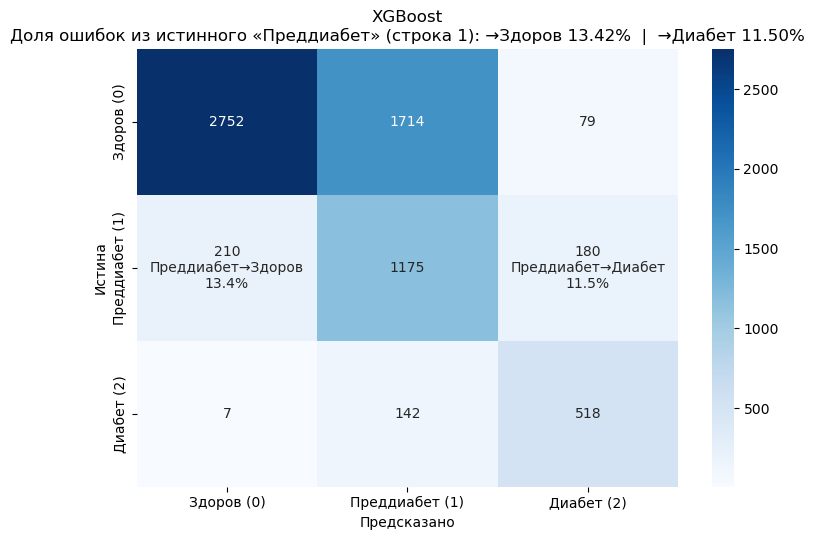


Модель: LightGBM

Classification Report:

                precision    recall  f1-score   support

    Здоров (0)     0.9221    0.6123    0.7360      4545
Преддиабет (1)     0.3887    0.7412    0.5100      1565
    Диабет (2)     0.6671    0.7751    0.7171       667

      accuracy                         0.6581      6777
     macro avg     0.6593    0.7095    0.6543      6777
  weighted avg     0.7739    0.6581    0.6819      6777


>>> Класс 1 (Преддиабет): Precision=0.3887  Recall=0.7412  F1=0.5100

Balanced Accuracy: 0.7095
MCC: 0.4580
One-vs-Rest ROC-AUC по классам:
  Класс 0: 0.8566
  Класс 1: 0.7514
  Класс 2: 0.9556


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


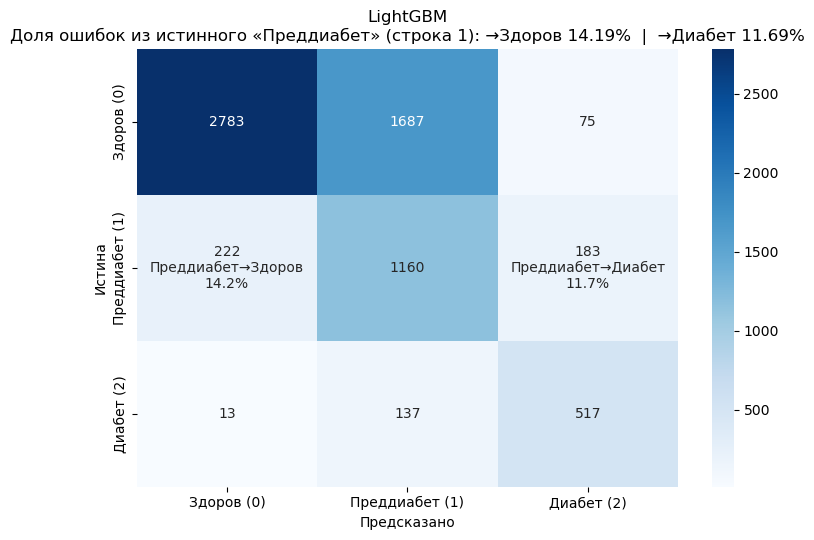


Модель: CatBoost

Classification Report:

                precision    recall  f1-score   support

    Здоров (0)     0.9299    0.5630    0.7014      4545
Преддиабет (1)     0.3649    0.7470    0.4902      1565
    Диабет (2)     0.6407    0.7886    0.7070       667

      accuracy                         0.6277      6777
     macro avg     0.6451    0.6995    0.6329      6777
  weighted avg     0.7709    0.6277    0.6532      6777


>>> Класс 1 (Преддиабет): Precision=0.3649  Recall=0.7470  F1=0.4902

Balanced Accuracy: 0.6995
MCC: 0.4344
One-vs-Rest ROC-AUC по классам:
  Класс 0: 0.8574
  Класс 1: 0.7405
  Класс 2: 0.9576


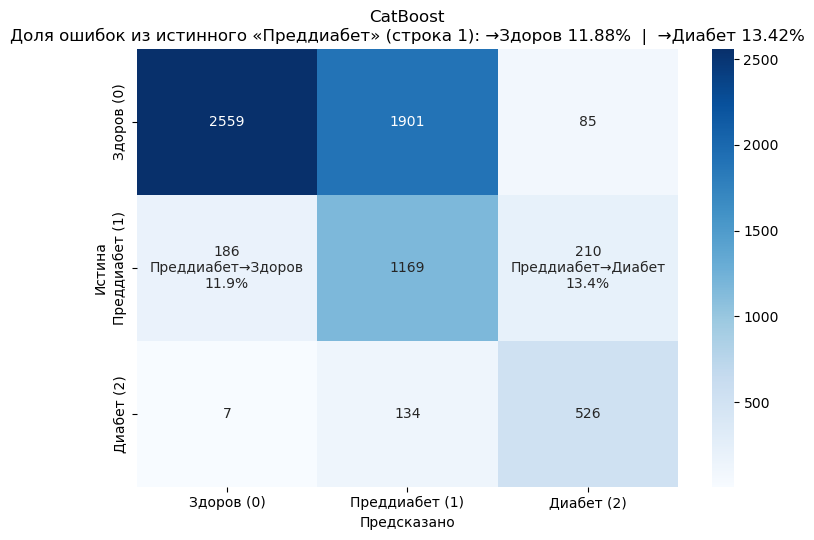


Модель: LinearSVC

Classification Report:

                precision    recall  f1-score   support

    Здоров (0)     0.9408    0.4823    0.6377      4545
Преддиабет (1)     0.3393    0.7495    0.4671      1565
    Диабет (2)     0.5394    0.8006    0.6445       667

      accuracy                         0.5753      6777
     macro avg     0.6065    0.6775    0.5831      6777
  weighted avg     0.7624    0.5753    0.5990      6777


>>> Класс 1 (Преддиабет): Precision=0.3393  Recall=0.7495  F1=0.4671

Balanced Accuracy: 0.6775
MCC: 0.3931
One-vs-Rest ROC-AUC по классам:
  Класс 0: 0.8404
  Класс 1: 0.7017
  Класс 2: 0.9418


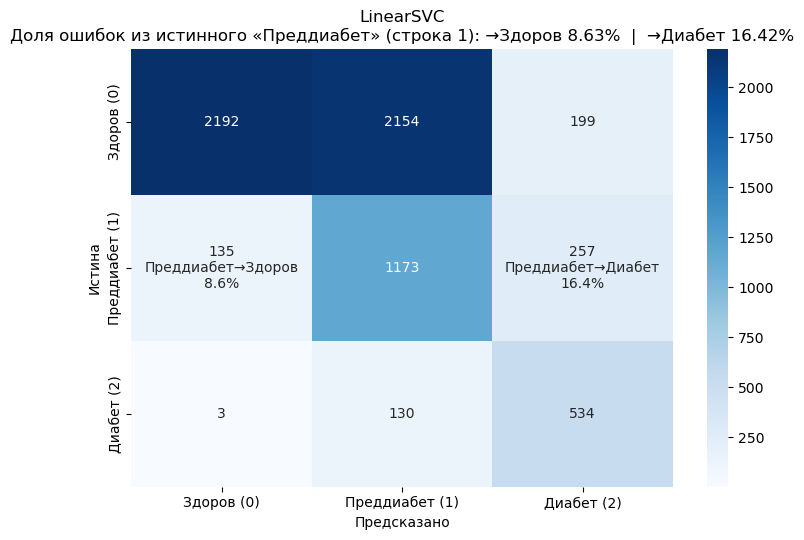

In [7]:
LABELS = [0, 1, 2]
CLASS_NAMES = ["Здоров (0)", "Преддиабет (1)", "Диабет (2)"]


def _softmax_rows(scores: np.ndarray) -> np.ndarray:
    """Стабильный softmax по строкам (для decision_function → вероятности)."""
    s = np.asarray(scores, dtype=float)
    if s.ndim == 1:
        s = s.reshape(-1, 1)
    s = s - np.max(s, axis=1, keepdims=True)
    e = np.exp(s)
    return e / e.sum(axis=1, keepdims=True)


def get_scores_matrix(model, X) -> np.ndarray:
    """Вероятности по классам: predict_proba или softmax(decision_function).
    sklearn multiclass roc_auc требует, чтобы строки суммировались в 1.0."""
    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X), dtype=float)
    if hasattr(model, "decision_function"):
        s = model.decision_function(X)
        if s.ndim == 1:
            s = np.column_stack([-s, s])
        return _softmax_rows(s)
    raise TypeError("Нужны predict_proba или decision_function")


def roc_auc_ovr_per_class(y_true, y_score) -> dict[int, float]:
    aucs = roc_auc_score(
        y_true,
        y_score,
        multi_class="ovr",
        average=None,
        labels=LABELS,
    )
    return {int(l): float(a) for l, a in zip(LABELS, aucs)}



results_rows: list[dict] = []
scores_cache: dict[str, np.ndarray] = {}

for model_name, model in models.items():
    print("\n" + "=" * 72)
    print(f"Модель: {model_name}")
    print("=" * 72)

    y_pred = model.predict(X_test_scaled)
    y_score = get_scores_matrix(model, X_test_scaled)
    scores_cache[model_name] = y_score

    report = classification_report(
        y_test,
        y_pred,
        labels=LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
    print("\nClassification Report:\n")
    print(report)

    rep_dict = classification_report(
        y_test,
        y_pred,
        labels=LABELS,
        target_names=CLASS_NAMES,
        output_dict=True,
        zero_division=0,
    )
    p0 = rep_dict["Здоров (0)"]["precision"]
    r0 = rep_dict["Здоров (0)"]["recall"]
    f1_0 = rep_dict["Здоров (0)"]["f1-score"]
    p1 = rep_dict["Преддиабет (1)"]["precision"]
    r1 = rep_dict["Преддиабет (1)"]["recall"]
    f1_1 = rep_dict["Преддиабет (1)"]["f1-score"]
    p2 = rep_dict["Диабет (2)"]["precision"]
    r2 = rep_dict["Диабет (2)"]["recall"]
    f2 = rep_dict["Диабет (2)"]["f1-score"]
    print(
        f"\n>>> Класс 1 (Преддиабет): Precision={p1:.4f}  Recall={r1:.4f}  F1={f1_1:.4f}\n"
    )

    acc = accuracy_score(y_test, y_pred)
    bacc = balanced_accuracy_score(y_test, y_pred)
    mcc = matthews_corrcoef(y_test, y_pred)
    print(f"Balanced Accuracy: {bacc:.4f}")
    print(f"MCC: {mcc:.4f}")

    auc_map = roc_auc_ovr_per_class(y_test, y_score)
    print("One-vs-Rest ROC-AUC по классам:")
    for k in LABELS:
        print(f"  Класс {k}: {auc_map[k]:.4f}")


    cm = confusion_matrix(y_test, y_pred, labels=LABELS)
    row1_sum = cm[1].sum()
    pct_to_0 = 100.0 * cm[1, 0] / row1_sum if row1_sum else 0.0
    pct_to_2 = 100.0 * cm[1, 2] / row1_sum if row1_sum else 0.0

    ann = np.empty((3, 3), dtype=object)
    for i in range(3):
        for j in range(3):
            c = int(cm[i, j])
            if i == 1 and j == 0:
                ann[i, j] = f"{c}\nПреддиабет→Здоров\n{pct_to_0:.1f}%"
            elif i == 1 and j == 2:
                ann[i, j] = f"{c}\nПреддиабет→Диабет\n{pct_to_2:.1f}%"
            else:
                ann[i, j] = str(c)

    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    sns.heatmap(
        cm,
        annot=ann,
        fmt="",
        cmap="Blues",
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES,
        ax=ax,
    )
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истина")
    ax.set_title(
        f"{model_name}\n"
        f"Доля ошибок из истинного «Преддиабет» (строка 1): "
        f"→Здоров {pct_to_0:.2f}%  |  →Диабет {pct_to_2:.2f}%"
    )
    plt.tight_layout()
    plt.show()

    results_rows.append(
        {
            "model": model_name,
            "accuracy": acc,
            "precision_0": p0,
            "recall_0": r0,
            "f1_0": f1_0,
            "precision_1": p1,
            "recall_1": r1,
            "f1_1": f1_1,
            "precision_2": p2,
            "recall_2": r2,
            "f1_2": f2,
            "balanced_accuracy": bacc,
            "mcc": mcc,
            "roc_auc_ovr_0": auc_map[0],
            "roc_auc_ovr_1": auc_map[1],
            "roc_auc_ovr_2": auc_map[2],
        }
    )

### Сравнение моделей: PR-кривая для класса 1 (Преддиабет) и сводная таблица

На одном графике — насколько хорошо модели выделяют «серую зону» (класс 1) против остальных.

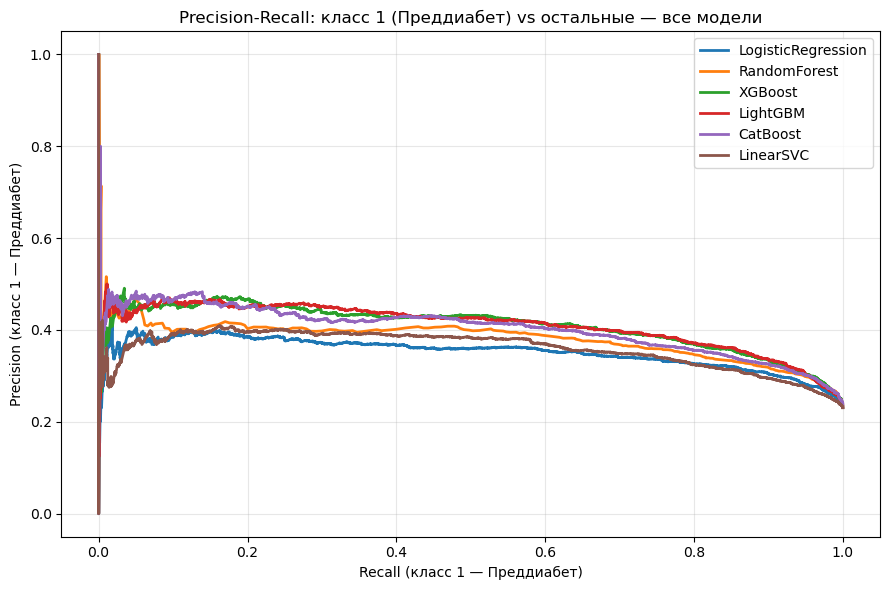

,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,XGBoost,0.655900,0.926900,0.605500,0.732500,0.387700,0.750800,0.511300,0.666700,0.776600,0.717500,0.711000,0.459800,0.855900,0.750200,0.956000
1,LightGBM,0.658100,0.922100,0.612300,0.736000,0.388700,0.741200,0.510000,0.667100,0.775100,0.717100,0.709500,0.458000,0.856600,0.751400,0.955600
2,CatBoost,0.627700,0.929900,0.563000,0.701400,0.364900,0.747000,0.490200,0.640700,0.788600,0.707000,0.699500,0.434400,0.857400,0.740500,0.957600
3,RandomForest,0.604800,0.934000,0.523400,0.670900,0.353300,0.768100,0.484000,0.625600,0.776600,0.693000,0.689400,0.418700,0.842500,0.725900,0.957300
4,LinearSVC,0.575300,0.940800,0.482300,0.637700,0.339300,0.749500,0.467100,0.539400,0.800600,0.644500,0.677500,0.393100,0.840400,0.701700,0.941800
5,LogisticRegression,0.574000,0.940700,0.478500,0.634400,0.333600,0.750200,0.461800,0.571900,0.811100,0.670800,0.679900,0.393100,0.847400,0.697100,0.950600


In [8]:
y_test_arr = np.asarray(y_test)
y_bin_class1 = (y_test_arr == 1).astype(int)

plt.figure(figsize=(9, 6))
for model_name, y_score in scores_cache.items():
    scores_c1 = y_score[:, 1]
    precision, recall, _ = precision_recall_curve(y_bin_class1, scores_c1)
    plt.plot(recall, precision, label=model_name, linewidth=2)

plt.xlabel("Recall (класс 1 — Преддиабет)")
plt.ylabel("Precision (класс 1 — Преддиабет)")
plt.title("Precision-Recall: класс 1 (Преддиабет) vs остальные — все модели")
plt.legend(loc="best")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

summary_df = pd.DataFrame(results_rows).sort_values("f1_1", ascending=False)
summary_df = summary_df.reset_index(drop=True)

METRICS_TABLE_COLS = [
    "model",
    "accuracy",
    "precision_0",
    "recall_0",
    "f1_0",
    "precision_1",
    "recall_1",
    "f1_1",
    "precision_2",
    "recall_2",
    "f1_2",
    "balanced_accuracy",
    "mcc",
    "roc_auc_ovr_0",
    "roc_auc_ovr_1",
    "roc_auc_ovr_2",
]
summary_table = summary_df[METRICS_TABLE_COLS].round(4)
try:
    from IPython.display import display

    display(
        summary_table.style.set_caption(
            "Метрики всех моделей (hold-out тест). Train: StandardScaler + SMOTEENN. "
            "Сортировка по F1 класса 1 (Преддиабет)."
        ).set_table_styles(
            [{"selector": "caption", "props": [("caption-side", "bottom"), ("font-size", "0.9em")]}]
        )
    )
except ImportError:
    print(summary_table.to_string())


### Сравнение методов балансировки классов

На **одних и тех же** `X_train_scaled` / `y_train` и тесте `X_test_scaled` / `y_test` обучаются **новые** экземпляры моделей (без загрузки из `models/`), с разными способами выравнивания классов:

- **Без балансировки** — исходное распределение после `StandardScaler`
- **Веса классов (balanced)** — без oversampling: `class_weight='balanced'` (LogReg, RF, LinearSVC, LightGBM), `sample_weight` из `compute_sample_weight` (XGBoost), `auto_class_weights='Balanced'` (CatBoost)
- **SMOTE**, **ADASYN**, **BorderlineSMOTE**
- **SMOTETomek**, **SMOTEENN** (комбинированные методы)

Метрики: **F1** для классов 1 и 2, **Balanced Accuracy**, **MCC**, **ROC-AUC OvR** для класса 1 (по вероятностям / softmax). При ошибке метода (например, ADASYN при малом числе соседей) метод пропускается с сообщением.

Ниже в выводе ячейки: **полная таблица** всех пар (балансировка × модель), затем **сводные матрицы** F1 для классов 1 и 2, **теплокарты** и строка с лучшей комбинацией. **Optuna + стэкинг** — в **последней код-ячейке** ноутбука.



--- Без балансировки ---  train: {0: 18177, 1: 6262, 2: 2666}


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Веса классов (balanced) ---  train (без ресемплинга): {0: 18177, 1: 6262, 2: 2666}  | sklearn: class_weight='balanced' / sample_weight / auto_class_weights


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- SMOTE ---  train: {0: 18177, 1: 18177, 2: 18177}


...

/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### Полная таблица: все методы балансировки × все модели

,balancing,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,Веса классов (balanced),CatBoost,0.707800,0.899100,0.717300,0.797900,0.434300,0.646000,0.519400,0.639100,0.788600,0.706000,0.717300,0.484400,0.869700,0.770300,0.960800
1,SMOTEENN,XGBoost,0.655900,0.926900,0.605500,0.732500,0.387700,0.750800,0.511300,0.666700,0.776600,0.717500,0.711000,0.459800,0.855900,0.750200,0.956000
2,SMOTEENN,LightGBM,0.658100,0.922100,0.612300,0.736000,0.388700,0.741200,0.510000,0.667100,0.775100,0.717100,0.709500,0.458000,0.856600,0.751400,0.955600
3,Веса классов (balanced),XGBoost,0.730600,0.874000,0.773600,0.820700,0.456900,0.602600,0.519700,0.713000,0.737600,0.725100,0.704600,0.489400,0.864400,0.776600,0.958900
4,Веса классов (balanced),LogisticRegression,0.686600,0.893000,0.692200,0.779900,0.409300,0.633200,0.497200,0.619400,0.773600,0.688000,0.699700,0.455000,0.849300,0.745100,0.952800
5,SMOTEENN,CatBoost,0.627700,0.929900,0.563000,0.701400,0.364900,0.747000,0.490200,0.640700,0.788600,0.707000,0.699500,0.434400,0.857400,0.740500,0.957600
6,SMOTETomek,LogisticRegression,0.684400,0.890100,0.691500,0.778400,0.406700,0.619800,0.491100,0.609800,0.787100,0.687200,0.699500,0.450400,0.848700,0.741800,0.950500
7,SMOTE,LogisticRegression,0.683900,0.890500,0.690900,0.778100,0.406300,0.620400,0.491000,0.608600,0.785600,0.685900,0.699000,0.450100,0.848700,0.741700,0.950500
8,Веса классов (balanced),LightGBM,0.729500,0.868300,0.778700,0.821000,0.454800,0.588500,0.513100,0.716000,0.725600,0.720800,0.697600,0.482700,0.861200,0.775200,0.958000
9,SMOTETomek,LinearSVC,0.691300,0.884300,0.714400,0.790300,0.419700,0.582700,0.488000,0.564400,0.788600,0.657900,0.695300,0.450300,0.846300,0.733400,0.946100


### Сводка F1 (класс 1 — Преддиабет): строки = балансировка, столбцы = модель

model,CatBoost,LightGBM,LinearSVC,LogisticRegression,RandomForest,XGBoost
balancing,,,,,,
Без балансировки,0.445000,0.461600,0.306800,0.402900,0.381100,0.447800
Веса классов (balanced),0.519400,0.513100,0.448100,0.497200,0.324700,0.519700
SMOTE,0.475800,0.461100,0.487700,0.491000,0.475200,0.450500
ADASYN,0.458700,0.441500,0.429300,0.446800,0.464900,0.454600
BorderlineSMOTE,0.465200,0.455800,0.449600,0.465300,0.462000,0.466000
SMOTETomek,0.476800,0.463100,0.488000,0.491100,0.473300,0.451200
SMOTEENN,0.490200,0.510000,0.467100,0.461800,0.484000,0.511300


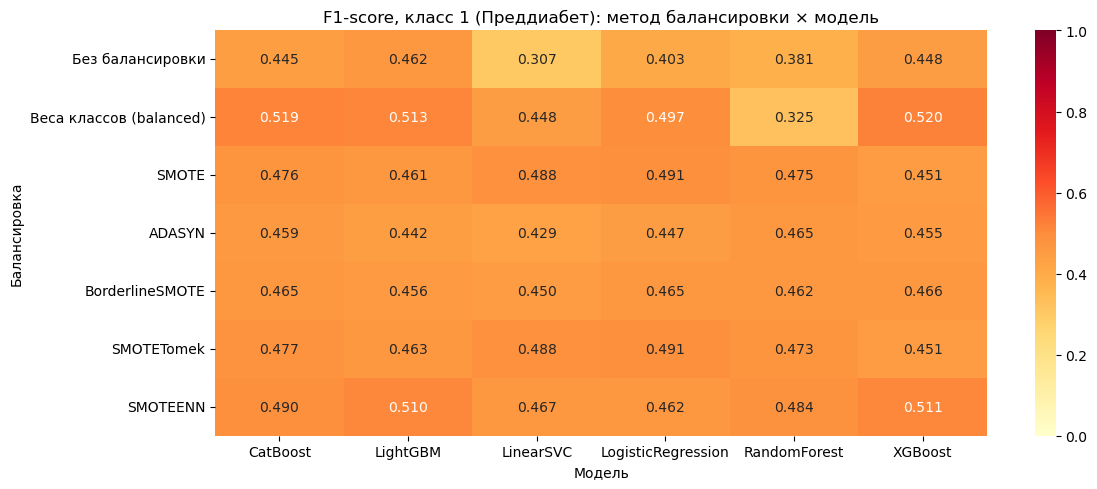

### Сводка F1 (класс 2 — Диабет): строки = балансировка, столбцы = модель

model,CatBoost,LightGBM,LinearSVC,LogisticRegression,RandomForest,XGBoost
balancing,,,,,,
Без балансировки,0.726300,0.727700,0.688000,0.710200,0.719200,0.733900
Веса классов (balanced),0.706000,0.720800,0.668000,0.688000,0.709200,0.725100
SMOTE,0.720700,0.738800,0.658700,0.685900,0.703900,0.725100
ADASYN,0.718700,0.726300,0.583000,0.618800,0.688200,0.726600
BorderlineSMOTE,0.717800,0.726900,0.620900,0.646600,0.687500,0.719800
SMOTETomek,0.720700,0.731800,0.657900,0.687200,0.706100,0.728100
SMOTEENN,0.707000,0.717100,0.644500,0.670800,0.693000,0.717500


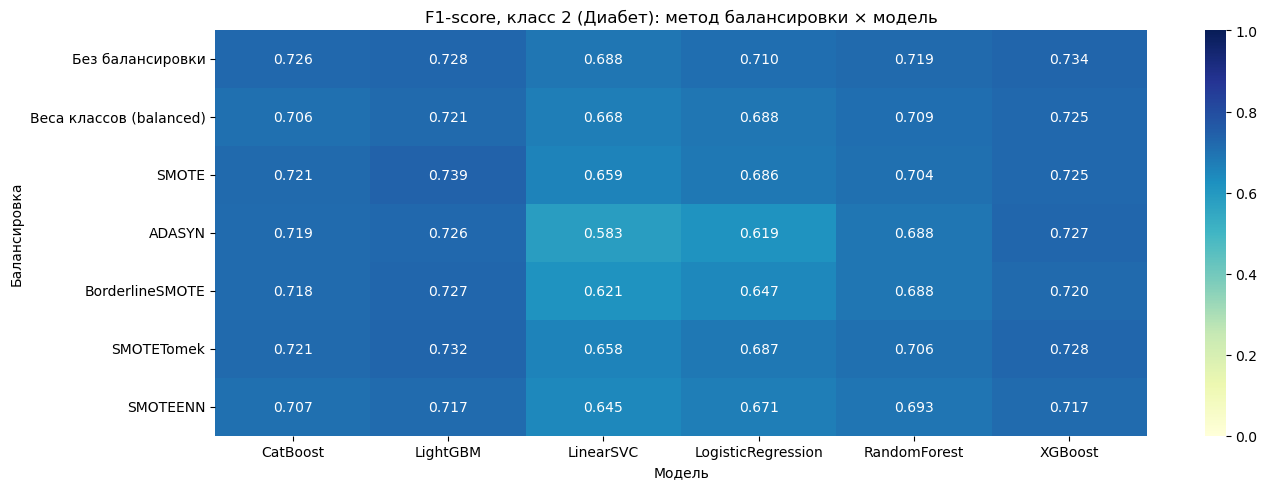

**Лучшая по Balanced Accuracy:** Веса классов (balanced) + CatBoost (BA = 0.7173, F1₁ = 0.5194)  
**Лучшая по F1 (класс 1):** Веса классов (balanced) + XGBoost (F1₁ = 0.5197, BA = 0.7046)

In [9]:
from sklearn.utils.class_weight import compute_sample_weight


def apply_balancing(method_key: str, X_tr: np.ndarray, y_tr: pd.Series):
    y_arr = np.asarray(y_tr)
    if method_key == "none":
        return np.asarray(X_tr, dtype=float), y_arr.copy()
    if method_key == "smote":
        return SMOTE(random_state=RANDOM_STATE, sampling_strategy="auto").fit_resample(X_tr, y_arr)
    if method_key == "adasyn":
        return ADASYN(random_state=RANDOM_STATE, sampling_strategy="auto").fit_resample(X_tr, y_arr)
    if method_key == "borderline_smote":
        return BorderlineSMOTE(random_state=RANDOM_STATE, sampling_strategy="auto").fit_resample(
            X_tr, y_arr
        )
    if method_key == "smote_tomek":
        return SMOTETomek(random_state=RANDOM_STATE).fit_resample(X_tr, y_arr)
    if method_key == "smote_enn":
        return SMOTEENN(random_state=RANDOM_STATE).fit_resample(X_tr, y_arr)
    if method_key == "class_weight_balanced":
        return np.asarray(X_tr, dtype=float), y_arr.copy()
    raise ValueError(f"Неизвестный метод: {method_key}")


def _softmax_rows_local(scores: np.ndarray) -> np.ndarray:
    s = np.asarray(scores, dtype=float)
    if s.ndim == 1:
        s = s.reshape(-1, 1)
    s = s - np.max(s, axis=1, keepdims=True)
    e = np.exp(s)
    return e / e.sum(axis=1, keepdims=True)


def scores_to_proba_local(model, X) -> np.ndarray:
    if hasattr(model, "predict_proba"):
        return np.asarray(model.predict_proba(X), dtype=float)
    s = model.decision_function(X)
    if s.ndim == 1:
        s = np.column_stack([-s, s])
    return _softmax_rows_local(s)


def make_fresh_model(model_name: str, bal_key: str):
    use_cw = bal_key == "class_weight_balanced"
    if model_name == "LogisticRegression":
        return LogisticRegression(
            max_iter=2000,
            random_state=RANDOM_STATE,
            multi_class="multinomial",
            solver="lbfgs",
            class_weight="balanced" if use_cw else None,
        )
    if model_name == "RandomForest":
        return RandomForestClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            class_weight="balanced" if use_cw else None,
        )
    if model_name == "XGBoost":
        return XGBClassifier(
            n_estimators=300,
            max_depth=6,
            learning_rate=0.1,
            objective="multi:softprob",
            num_class=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            eval_metric="mlogloss",
        )
    if model_name == "LightGBM":
        return LGBMClassifier(
            n_estimators=300,
            max_depth=-1,
            learning_rate=0.1,
            objective="multiclass",
            num_class=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1,
            class_weight="balanced" if use_cw else None,
        )
    if model_name == "CatBoost":
        return CatBoostClassifier(
            iterations=400,
            depth=6,
            learning_rate=0.1,
            loss_function="MultiClass",
            random_seed=RANDOM_STATE,
            verbose=False,
            auto_class_weights="Balanced" if use_cw else None,
        )
    if model_name == "LinearSVC":
        return LinearSVC(
            dual=False,
            random_state=RANDOM_STATE,
            max_iter=5000,
            class_weight="balanced" if use_cw else None,
        )
    raise ValueError(model_name)


def append_metrics_row(balance_rows: list[dict], bal_label: str, model_name: str, y_pred, y_proba):
    y_true = np.asarray(y_test).ravel()
    y_p = np.asarray(y_pred).ravel()
    labels_3 = [0, 1, 2]
    prec_per = precision_score(y_true, y_p, labels=labels_3, average=None, zero_division=0)
    rec_per = recall_score(y_true, y_p, labels=labels_3, average=None, zero_division=0)
    f1_per = f1_score(y_true, y_p, labels=labels_3, average=None, zero_division=0)
    auc_map = roc_auc_score(
        y_true,
        y_proba,
        multi_class="ovr",
        average=None,
        labels=labels_3,
    )
    balance_rows.append(
        {
            "balancing": bal_label,
            "model": model_name,
            "accuracy": float(accuracy_score(y_true, y_p)),
            "precision_0": float(prec_per[0]),
            "recall_0": float(rec_per[0]),
            "f1_0": float(f1_per[0]),
            "precision_1": float(prec_per[1]),
            "recall_1": float(rec_per[1]),
            "f1_1": float(f1_per[1]),
            "precision_2": float(prec_per[2]),
            "recall_2": float(rec_per[2]),
            "f1_2": float(f1_per[2]),
            "balanced_accuracy": float(balanced_accuracy_score(y_true, y_p)),
            "mcc": float(matthews_corrcoef(y_true, y_p)),
            "roc_auc_ovr_0": float(auc_map[0]),
            "roc_auc_ovr_1": float(auc_map[1]),
            "roc_auc_ovr_2": float(auc_map[2]),
        }
    )



BALANCING_METHODS: list[tuple[str, str]] = [
    ("Без балансировки", "none"),
    ("Веса классов (balanced)", "class_weight_balanced"),
    ("SMOTE", "smote"),
    ("ADASYN", "adasyn"),
    ("BorderlineSMOTE", "borderline_smote"),
    ("SMOTETomek", "smote_tomek"),
    ("SMOTEENN", "smote_enn"),
]

MODEL_ORDER = [
    "LogisticRegression",
    "RandomForest",
    "XGBoost",
    "LightGBM",
    "CatBoost",
    "LinearSVC",
]

balance_rows: list[dict] = []

for bal_label, bal_key in BALANCING_METHODS:
    try:
        X_res, y_res = apply_balancing(bal_key, X_train_scaled, y_train)
    except Exception as exc:
        print(f"Пропуск «{bal_label}»: {exc}")
        continue

    train_info = pd.Series(y_res).value_counts().sort_index().to_dict()
    if bal_key == "class_weight_balanced":
        print(
            f"\n--- {bal_label} ---  train (без ресемплинга): {train_info}  "
            "| sklearn: class_weight='balanced' / sample_weight / auto_class_weights"
        )
    else:
        print(f"\n--- {bal_label} ---  train: {train_info}")

    for mname in MODEL_ORDER:
        clf = make_fresh_model(mname, bal_key)
        if bal_key == "class_weight_balanced" and mname == "XGBoost":
            sw = compute_sample_weight("balanced", y_res)
            clf.fit(X_res, y_res, sample_weight=sw)
        else:
            clf.fit(X_res, y_res)

        y_pred = clf.predict(X_test_scaled)
        y_proba = scores_to_proba_local(clf, X_test_scaled)
        append_metrics_row(balance_rows, bal_label, mname, y_pred, y_proba)

balance_compare_df = pd.DataFrame(balance_rows)
balance_compare_df = balance_compare_df.sort_values(
    ["balanced_accuracy", "f1_1"],
    ascending=[False, False],
).reset_index(drop=True)

BALANCE_COMPARE_COLS = [
    "balancing",
    "model",
    "accuracy",
    "precision_0",
    "recall_0",
    "f1_0",
    "precision_1",
    "recall_1",
    "f1_1",
    "precision_2",
    "recall_2",
    "f1_2",
    "balanced_accuracy",
    "mcc",
    "roc_auc_ovr_0",
    "roc_auc_ovr_1",
    "roc_auc_ovr_2",
]
balance_compare_view = balance_compare_df[BALANCE_COMPARE_COLS]

try:
    from IPython.display import Markdown, display

    display(Markdown("### Полная таблица: все методы балансировки × все модели"))
    display(
        balance_compare_view.round(4).style.set_caption(
            "Полные метрики: accuracy; precision/recall/F1 по классам 0–2; ROC-AUC OVR по классам; "
            "balanced_accuracy, mcc. Сортировка: BA (↓), затем F1 класса 1."
        ).set_table_styles(
            [{"selector": "caption", "props": [("caption-side", "bottom"), ("font-size", "0.9em")]}]
        )
    )
except ImportError:
    print("\n=== Полная таблица: все методы балансировки × все модели ===\n")
    print(balance_compare_view.to_string(index=False))

pivot_f1_c1 = balance_compare_df.pivot_table(
    index="balancing",
    columns="model",
    values="f1_1",
    aggfunc="first",
)
pivot_f1_c1 = pivot_f1_c1.reindex([b[0] for b in BALANCING_METHODS if b[0] in pivot_f1_c1.index])

try:
    from IPython.display import Markdown, display

    display(
        Markdown(
            "### Сводка F1 (класс 1 — Преддиабет): строки = балансировка, столбцы = модель"
        )
    )
    display(pivot_f1_c1.round(4).style.set_caption("Те же данные, что на теплокарте ниже."))
except ImportError:
    print("\n=== F1 класс 1 (сводная матрица) ===\n")
    print(pivot_f1_c1.round(4).to_string())

plt.figure(figsize=(12, 5))
sns.heatmap(pivot_f1_c1, annot=True, fmt=".3f", cmap="YlOrRd", vmin=0, vmax=1)
plt.title("F1-score, класс 1 (Преддиабет): метод балансировки × модель")
plt.xlabel("Модель")
plt.ylabel("Балансировка")
plt.tight_layout()
plt.show()

pivot_f1_c2 = balance_compare_df.pivot_table(
    index="balancing",
    columns="model",
    values="f1_2",
    aggfunc="first",
)
pivot_f1_c2 = pivot_f1_c2.reindex([b[0] for b in BALANCING_METHODS if b[0] in pivot_f1_c2.index])

try:
    from IPython.display import Markdown, display

    display(
        Markdown(
            "### Сводка F1 (класс 2 — Диабет): строки = балансировка, столбцы = модель"
        )
    )
    display(pivot_f1_c2.round(4).style.set_caption("Те же данные, что на теплокарте ниже."))
except ImportError:
    print("\n=== F1 класс 2 (сводная матрица) ===\n")
    print(pivot_f1_c2.round(4).to_string())

plt.figure(figsize=(14, 5))
sns.heatmap(pivot_f1_c2, annot=True, fmt=".3f", cmap="YlGnBu", vmin=0, vmax=1)
plt.title("F1-score, класс 2 (Диабет): метод балансировки × модель")
plt.xlabel("Модель")
plt.ylabel("Балансировка")
plt.tight_layout()
plt.show()

best_bal_row = balance_compare_df.loc[balance_compare_df["balanced_accuracy"].idxmax()]
best_f1_row = balance_compare_df.loc[balance_compare_df["f1_1"].idxmax()]
try:
    from IPython.display import Markdown, display

    display(
        Markdown(
            f"**Лучшая по Balanced Accuracy:** {best_bal_row['balancing']} + "
            f"{best_bal_row['model']} (BA = {best_bal_row['balanced_accuracy']:.4f}, "
            f"F1₁ = {best_bal_row['f1_1']:.4f})  \n"
            f"**Лучшая по F1 (класс 1):** {best_f1_row['balancing']} + {best_f1_row['model']} "
            f"(F1₁ = {best_f1_row['f1_1']:.4f}, BA = {best_f1_row['balanced_accuracy']:.4f})"
        )
    )
except ImportError:
    print(
        f"\nЛучшая по Balanced Accuracy: {best_bal_row['balancing']} + {best_bal_row['model']} "
        f"(BA={best_bal_row['balanced_accuracy']:.4f})"
    )
    print(
        f"Лучшая по F1 (класс 1): {best_f1_row['balancing']} + {best_f1_row['model']} "
        f"(F1₁={best_f1_row['f1_1']:.4f})"
    )


### Важность признаков: три лучшие модели на тесте

Для **трёх лучших моделей** по **F1 класса 1** (как в `summary_df` после ячейки с метриками на тесте) по отдельности выводятся:

- **топ-20** наиболее важных признаков (`feature_importances_` или среднее |`coef_`| по классам);
- **топ-20** наименее важных признаков.

У каждой модели — отдельный блок (заголовок + две таблицы) для читаемости.

In [10]:
FEATURE_DESCRIPTIONS: dict[str, str] = {
    "RIDAGEYR": "Возраст участника (годы, NHANES).",
    "RIAGENDR": "Пол (код NHANES).",
    "BMXBMI": "Индекс массы тела (кг/м²).",
    "BPXSY1": "Систолическое артериальное давление (среднее измерений, мм рт. ст.).",
    "BPXDI1": "Диастолическое артериальное давление (среднее измерений, мм рт. ст.).",
    "LBXTC": "Общий холестерин в сыворотке (мг/дл).",
    "LBDHDD": "HDL-холестерин (мг/дл).",
    "LBXGLU": "Глюкоза натощак в сыворотке (мг/дл).",
    "LBXIN": "log(1 + инсулин сыворотки) в CSV; HOMA-IR в ноутбуке: expm1(LBXIN) × LBXGLU / 405.",
    "smoking": "Признак курения (агрегированная переменная в датасете).",
    "hypertension": "Признак гипертензии (агрегированная переменная в датасете).",
    "RIDRETH1": "Раса / этническая принадлежность (код NHANES).",
    "DMDEDUC2": "Уровень образования (код NHANES).",
    "Age_x_WC": "Произведение возраста и окружности талии (интеракция).",
    "Age_x_Glucose": "Произведение возраста и глюкозы натощак.",
    "HOMA_IR": "Индекс HOMA-IR (оценка инсулинорезистентности по глюкозе и инсулину).",
    "Risk_Factor_Count": "Число факторов риска: ожирение (ИМТ ≥ 30), гипертензия, курение.",
    "TyG_Index": "Триглицеридно-глюкозный индекс: ln((TG × глюкоза) / 2); TG = LBXTR при наличии, иначе LBXTC.",
    "TyG_WC": "Произведение TyG_Index и окружности талии.",
    "METS_IR": "Индекс METS-IR на основе глюкозы, TG, HDL и окружности талии.",
    "CRP_WC": "Произведение CRP и окружности талии.",
    "Age_Squared": "Квадрат возраста (нелинейная зависимость от возраста).",
    "GHR": "Отношение глюкозы к HDL (LBXGLU / LBDHDD; знаменатель защищён от нуля).",
    "Log_Glucose": "log(1 + глюкоза) для сглаживания шкалы.",
    "Pulse_Pressure": "Пульсовое давление (систолическое − диастолическое).",
    "is_Normal_BMI": "Индикатор ИМТ в диапазоне нормального веса (18.5–25).",
    "is_Overweight_BMI": "Индикатор избыточного веса (ИМТ 25–30).",
    "is_Obese_BMI": "Индикатор ожирения (ИМТ ≥ 30).",
    "htn_normal": "Индикатор нормального АД по выбранным порогам категорий.",
    "htn_elevated": "Индикатор повышенного АД по выбранным порогам.",
    "htn_stage1": "Индикатор АГ стадии 1 (категориальный one-hot).",
    "htn_stage2": "Индикатор АГ стадии 2 (категориальный one-hot).",
    "Metab_Synd_Count": "Число выполненных условий прокси метаболического синдрома.",
    "Metab_Synd_3plus": "Индикатор: три и более условий прокси метаболического синдрома.",
}


def _feature_description(feature: str) -> str:
    return FEATURE_DESCRIPTIONS.get(feature, "—")


def _feature_importance_vector(
    model, feature_names: list[str]
) -> tuple[np.ndarray, str] | None:
    if hasattr(model, "feature_importances_"):
        importance = np.asarray(model.feature_importances_, dtype=float)
        importance_source = "feature_importances_"
    elif hasattr(model, "coef_"):
        coef = np.asarray(model.coef_, dtype=float)
        importance = np.mean(np.abs(coef), axis=0) if coef.ndim > 1 else np.abs(coef)
        importance_source = "abs(coef_)"
    else:
        return None
    if importance.shape[0] != len(feature_names):
        return None
    return importance, importance_source


def _importance_subset_df(
    feature_names: list[str],
    importance: np.ndarray,
    importance_source: str,
    ascending: bool,
    k: int,
) -> pd.DataFrame:
    df = pd.DataFrame({"feature": feature_names, "importance": importance})
    part = df.sort_values("importance", ascending=ascending).head(k).reset_index(drop=True)
    part.insert(0, "rank", np.arange(1, len(part) + 1))
    part.insert(0, "source", importance_source)
    part["description"] = part["feature"].map(_feature_description)
    return part[["rank", "source", "feature", "description", "importance"]]


TOP_K_IMPORTANCE = 20
BOTTOM_K_IMPORTANCE = 20


def _top3_model_names_from_summary() -> list[str]:
    try:
        # Как сводная таблица метрик на тесте: сортировка по f1_1 (класс «Преддиабет»)
        return summary_df.head(3)["model"].tolist()
    except NameError:
        order = [
            "LogisticRegression",
            "RandomForest",
            "XGBoost",
            "LightGBM",
            "CatBoost",
            "LinearSVC",
        ]
        return [m for m in order if m in models][:3]


top3_model_names = _top3_model_names_from_summary()

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = None
    display = print

msg_intro = (
    "Три «лучшие» модели по **F1 класса 1 (Преддиабет)** на hold-out тесте — "
    "как в `summary_df` (запустите ячейку с метриками на тесте раньше)."
)
if Markdown is not None:
    display(Markdown(msg_intro))
    display(
        Markdown(
            "**Выбранные модели:** "
            + ", ".join(f"`{n}`" for n in top3_model_names)
        )
    )
else:
    print(msg_intro)
    print("Модели:", top3_model_names)

for mname in top3_model_names:
    if mname not in models:
        print(f"Пропуск «{mname}»: нет в `models`.")
        continue
    vec = _feature_importance_vector(models[mname], feature_cols)
    if vec is None:
        print(
            f"«{mname}»: не удалось извлечь важность "
            "(нужны feature_importances_ или coef_, длина как у feature_cols)."
        )
        continue
    importance, importance_source = vec
    top_df = _importance_subset_df(
        feature_cols, importance, importance_source, ascending=False, k=TOP_K_IMPORTANCE
    )
    bottom_df = _importance_subset_df(
        feature_cols, importance, importance_source, ascending=True, k=BOTTOM_K_IMPORTANCE
    )

    cap_top = f"{mname}: топ-{TOP_K_IMPORTANCE} по важности (убывание)"
    cap_bot = f"{mname}: {BOTTOM_K_IMPORTANCE} наименее важных признаков"

    if Markdown is not None:
        display(Markdown(f"---\n## {mname}"))
        display(
            Markdown(
                f"**Источник:** `{importance_source}` · **размер признаков:** {len(feature_cols)}"
            )
        )
        display(Markdown(f"### Топ-{TOP_K_IMPORTANCE} важных признаков"))
        display(
            top_df.style.format({"importance": "{:.6f}"}).set_caption(cap_top)
        )
        display(Markdown(f"### Топ-{BOTTOM_K_IMPORTANCE} наименее важных признаков"))
        display(
            bottom_df.style.format({"importance": "{:.6f}"}).set_caption(cap_bot)
        )
    else:
        print("\n" + "=" * 72)
        print(mname, importance_source)
        print(cap_top)
        print(top_df.to_string(index=False))
        print(cap_bot)
        print(bottom_df.to_string(index=False))



Три «лучшие» модели по **F1 класса 1 (Преддиабет)** на hold-out тесте — как в `summary_df` (запустите ячейку с метриками на тесте раньше).

**Выбранные модели:** `XGBoost`, `LightGBM`, `CatBoost`

---
## XGBoost

**Источник:** `feature_importances_` · **размер признаков:** 44

### Топ-20 важных признаков

...

**Источник:** `feature_importances_` · **размер признаков:** 44

### Топ-20 важных признаков

,rank,source,feature,description,importance
0,1,feature_importances_,LBXGLU,Глюкоза натощак в сыворотке (мг/дл).,18.038096
1,2,feature_importances_,Age_x_Glucose,Произведение возраста и глюкозы натощак.,6.132762
2,3,feature_importances_,Age_x_WC,Произведение возраста и окружности талии (интеракция).,4.392814
3,4,feature_importances_,HSD010,—,4.124012
4,5,feature_importances_,LBXRDW,—,3.486675
5,6,feature_importances_,MCQ300C,—,3.372307
6,7,feature_importances_,LBXMCVSI,—,3.012602
7,8,feature_importances_,DMDEDUC2,Уровень образования (код NHANES).,2.664187
8,9,feature_importances_,URXUMA,—,2.586724
9,10,feature_importances_,PhenoAge_accel,—,2.549679


### Топ-20 наименее важных признаков

,rank,source,feature,description,importance
0,1,feature_importances_,MCQ160F,—,0.184117
1,2,feature_importances_,MCQ160E,—,0.472382
2,3,feature_importances_,LBXTR,—,0.666962
3,4,feature_importances_,Log_CRP,—,0.841778
4,5,feature_importances_,BMXWAIST,—,0.846735
5,6,feature_importances_,BMXBMI,Индекс массы тела (кг/м²).,0.936358
6,7,feature_importances_,TyG_WC,Произведение TyG_Index и окружности талии.,0.991874
7,8,feature_importances_,BMXHT,—,1.010675
8,9,feature_importances_,WHtR,—,1.040548
9,10,feature_importances_,Log_SUA,—,1.055312


In [11]:
# ### CatBoost Balanced + margin rule (5% и 10%)
# Базовая модель — та же, что строка **«Веса классов (balanced)» × CatBoost** в таблице сравнения балансировок:
# `make_fresh_model("CatBoost", "class_weight_balanced")`, fit на `X_train_scaled` / `y_train` (без SMOTEENN).
# Требуется ячейка с `apply_balancing` / `make_fresh_model` (сравнение методов балансировки).
# Если argmax = 0 (здоров), но `P(0) - P(1) <= margin_delta` (5% или 10%), класс меняется на 1 (преддиабет).

CATBOOST_MARGIN_DELTA_05 = 0.05
CATBOOST_MARGIN_DELTA_10 = 0.10


def apply_prediabetes_margin_rule(
    base_pred: np.ndarray,
    proba: np.ndarray,
    margin_delta: float,
) -> np.ndarray:
    p = np.asarray(proba, dtype=float)
    y = np.asarray(base_pred, dtype=int).ravel()
    out = y.copy()
    margin = p[:, 0] - p[:, 1]
    mask = (y == 0) & (margin <= margin_delta)
    out[mask] = 1
    return out


class CatBoostBalancedMarginClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, estimator: CatBoostClassifier, margin_delta: float = 0.05):
        self.estimator = estimator
        self.margin_delta = margin_delta

    def fit(self, X, y):
        self.classes_ = np.array([0, 1, 2], dtype=int)
        self.n_features_in_ = int(np.asarray(X).shape[1])
        return self

    def predict_proba(self, X):
        return np.asarray(self.estimator.predict_proba(X), dtype=float)

    def predict(self, X):
        proba = self.predict_proba(X)
        base = np.argmax(proba, axis=1).astype(int)
        return apply_prediabetes_margin_rule(base, proba, self.margin_delta)


X_cb_cw, y_cb_cw = apply_balancing("class_weight_balanced", X_train_scaled, y_train)
catboost_balanced_base = make_fresh_model("CatBoost", "class_weight_balanced")
catboost_balanced_base.fit(X_cb_cw, y_cb_cw)

proba_cb_bal = np.asarray(catboost_balanced_base.predict_proba(X_test_scaled), dtype=float)
y_pred_cb_bal_base = np.argmax(proba_cb_bal, axis=1).astype(int)
y_pred_cb_bal_margin05 = apply_prediabetes_margin_rule(
    y_pred_cb_bal_base, proba_cb_bal, CATBOOST_MARGIN_DELTA_05
)
y_pred_cb_bal_margin10 = apply_prediabetes_margin_rule(
    y_pred_cb_bal_base, proba_cb_bal, CATBOOST_MARGIN_DELTA_10
)

catboost_balanced_margin05 = CatBoostBalancedMarginClassifier(
    catboost_balanced_base, CATBOOST_MARGIN_DELTA_05
)
catboost_balanced_margin05.fit(X_cb_cw, y_cb_cw)

catboost_balanced_margin10 = CatBoostBalancedMarginClassifier(
    catboost_balanced_base, CATBOOST_MARGIN_DELTA_10
)
catboost_balanced_margin10.fit(X_cb_cw, y_cb_cw)

models["CatBoost_Balanced_Base"] = catboost_balanced_base
models["CatBoost_Balanced_Margin05"] = catboost_balanced_margin05
models["CatBoost_Balanced_Margin10"] = catboost_balanced_margin10

print("=== CatBoost_Balanced_Base ===")
print(classification_report(y_test, y_pred_cb_bal_base, digits=4, zero_division=0))
print("=== CatBoost_Balanced_Margin05 ===")
print(classification_report(y_test, y_pred_cb_bal_margin05, digits=4, zero_division=0))
print("=== CatBoost_Balanced_Margin10 ===")
print(classification_report(y_test, y_pred_cb_bal_margin10, digits=4, zero_division=0))

compare_cb_bal_df = pd.DataFrame(
    [
        {
            "model": "CatBoost_Balanced_Base",
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_cb_bal_base),
            "recall_1": recall_score(
                y_test, y_pred_cb_bal_base, labels=[1], average=None, zero_division=0
            )[0],
            "f1_1": f1_score(
                y_test, y_pred_cb_bal_base, labels=[1], average=None, zero_division=0
            )[0],
            "accuracy": accuracy_score(y_test, y_pred_cb_bal_base),
        },
        {
            "model": "CatBoost_Balanced_Margin05",
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_cb_bal_margin05),
            "recall_1": recall_score(
                y_test, y_pred_cb_bal_margin05, labels=[1], average=None, zero_division=0
            )[0],
            "f1_1": f1_score(
                y_test, y_pred_cb_bal_margin05, labels=[1], average=None, zero_division=0
            )[0],
            "accuracy": accuracy_score(y_test, y_pred_cb_bal_margin05),
        },
        {
            "model": "CatBoost_Balanced_Margin10",
            "balanced_accuracy": balanced_accuracy_score(y_test, y_pred_cb_bal_margin10),
            "recall_1": recall_score(
                y_test, y_pred_cb_bal_margin10, labels=[1], average=None, zero_division=0
            )[0],
            "f1_1": f1_score(
                y_test, y_pred_cb_bal_margin10, labels=[1], average=None, zero_division=0
            )[0],
            "accuracy": accuracy_score(y_test, y_pred_cb_bal_margin10),
        },
    ]
)
print(
    "\n=== Сравнение: Base vs Margin05 vs Margin10 (CatBoost balanced) ==="
)
print(compare_cb_bal_df.round(4).to_string(index=False))


def _roc_auc_ovr_per_class_cb(y_true, y_score) -> dict[int, float]:
    aucs = roc_auc_score(
        y_true,
        y_score,
        multi_class="ovr",
        average=None,
        labels=[0, 1, 2],
    )
    return {int(l): float(a) for l, a in zip([0, 1, 2], aucs)}


def _full_metrics_row_cb(model_name: str, y_true, y_pred, y_score) -> dict:
    rep_dict = classification_report(
        y_true,
        y_pred,
        labels=[0, 1, 2],
        target_names=["Здоров (0)", "Преддиабет (1)", "Диабет (2)"],
        output_dict=True,
        zero_division=0,
    )
    p0 = rep_dict["Здоров (0)"]["precision"]
    r0 = rep_dict["Здоров (0)"]["recall"]
    f1_0 = rep_dict["Здоров (0)"]["f1-score"]
    p1 = rep_dict["Преддиабет (1)"]["precision"]
    r1 = rep_dict["Преддиабет (1)"]["recall"]
    f1_1 = rep_dict["Преддиабет (1)"]["f1-score"]
    p2 = rep_dict["Диабет (2)"]["precision"]
    r2 = rep_dict["Диабет (2)"]["recall"]
    f2 = rep_dict["Диабет (2)"]["f1-score"]
    acc = accuracy_score(y_true, y_pred)
    bacc = balanced_accuracy_score(y_true, y_pred)
    mcc = matthews_corrcoef(y_true, y_pred)
    auc_map = _roc_auc_ovr_per_class_cb(y_true, y_score)
    return {
        "model": model_name,
        "accuracy": acc,
        "precision_0": p0,
        "recall_0": r0,
        "f1_0": f1_0,
        "precision_1": p1,
        "recall_1": r1,
        "f1_1": f1_1,
        "precision_2": p2,
        "recall_2": r2,
        "f1_2": f2,
        "balanced_accuracy": bacc,
        "mcc": mcc,
        "roc_auc_ovr_0": auc_map[0],
        "roc_auc_ovr_1": auc_map[1],
        "roc_auc_ovr_2": auc_map[2],
    }


_cb_full_cols = [
    "model",
    "accuracy",
    "precision_0",
    "recall_0",
    "f1_0",
    "precision_1",
    "recall_1",
    "f1_1",
    "precision_2",
    "recall_2",
    "f1_2",
    "balanced_accuracy",
    "mcc",
    "roc_auc_ovr_0",
    "roc_auc_ovr_1",
    "roc_auc_ovr_2",
]

full_cb_bal_df = pd.DataFrame(
    [
        _full_metrics_row_cb(
            "CatBoost_Balanced_Base",
            y_test,
            y_pred_cb_bal_base,
            proba_cb_bal,
        ),
        _full_metrics_row_cb(
            "CatBoost_Balanced_Margin05",
            y_test,
            y_pred_cb_bal_margin05,
            proba_cb_bal,
        ),
        _full_metrics_row_cb(
            "CatBoost_Balanced_Margin10",
            y_test,
            y_pred_cb_bal_margin10,
            proba_cb_bal,
        ),
    ]
)

print("\n=== Полная таблица метрик (как в общей сводке по моделям) ===")
_cb_metrics_table = full_cb_bal_df[_cb_full_cols].round(4)
try:
    from IPython.display import display

    display(
        _cb_metrics_table.style.set_caption(
            "CatBoost (balanced weights, как в сводке балансировок): полные метрики. "
            "ROC-AUC по вероятностям базовой модели; margin-правило меняет только жёсткие метки."
        )
    )
except ImportError:
    pass
# Всегда дублируем в текст: HTML-вывод ячейки иногда показывает устаревший результат, пока ячейку не перезапустят.
print(_cb_metrics_table.to_string(index=False))

r1_base = compare_cb_bal_df.loc[
    compare_cb_bal_df["model"] == "CatBoost_Balanced_Base", "recall_1"
].iloc[0]
r1_m05 = compare_cb_bal_df.loc[
    compare_cb_bal_df["model"] == "CatBoost_Balanced_Margin05", "recall_1"
].iloc[0]
r1_m10 = compare_cb_bal_df.loc[
    compare_cb_bal_df["model"] == "CatBoost_Balanced_Margin10", "recall_1"
].iloc[0]
print(
    f"\nRecall класса 1 (преддиабет): base={r1_base:.4f}, margin 5%={r1_m05:.4f}, margin 10%={r1_m10:.4f}."
)


=== CatBoost_Balanced_Base ===
              precision    recall  f1-score   support

           0     0.8991    0.7173    0.7979      4545
           1     0.4343    0.6460    0.5194      1565
           2     0.6391    0.7886    0.7060       667

    accuracy                         0.7078      6777
   macro avg     0.6575    0.7173    0.6745      6777
weighted avg     0.7661    0.7078    0.7246      6777

=== CatBoost_Balanced_Margin05 ===
              precision    recall  f1-score   support

           0     0.9053    0.6942    0.7858      4545
           1     0.4232    0.6677    0.5181      1565
           2     0.6391    0.7886    0.7060       667

    accuracy                         0.6974      6777
   macro avg     0.6559    0.7168    0.6700      6777
weighted avg     0.7678    0.6974    0.7161      6777

=== CatBoost_Balanced_Margin10 ===
              precision    recall  f1-score   support

           0     0.9117    0.6726    0.7741      4545
           1     0.4148    0

,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,CatBoost_Balanced_Base,0.707800,0.899100,0.717300,0.797900,0.434300,0.646000,0.519400,0.639100,0.788600,0.706000,0.717300,0.484400,0.869700,0.770300,0.960800
1,CatBoost_Balanced_Margin05,0.697400,0.905300,0.694200,0.785800,0.423200,0.667700,0.518100,0.639100,0.788600,0.706000,0.716800,0.479000,0.869700,0.770300,0.960800
2,CatBoost_Balanced_Margin10,0.687900,0.911700,0.672600,0.774100,0.414800,0.689500,0.518000,0.639100,0.788600,0.706000,0.716900,0.475300,0.869700,0.770300,0.960800


                     model  accuracy  precision_0  recall_0   f1_0  precision_1  recall_1   f1_1  precision_2  recall_2  f1_2  balanced_accuracy    mcc  roc_auc_ovr_0  roc_auc_ovr_1  roc_auc_ovr_2
    CatBoost_Balanced_Base    0.7078       0.8991    0.7173 0.7979       0.4343    0.6460 0.5194       0.6391    0.7886 0.706             0.7173 0.4844         0.8697         0.7703         0.9608
CatBoost_Balanced_Margin05    0.6974       0.9053    0.6942 0.7858       0.4232    0.6677 0.5181       0.6391    0.7886 0.706             0.7168 0.4790         0.8697         0.7703         0.9608
CatBoost_Balanced_Margin10    0.6879       0.9117    0.6726 0.7741       0.4148    0.6895 0.5180       0.6391    0.7886 0.706             0.7169 0.4753         0.8697         0.7703         0.9608

Recall класса 1 (преддиабет): base=0.6460, margin 5%=0.6677, margin 10%=0.6895.


### CatBoost (balanced): правило перераспределения по вероятностям

**Цель:** снизить риск пропуска патологии, если суммарная доля «преддиабет + диабет» выше, чем «здоров».

На тесте используются вероятности `predict_proba(X_test_scaled)` финальной модели **CatBoost** с весами классов (`catboost_balanced_base` из ячейки выше).

**Правило `custom_preds` для каждой строки:**

- если **`P(класс 0) < 0.5`** (эквивалентно \(P(1)+P(2) > P(0)\)):
  - если **`P(1) ≥ P(2)`** → метка **1** (преддиабет);
  - иначе → метка **2** (диабет);
- иначе, если **`P(0) \ge 0.5`**, но **`P(1)+P(2) > P(0) - 0.05`** (сумма патологий отстаёт от «здоровья» не более чем на **5 п.п.**) → метка **1** (преддиабет);
- иначе → метка **0** (здоров).

Ниже — classification report и confusion matrix для базы и `custom_preds`, затем **полная таблица метрик** (как в ячейке CatBoost balanced: accuracy, precision/recall/F1 по классам, balanced accuracy, MCC, ROC-AUC OVR по классам) для Base, Margin 5%/10% и **PathologyDominance**. Сначала выполните ячейку с CatBoost balanced — нужны `_full_metrics_row_cb`, margin-предсказания. В конце — прирост **Recall** класса 1 относительно Base.


In [12]:
PATHOLOGY_PATH_VS_HEALTHY_MARGIN_PP = 0.05  # п.п.: «патология» близка к P(0) → страхуем в преддиабет


def apply_pathology_dominance_rule(proba: np.ndarray) -> np.ndarray:
    """P(0)<0.5 → max(P(1),P(2)) как 1 или 2.
    Иначе, если P(0)≥0.5 и P(1)+P(2) > P(0)−margin (патология не хуже чем на 5 п.п. от «здоровья») → 1.
    Иначе → 0."""
    p = np.asarray(proba, dtype=float)
    p0 = p[:, 0]
    p1 = p[:, 1]
    p2 = p[:, 2]
    path_sum = p1 + p2
    low_p0 = p0 < 0.5
    out = np.zeros(p.shape[0], dtype=int)
    out[low_p0] = np.where(p1[low_p0] >= p2[low_p0], 1, 2)
    near_path = (~low_p0) & (path_sum > p0 - PATHOLOGY_PATH_VS_HEALTHY_MARGIN_PP)
    out[near_path] = 1
    return out


# Нужны catboost_balanced_base, proba_cb_bal, y_pred_cb_bal_base из ячейки CatBoost (balanced)
proba_cb_bal = np.asarray(catboost_balanced_base.predict_proba(X_test_scaled), dtype=float)
y_pred_cb_bal_base = np.argmax(proba_cb_bal, axis=1).astype(int)
custom_preds = apply_pathology_dominance_rule(proba_cb_bal)

print("CatBoost (balanced): базовые предсказания = argmax(proba)")
print(
    classification_report(
        y_test,
        y_pred_cb_bal_base,
        labels=LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)
print("Balanced accuracy (база):", balanced_accuracy_score(y_test, y_pred_cb_bal_base))
print("Confusion matrix (база), строки = истина, столбцы = предсказание:")
print(confusion_matrix(y_test, y_pred_cb_bal_base, labels=LABELS))

print("\n" + "=" * 72)
print(
    "CatBoost (balanced): custom_preds — P(0)<0.5→max(P(1),P(2)); "
    f"иначе при P(0)≥0.5 и P(1)+P(2)>P(0)−{PATHOLOGY_PATH_VS_HEALTHY_MARGIN_PP:.2f} → класс 1"
)
print("=" * 72)
print(
    classification_report(
        y_test,
        custom_preds,
        labels=LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)
print("Balanced accuracy (custom):", balanced_accuracy_score(y_test, custom_preds))
print("Confusion matrix (custom), строки = истина, столбцы = предсказание:")
print(confusion_matrix(y_test, custom_preds, labels=LABELS))

# Полная таблица метрик (как в ячейке CatBoost balanced: Base / Margin / …)
# Требуются _full_metrics_row_cb, _cb_full_cols из ячейки CatBoost (balanced);
# margin-строки — y_pred_cb_bal_margin05, y_pred_cb_bal_margin10.
full_pathology_rule_df = pd.DataFrame(
    [
        _full_metrics_row_cb(
            "CatBoost_Balanced_Base",
            y_test,
            y_pred_cb_bal_base,
            proba_cb_bal,
        ),
        _full_metrics_row_cb(
            "CatBoost_Balanced_Margin05",
            y_test,
            y_pred_cb_bal_margin05,
            proba_cb_bal,
        ),
        _full_metrics_row_cb(
            "CatBoost_Balanced_Margin10",
            y_test,
            y_pred_cb_bal_margin10,
            proba_cb_bal,
        ),
        _full_metrics_row_cb(
            "CatBoost_Balanced_PathologyDominance",
            y_test,
            custom_preds,
            proba_cb_bal,
        ),
    ]
)

_pathology_metrics_table = full_pathology_rule_df[_cb_full_cols].round(4)
print("\n=== Полная таблица метрик (как в общей сводке по CatBoost balanced) ===")
try:
    from IPython.display import display

    display(
        _pathology_metrics_table.style.set_caption(
            "CatBoost (balanced): Base, Margin 5%/10%, PathologyDominance: P(0)<0.5→max(P(1),P(2)); "
            "при P(0)≥0.5 и P(1)+P(2)>P(0)−0.05 → 1. ROC-AUC по вероятностям базовой модели."
        )
    )
except ImportError:
    pass
print(_pathology_metrics_table.to_string(index=False))

r1_base = float(
    full_pathology_rule_df.loc[
        full_pathology_rule_df["model"] == "CatBoost_Balanced_Base", "recall_1"
    ].iloc[0]
)
r1_custom = float(
    full_pathology_rule_df.loc[
        full_pathology_rule_df["model"] == "CatBoost_Balanced_PathologyDominance",
        "recall_1",
    ].iloc[0]
)
delta_r1 = r1_custom - r1_base
print(
    f"\nRecall для преддиабета (класс 1): база = {r1_base:.4f}, PathologyDominance = {r1_custom:.4f}, "
    f"прирост = {delta_r1:+.4f} ({delta_r1 * 100:+.2f} п.п.)"
)


CatBoost (balanced): базовые предсказания = argmax(proba)
                precision    recall  f1-score   support

    Здоров (0)     0.8991    0.7173    0.7979      4545
Преддиабет (1)     0.4343    0.6460    0.5194      1565
    Диабет (2)     0.6391    0.7886    0.7060       667

      accuracy                         0.7078      6777
     macro avg     0.6575    0.7173    0.6745      6777
  weighted avg     0.7661    0.7078    0.7246      6777

Balanced accuracy (база): 0.7172946047001664
Confusion matrix (база), строки = истина, столбцы = предсказание:
[[3260 1190   95]
 [ 352 1011  202]
 [  14  127  526]]

CatBoost (balanced): custom_preds — P(0)<0.5→max(P(1),P(2)); иначе при P(0)≥0.5 и P(1)+P(2)>P(0)−0.05 → класс 1
                precision    recall  f1-score   support

    Здоров (0)     0.9097    0.6759    0.7756      4545
Преддиабет (1)     0.4147    0.6805    0.5154      1565
    Диабет (2)     0.6370    0.7946    0.7071       667

      accuracy                         0.6

,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,CatBoost_Balanced_Base,0.707800,0.899100,0.717300,0.797900,0.434300,0.646000,0.519400,0.639100,0.788600,0.706000,0.717300,0.484400,0.869700,0.770300,0.960800
1,CatBoost_Balanced_Margin05,0.697400,0.905300,0.694200,0.785800,0.423200,0.667700,0.518100,0.639100,0.788600,0.706000,0.716800,0.479000,0.869700,0.770300,0.960800
2,CatBoost_Balanced_Margin10,0.687900,0.911700,0.672600,0.774100,0.414800,0.689500,0.518000,0.639100,0.788600,0.706000,0.716900,0.475300,0.869700,0.770300,0.960800
3,CatBoost_Balanced_PathologyDominance,0.688700,0.909700,0.675900,0.775600,0.414700,0.680500,0.515400,0.637000,0.794600,0.707100,0.717000,0.474200,0.869700,0.770300,0.960800


                               model  accuracy  precision_0  recall_0   f1_0  precision_1  recall_1   f1_1  precision_2  recall_2   f1_2  balanced_accuracy    mcc  roc_auc_ovr_0  roc_auc_ovr_1  roc_auc_ovr_2
              CatBoost_Balanced_Base    0.7078       0.8991    0.7173 0.7979       0.4343    0.6460 0.5194       0.6391    0.7886 0.7060             0.7173 0.4844         0.8697         0.7703         0.9608
          CatBoost_Balanced_Margin05    0.6974       0.9053    0.6942 0.7858       0.4232    0.6677 0.5181       0.6391    0.7886 0.7060             0.7168 0.4790         0.8697         0.7703         0.9608
          CatBoost_Balanced_Margin10    0.6879       0.9117    0.6726 0.7741       0.4148    0.6895 0.5180       0.6391    0.7886 0.7060             0.7169 0.4753         0.8697         0.7703         0.9608
CatBoost_Balanced_PathologyDominance    0.6887       0.9097    0.6759 0.7756       0.4147    0.6805 0.5154       0.6370    0.7946 0.7071             0.7170 0.4742      

### Финальный ансамбль: `VotingClassifier` (soft) + PathologyDominance

**Состав:** CatBoost (`make_fresh_model("CatBoost", "class_weight_balanced")`), `RandomForestClassifier` (500 деревьев, `class_weight='balanced'`), `Pipeline(StandardScaler → LogisticRegression)` с `class_weight='balanced'`.

**Обучение:** те же `X_train_scaled` / `y_train`, что и блок CatBoost balanced (`apply_balancing("class_weight_balanced", …)`).

**Тест:** `probs = voting_soft.predict_proba(X_test_scaled)`, затем то же правило PathologyDominance, что в ячейке выше (`P(0)<0.5` → 1/2; при `P(0)≥0.5` и `P(1)+P(2)>P(0)−0.05` → 1; иначе 0).

Ниже — отчёты, полная таблица метрик (`_full_metrics_row_cb`) и сравнение **Recall класса 1** с одиночным CatBoost balanced.


In [13]:
# Требуются: split/фичи, apply_balancing, make_fresh_model, CatBoost balanced (catboost_balanced_base, proba_cb_bal),
# _full_metrics_row_cb, _cb_full_cols, apply_pathology_dominance_rule (ячейка PathologyDominance).
from sklearn.ensemble import VotingClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

X_v_cw, y_v_cw = apply_balancing("class_weight_balanced", X_train_scaled, y_train)

est_cat = make_fresh_model("CatBoost", "class_weight_balanced")
est_rf = RandomForestClassifier(
    n_estimators=500,
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
est_lr = Pipeline(
    [
        ("scaler", StandardScaler()),
        (
            "lr",
            LogisticRegression(
                max_iter=2000,
                random_state=RANDOM_STATE,
                multi_class="multinomial",
                solver="lbfgs",
                class_weight="balanced",
            ),
        ),
    ]
)

voting_soft = VotingClassifier(
    estimators=[("cat", est_cat), ("rf", est_rf), ("lr", est_lr)],
    voting="soft",
    n_jobs=-1,
)
voting_soft.fit(X_v_cw, y_v_cw)

probs_voting = np.asarray(voting_soft.predict_proba(X_test_scaled), dtype=float)
y_pred_voting_base = np.argmax(probs_voting, axis=1).astype(int)
y_pred_voting_path = apply_pathology_dominance_rule(probs_voting)

proba_cb_bal = np.asarray(catboost_balanced_base.predict_proba(X_test_scaled), dtype=float)
y_pred_cb_bal_base = np.argmax(proba_cb_bal, axis=1).astype(int)

print("=== Одиночный CatBoost (balanced), argmax ===")
print(
    classification_report(
        y_test,
        y_pred_cb_bal_base,
        labels=LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_cb_bal_base))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_cb_bal_base, labels=LABELS))

print("\n" + "=" * 72)
print("=== Voting soft, argmax ===")
print("=" * 72)
print(
    classification_report(
        y_test,
        y_pred_voting_base,
        labels=LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_voting_base))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_voting_base, labels=LABELS))

print("\n" + "=" * 72)
print("=== Voting soft + PathologyDominance ===")
print("=" * 72)
print(
    classification_report(
        y_test,
        y_pred_voting_path,
        labels=LABELS,
        target_names=CLASS_NAMES,
        digits=4,
        zero_division=0,
    )
)
print("Balanced accuracy:", balanced_accuracy_score(y_test, y_pred_voting_path))
print("Confusion matrix:\n", confusion_matrix(y_test, y_pred_voting_path, labels=LABELS))

voting_compare_df = pd.DataFrame(
    [
        _full_metrics_row_cb(
            "CatBoost_Balanced_Base",
            y_test,
            y_pred_cb_bal_base,
            proba_cb_bal,
        ),
        _full_metrics_row_cb(
            "Voting_Soft_Base",
            y_test,
            y_pred_voting_base,
            probs_voting,
        ),
        _full_metrics_row_cb(
            "Voting_Soft_PathologyDominance",
            y_test,
            y_pred_voting_path,
            probs_voting,
        ),
    ]
)

_voting_metrics_table = voting_compare_df[_cb_full_cols].round(4)
print("\n=== Полная таблица метрик: CatBoost vs Voting (soft) ===")
try:
    from IPython.display import display

    display(
        _voting_metrics_table.style.set_caption(
            "Одиночный CatBoost balanced vs soft Voting (CatBoost+RF+LR). "
            "ROC-AUC по вероятностям соответствующей модели; PathologyDominance меняет только жёсткие метки ансамбля."
        )
    )
except ImportError:
    pass
print(_voting_metrics_table.to_string(index=False))

r1_cat = float(
    voting_compare_df.loc[voting_compare_df["model"] == "CatBoost_Balanced_Base", "recall_1"].iloc[
        0
    ]
)
r1_v_base = float(
    voting_compare_df.loc[voting_compare_df["model"] == "Voting_Soft_Base", "recall_1"].iloc[0]
)
r1_v_path = float(
    voting_compare_df.loc[
        voting_compare_df["model"] == "Voting_Soft_PathologyDominance", "recall_1"
    ].iloc[0]
)
print(
    f"\nRecall класса 1 (преддиабет): CatBoost={r1_cat:.4f}, Voting_soft_argmax={r1_v_base:.4f} "
    f"(Δ vs CatBoost: {r1_v_base - r1_cat:+.4f} / {(r1_v_base - r1_cat) * 100:+.2f} п.п.), "
    f"Voting_soft_PathologyDominance={r1_v_path:.4f} (Δ vs CatBoost: {r1_v_path - r1_cat:+.4f} / "
    f"{(r1_v_path - r1_cat) * 100:+.2f} п.п.)"
)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


=== Одиночный CatBoost (balanced), argmax ===
                precision    recall  f1-score   support

    Здоров (0)     0.8991    0.7173    0.7979      4545
Преддиабет (1)     0.4343    0.6460    0.5194      1565
    Диабет (2)     0.6391    0.7886    0.7060       667

      accuracy                         0.7078      6777
     macro avg     0.6575    0.7173    0.6745      6777
  weighted avg     0.7661    0.7078    0.7246      6777

Balanced accuracy: 0.7172946047001664
Confusion matrix:
 [[3260 1190   95]
 [ 352 1011  202]
 [  14  127  526]]

=== Voting soft, argmax ===
                precision    recall  f1-score   support

    Здоров (0)     0.8732    0.7921    0.8306      4545
Преддиабет (1)     0.4664    0.5629    0.5101      1565
    Диабет (2)     0.6614    0.7586    0.7067       667

      accuracy                         0.7359      6777
     macro avg     0.6670    0.7045    0.6825      6777
  weighted avg     0.7584    0.7359    0.7444      6777

Balanced accuracy: 0.70

,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,CatBoost_Balanced_Base,0.707800,0.899100,0.717300,0.797900,0.434300,0.646000,0.519400,0.639100,0.788600,0.706000,0.717300,0.484400,0.869700,0.770300,0.960800
1,Voting_Soft_Base,0.735900,0.873200,0.792100,0.830600,0.466400,0.562900,0.510100,0.661400,0.758600,0.706700,0.704500,0.492300,0.865400,0.778400,0.960900
2,Voting_Soft_PathologyDominance,0.710600,0.892700,0.730000,0.803200,0.432600,0.633200,0.514000,0.659300,0.760100,0.706100,0.707800,0.480300,0.865400,0.778400,0.960900


                         model  accuracy  precision_0  recall_0   f1_0  precision_1  recall_1   f1_1  precision_2  recall_2   f1_2  balanced_accuracy    mcc  roc_auc_ovr_0  roc_auc_ovr_1  roc_auc_ovr_2
        CatBoost_Balanced_Base    0.7078       0.8991    0.7173 0.7979       0.4343    0.6460 0.5194       0.6391    0.7886 0.7060             0.7173 0.4844         0.8697         0.7703         0.9608
              Voting_Soft_Base    0.7359       0.8732    0.7921 0.8306       0.4664    0.5629 0.5101       0.6614    0.7586 0.7067             0.7045 0.4923         0.8654         0.7784         0.9609
Voting_Soft_PathologyDominance    0.7106       0.8927    0.7300 0.8032       0.4326    0.6332 0.5140       0.6593    0.7601 0.7061             0.7078 0.4803         0.8654         0.7784         0.9609

Recall класса 1 (преддиабет): CatBoost=0.6460, Voting_soft_argmax=0.5629 (Δ vs CatBoost: -0.0831 / -8.31 п.п.), Voting_soft_PathologyDominance=0.6332 (Δ vs CatBoost: -0.0128 / -1.28 п.п.)


### Cascade Classifier (двухстадийная модель)

**Задача:** 3 класса — 0 (здоров), 1 (преддиабет), 2 (диабет).

**Архитектура (текущая):**
- **Стадия 1 (скрининг):** бинарный **XGBoost** («здоров 0» vs «риск 1+2»), обучение на **`SMOTEENN`** от исходного `X_train_scaled` / `y_train_s1`. Порог по вероятности «риск» — **`THRESHOLD_S1`** (по умолчанию 0.35).
- **Стадия 2 (дифференциация):** только для объектов с риском на стадии 1; обучение на подвыборке с исходными классами 1 и 2; бинарный **CatBoost** с **`scale_pos_weight`** (преддиабет vs диабет).

**Данные:** `X_train_scaled` / `X_test_scaled` после split и `StandardScaler`.

**Итог:** две версии финального предсказания — жёсткий `predict` стадии 2 (**Cascade_XGB_SMOTEENN__CatBoost_SPW**) и вариант с порогом **`THRESHOLD_S2`** по `P(диабет)` (**..._Tuned**).


Train Stage1: класс 0 (здоров) vs 1 (риск): (array([0, 1], dtype=int32), array([18177,  8928]))
Train Stage2 (только y in {1,2}), размер: 8928 бинарный таргет 0=преддиабет, 1=диабет: (array([0, 1], dtype=int32), array([6262, 2666]))
Test Stage1 (контроль): (array([0, 1], dtype=int32), array([4545, 2232]))
scale_pos_weight: стадия 2 (CatBoost) = 2.3488  |  стадия 1: SMOTEENN + XGBoost (без SPW)
Train Stage1 после SMOTEENN: (array([0, 1], dtype=int32), array([ 7996, 14580]))

=== Сравнение: мультиклассовый CatBoost vs Cascade (стадия 1: XGB+SMOTEENN, стадия 2: CatBoost SPW) ===
                                   model  accuracy  balanced_accuracy  recall_0  recall_1  recall_2   f1_1
                CatBoost_Multiclass_Base    0.7078             0.7173    0.7173    0.6460    0.7886 0.5194
      Cascade_XGB_SMOTEENN__CatBoost_SPW    0.6872             0.7112    0.6682    0.7157    0.7496 0.5232
Cascade_XGB_SMOTEENN__CatBoost_SPW_Tuned    0.6841             0.7133    0.6682    0.6875    0.7

,model,accuracy,balanced_accuracy,recall_0,recall_1,recall_2,f1_1
0,CatBoost_Multiclass_Base,0.707800,0.717300,0.717300,0.646000,0.788600,0.519400
1,Cascade_XGB_SMOTEENN__CatBoost_SPW,0.687200,0.711200,0.668200,0.715700,0.749600,0.523200
2,Cascade_XGB_SMOTEENN__CatBoost_SPW_Tuned,0.684100,0.713300,0.668200,0.687500,0.784100,0.514500


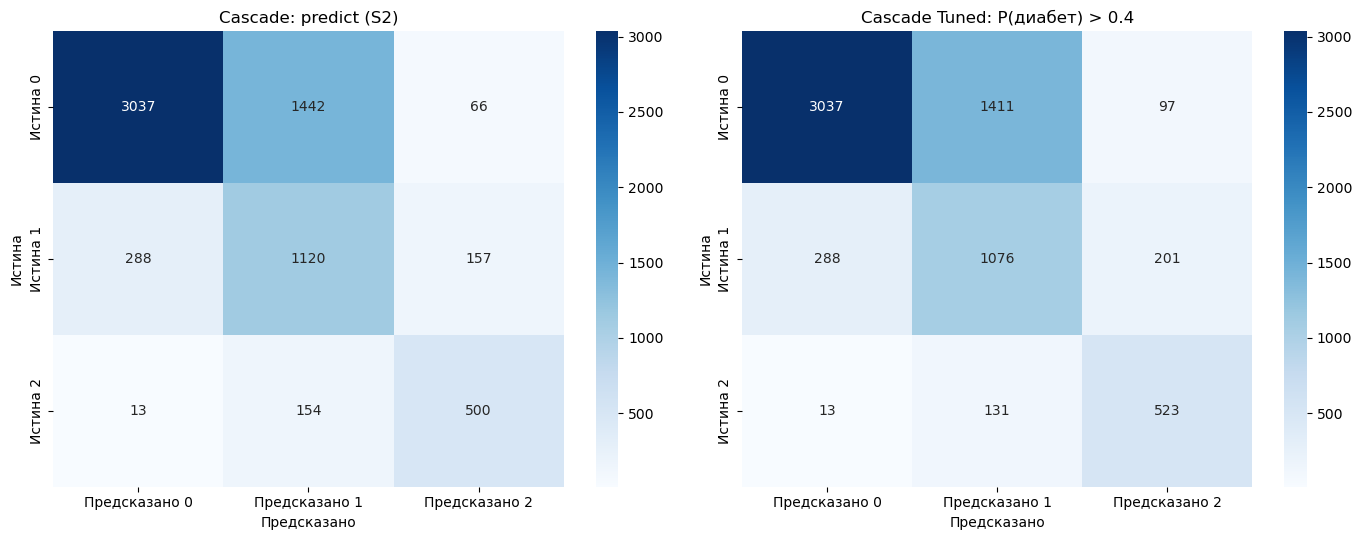

Confusion matrix Cascade (базовый S2=predict):
 [[3037 1442   66]
 [ 288 1120  157]
 [  13  154  500]]
Confusion matrix Cascade Tuned:
 [[3037 1411   97]
 [ 288 1076  201]
 [  13  131  523]]


In [14]:
# =============================================================================
# Cascade Classifier: стадия 1 — XGBoost + SMOTEENN (скрининг); стадия 2 — CatBoost (1 vs 2).
# Стадия 2: balance через scale_pos_weight. Требуются: X_train_scaled, X_test_scaled, y_train, y_test, RANDOM_STATE.
# =============================================================================

from catboost import CatBoostClassifier
from imblearn.combine import SMOTEENN
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    recall_score,
)
from xgboost import XGBClassifier

X_tr = np.asarray(X_train_scaled, dtype=float)
X_te = np.asarray(X_test_scaled, dtype=float)
y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()

# -----------------------------------------------------------------------------
# Шаг 1. Таргеты стадий
# -----------------------------------------------------------------------------
y_train_s1 = (y_tr > 0).astype(np.int32)
y_test_s1 = (y_te > 0).astype(np.int32)

mask_s2 = (y_tr == 1) | (y_tr == 2)
X_train_s2 = X_tr[mask_s2]
y_train_s2 = (y_tr[mask_s2] == 2).astype(np.int32)

print("Train Stage1: класс 0 (здоров) vs 1 (риск):", np.unique(y_train_s1, return_counts=True))
print(
    "Train Stage2 (только y in {1,2}), размер:",
    len(y_train_s2),
    "бинарный таргет 0=преддиабет, 1=диабет:",
    np.unique(y_train_s2, return_counts=True),
)
print("Test Stage1 (контроль):", np.unique(y_test_s1, return_counts=True))

n_s2_neg = int((y_train_s2 == 0).sum())
n_s2_pos = int((y_train_s2 == 1).sum())
scale_pos_weight_s2 = n_s2_neg / n_s2_pos if n_s2_pos else 1.0

print(f"scale_pos_weight: стадия 2 (CatBoost) = {scale_pos_weight_s2:.4f}  |  стадия 1: SMOTEENN + XGBoost (без SPW)")

# -----------------------------------------------------------------------------
# Шаг 2. Стадия 1: бинарный XGBoost на данных после SMOTEENN
# -----------------------------------------------------------------------------
THRESHOLD_S1 = 0.45

X_s1_res, y_s1_res = SMOTEENN(random_state=RANDOM_STATE).fit_resample(X_tr, y_train_s1)
print("Train Stage1 после SMOTEENN:", np.unique(y_s1_res, return_counts=True))

model_s1 = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.1,
    objective="binary:logistic",
    random_state=RANDOM_STATE,
    n_jobs=-1,
    eval_metric="logloss",
)
model_s1.fit(X_s1_res, y_s1_res)

probs_s1 = np.asarray(model_s1.predict_proba(X_te), dtype=float)[:, 1]
at_risk = probs_s1 > THRESHOLD_S1

# -----------------------------------------------------------------------------
# Шаг 3. Стадия 2: бинарный CatBoost (преддиабет vs диабет)
# -----------------------------------------------------------------------------
model_s2 = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.1,
    loss_function="Logloss",
    random_seed=RANDOM_STATE,
    verbose=False,
    scale_pos_weight=scale_pos_weight_s2,
)
model_s2.fit(X_train_s2, y_train_s2)

# -----------------------------------------------------------------------------
# Шаг 4. Итоговые предсказания на тесте
# -----------------------------------------------------------------------------
THRESHOLD_S2 = 0.4

final_preds = np.zeros(len(y_te), dtype=np.int32)
final_preds_tuned = np.zeros(len(y_te), dtype=np.int32)

final_preds[~at_risk] = 0
final_preds_tuned[~at_risk] = 0

if np.any(at_risk):
    X_te_risk = X_te[at_risk]
    probs_s2 = np.asarray(model_s2.predict_proba(X_te_risk), dtype=float)[:, 1]

    pred_s2 = np.asarray(model_s2.predict(X_te_risk)).astype(int).ravel()
    final_preds[at_risk] = np.where(pred_s2 == 0, 1, 2)

    final_preds_tuned[at_risk] = np.where(probs_s2 > THRESHOLD_S2, 2, 1)

# -----------------------------------------------------------------------------
# Базовая мультиклассовая CatBoost (для сравнения на тех же данных)
# -----------------------------------------------------------------------------
catboost_multiclass = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    verbose=False,
    auto_class_weights="Balanced",
)
catboost_multiclass.fit(X_tr, y_tr)
y_pred_multi = np.asarray(catboost_multiclass.predict(X_te)).astype(int).ravel()


def _metrics_row(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rec = recall_score(y_true, y_pred, labels=[0, 1, 2], average=None, zero_division=0)
    return {
        "model": name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "recall_0": float(rec[0]),
        "recall_1": float(rec[1]),
        "recall_2": float(rec[2]),
        "f1_1": float(
            f1_score(y_true, y_pred, labels=[1], average=None, zero_division=0)[0]
        ),
    }


cascade_compare_df = pd.DataFrame(
    [
        _metrics_row("CatBoost_Multiclass_Base", y_te, y_pred_multi),
        _metrics_row("Cascade_XGB_SMOTEENN__CatBoost_SPW", y_te, final_preds),
        _metrics_row("Cascade_XGB_SMOTEENN__CatBoost_SPW_Tuned", y_te, final_preds_tuned),
    ]
)

print(
    "\n=== Сравнение: мультиклассовый CatBoost vs Cascade (стадия 1: XGB+SMOTEENN, стадия 2: CatBoost SPW) ==="
)
print(cascade_compare_df.round(4).to_string(index=False))
print(
    f"Пороги: S1={THRESHOLD_S1}, S2={THRESHOLD_S2} "
    f"(если P(диабет на стадии 2) > {THRESHOLD_S2} → класс 2, иначе 1)."
)

try:
    from IPython.display import display

    display(
        cascade_compare_df.round(4).style.set_caption(
            f"Тест: y_test; S1={THRESHOLD_S1}: бинарный XGBoost (SMOTEENN); "
            f"стадия 2: CatBoost (scale_pos_weight); Tuned: порог S2={THRESHOLD_S2}."
        )
    )
except ImportError:
    pass

# -----------------------------------------------------------------------------
# Шаг 5. Confusion matrix 3x3
# -----------------------------------------------------------------------------
cm_cascade = confusion_matrix(y_te, final_preds, labels=[0, 1, 2])
cm_tuned = confusion_matrix(y_te, final_preds_tuned, labels=[0, 1, 2])

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, cm, title in zip(
    axes,
    (cm_cascade, cm_tuned),
    (
        "Cascade: predict (S2)",
        f"Cascade Tuned: P(диабет) > {THRESHOLD_S2}",
    ),
):
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Предсказано 0", "Предсказано 1", "Предсказано 2"],
        yticklabels=["Истина 0", "Истина 1", "Истина 2"],
        ax=ax,
    )
    ax.set_title(title)
    ax.set_xlabel("Предсказано")
    ax.set_ylabel("Истина")
plt.tight_layout()
plt.show()

print("Confusion matrix Cascade (базовый S2=predict):\n", cm_cascade)
print("Confusion matrix Cascade Tuned:\n", cm_tuned)


### CatBoost: сильно завышенные веса для преддиабета и диабета

Мультиклассовая модель на тех же `X_train_scaled` / `y_train`, что и **CatBoost balanced**, но вместо `auto_class_weights='Balanced'` задаются **явные** `class_weights`: класс 0 (здоров) — базовый вес **1.0**, классы **1** и **2** — сильно увеличены, чтобы модель реже «промахивалась» по группе риска и диабету (обычно растут recall по 1 и 2, ценой precision/accuracy).

Порядок весов: `[класс 0, класс 1, класс 2]`. Константы в коде можно подкрутить под отчёт.


Обучение CatBoost с class_weights= [1.0, 8.7, 23] (0=здоров, 1=преддиабет, 2=диабет)

=== Метрики (тест) ===
                     model  accuracy  balanced_accuracy  recall_0  recall_1  recall_2   f1_1
CatBoost_StrongWeights_1_2     0.578             0.6849    0.4717    0.7987    0.7841 0.4751

Classification report:
                precision    recall  f1-score   support

    Здоров (0)     0.9525    0.4717    0.6310      4545
Преддиабет (1)     0.3381    0.7987    0.4751      1565
    Диабет (2)     0.6309    0.7841    0.6992       667

      accuracy                         0.5780      6777
     macro avg     0.6405    0.6849    0.6018      6777
  weighted avg     0.7789    0.5780    0.6017      6777



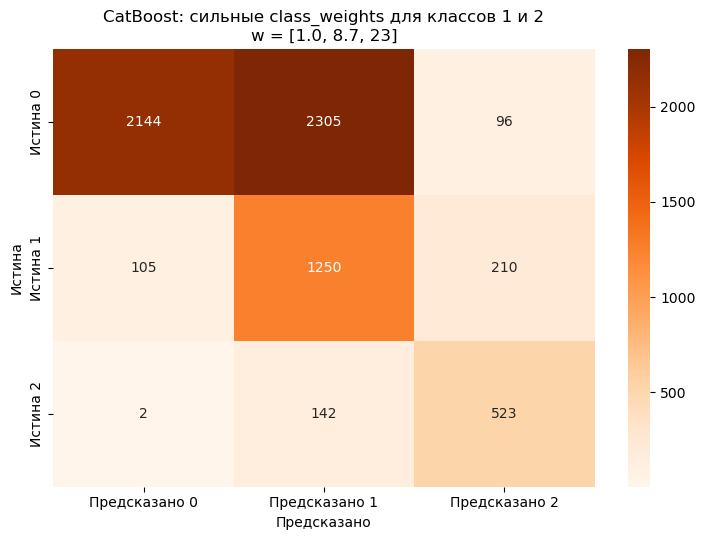


=== Сравнение: Balanced (auto) vs сильные веса 1/2 ===
                     model  accuracy  balanced_accuracy  recall_0  recall_1  recall_2   f1_1
    CatBoost_Balanced_Base    0.7078             0.7173    0.7173    0.6460    0.7886 0.5194
CatBoost_StrongWeights_1_2    0.5780             0.6849    0.4717    0.7987    0.7841 0.4751


In [15]:
# CatBoost multiclass: явные сильные веса для классов 1 (преддиабет) и 2 (диабет)
# Требуются: X_train_scaled, y_train, X_test_scaled, y_test, RANDOM_STATE.

from catboost import CatBoostClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    recall_score,
)

# Относительные веса: здоровые = 1.0; преддиабет и диабет — сильно выше (подбор под задачу диплома)
CLASS_WEIGHTS_STRONG_DIABETES = [1.0, 8.7, 23]

X_tr = np.asarray(X_train_scaled, dtype=float)
X_te = np.asarray(X_test_scaled, dtype=float)
y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()

catboost_strong_pathology = CatBoostClassifier(
    iterations=400,
    depth=6,
    learning_rate=0.1,
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    verbose=False,
    class_weights=CLASS_WEIGHTS_STRONG_DIABETES,
)

print(
    "Обучение CatBoost с class_weights=",
    CLASS_WEIGHTS_STRONG_DIABETES,
    "(0=здоров, 1=преддиабет, 2=диабет)",
)
catboost_strong_pathology.fit(X_tr, y_tr)

y_pred_strong = np.asarray(catboost_strong_pathology.predict(X_te)).astype(int).ravel()

rec = recall_score(y_te, y_pred_strong, labels=[0, 1, 2], average=None, zero_division=0)
strong_metrics_df = pd.DataFrame(
    [
        {
            "model": "CatBoost_StrongWeights_1_2",
            "accuracy": float(accuracy_score(y_te, y_pred_strong)),
            "balanced_accuracy": float(balanced_accuracy_score(y_te, y_pred_strong)),
            "recall_0": float(rec[0]),
            "recall_1": float(rec[1]),
            "recall_2": float(rec[2]),
            "f1_1": float(
                f1_score(y_te, y_pred_strong, labels=[1], average=None, zero_division=0)[0]
            ),
        }
    ]
)

print("\n=== Метрики (тест) ===")
print(strong_metrics_df.round(4).to_string(index=False))
print("\nClassification report:")
print(
    classification_report(
        y_te,
        y_pred_strong,
        labels=[0, 1, 2],
        target_names=["Здоров (0)", "Преддиабет (1)", "Диабет (2)"],
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(y_te, y_pred_strong, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=["Предсказано 0", "Предсказано 1", "Предсказано 2"],
    yticklabels=["Истина 0", "Истина 1", "Истина 2"],
    ax=ax,
)
ax.set_title(
    "CatBoost: сильные class_weights для классов 1 и 2\n"
    f"w = {CLASS_WEIGHTS_STRONG_DIABETES}"
)
ax.set_xlabel("Предсказано")
ax.set_ylabel("Истина")
plt.tight_layout()
plt.show()

# Сравнение с «обычным» balanced CatBoost, если модель уже обучена в ячейке выше
if "catboost_balanced_base" in globals():
    y_pred_bal = np.asarray(catboost_balanced_base.predict(X_te)).astype(int).ravel()
    rec_bal = recall_score(y_te, y_pred_bal, labels=[0, 1, 2], average=None, zero_division=0)
    compare_cb_df = pd.DataFrame(
        [
            {
                "model": "CatBoost_Balanced_Base",
                "accuracy": float(accuracy_score(y_te, y_pred_bal)),
                "balanced_accuracy": float(balanced_accuracy_score(y_te, y_pred_bal)),
                "recall_0": float(rec_bal[0]),
                "recall_1": float(rec_bal[1]),
                "recall_2": float(rec_bal[2]),
                "f1_1": float(
                    f1_score(y_te, y_pred_bal, labels=[1], average=None, zero_division=0)[0]
                ),
            },
        ]
    )
    compare_cb_df = pd.concat([compare_cb_df, strong_metrics_df], ignore_index=True)
    print("\n=== Сравнение: Balanced (auto) vs сильные веса 1/2 ===")
    print(compare_cb_df.round(4).to_string(index=False))
else:
    print(
        "\n(Для сравнения с CatBoost_Balanced_Base сначала выполните ячейку с catboost_balanced_base.)"
    )


### CatBoost: долгий тюнинг гиперпараметров (Optuna)

**Цель:** подобрать параметры мультиклассового `CatBoostClassifier` под ваш таргет (0/1/2) на **`X_train_scaled` / `y_train`**.

**Веса классов:** явные `class_weights = [1.0, cw1, cw2]` — **cw1** (преддиабет) и **cw2** (диабет) подбираются Optuna в **сильных** логарифмических диапазонах; `auto_class_weights` не используется (ожидаемо выше recall по 1/2, ниже precision по «здоровым»).

**Схема:** `StratifiedKFold` (несколько фолдов на train), метрика для Optuna — **средний Balanced Accuracy** по фолдам (можно сменить в коде). **TPE-sampler** + **MedianPruner** (отсев слабых trials).

**Режим «долго»:** по умолчанию заданы **`OPTUNA_N_TRIALS`** и **`OPTUNA_N_SPLITS`** — уменьшите их для быстрой проверки (например 15 trials / 2 фолда).

После поиска — переобучение **лучшей** конфигурации на **всём** train и отчёт на **`X_test_scaled` / `y_test`**. Модель сохраняется в `models/catboost_optuna_strong_pathology.cbm` (тюнинг + сильные веса классов 1 и 2).

**Зависимость:** `pip install optuna` (уже в `requirements-ml-notebook.txt`).


In [16]:
# =============================================================================
# CatBoost multiclass: долгий тюнинг Optuna + сильные веса классов 1 и 2
# Требуются: X_train_scaled, y_train, X_test_scaled, y_test, RANDOM_STATE, MODELS_DIR.
# Веса: class_weights = [1.0, w1, w2] — w1/w2 подбираются Optuna в «сильных» диапазонах
# (акцент на преддиабет и диабет); auto_class_weights не используется.
# =============================================================================

import optuna
from optuna.samplers import TPESampler
from optuna.pruners import MedianPruner
from catboost import CatBoostClassifier
from sklearn.metrics import balanced_accuracy_score
from sklearn.model_selection import StratifiedKFold

# --- Режим тюнинга ---
# Прерывание ячейки (Stop / Ctrl+C) во время model.fit даёт KeyboardInterrupt — Optuna
# помечает trial как failed; это не ошибка кода/весов, просто не дождались конца обучения.
OPTUNA_QUICK = False  # True: мало trials, 2 фолда, меньше верхняя граница iterations — для проверки пайплайна
OPTUNA_N_TRIALS = 8 if OPTUNA_QUICK else 100
OPTUNA_N_SPLITS = 2 if OPTUNA_QUICK else 3
OPTUNA_ITER_HIGH = 900 if OPTUNA_QUICK else 2500
OPTUNA_EARLY_STOP = 50 if OPTUNA_QUICK else 100
OPTUNA_SEED = RANDOM_STATE
OPTUNA_TIMEOUT_SEC = None  # например 7200 — ограничение по времени (сек), None = без лимита
SHOW_OPTUNA_PROGRESS = True  # лог Optuna

X_tr = np.asarray(X_train_scaled, dtype=float)
X_te = np.asarray(X_test_scaled, dtype=float)
y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()

skf = StratifiedKFold(n_splits=OPTUNA_N_SPLITS, shuffle=True, random_state=OPTUNA_SEED)


def _catboost_from_trial(trial: optuna.Trial) -> CatBoostClassifier:
    """Гиперпараметры + сильные относительные веса для классов 1 (преддиабет) и 2 (диабет)."""
    grow = trial.suggest_categorical("grow_policy", ["Depthwise", "Lossguide"])
    # Класс 0 — база 1.0; классы 1 и 2 — сильно завышены (диапазоны «жёсткие», как в дипломе)
    cw1 = trial.suggest_float("cw_class_1", 8, 10, log=True)
    cw2 = trial.suggest_float("cw_class_2", 20, 25, log=True)
    kw: dict = {
        "loss_function": "MultiClass",
        "random_seed": OPTUNA_SEED,
        "verbose": False,
        "thread_count": -1,
        "class_weights": [1.0, cw1, cw2],
        "iterations": trial.suggest_int("iterations", 400, OPTUNA_ITER_HIGH),
        "depth": trial.suggest_int("depth", 4, 10),
        "learning_rate": trial.suggest_float("learning_rate", 0.02, 0.35, log=True),
        "l2_leaf_reg": trial.suggest_float("l2_leaf_reg", 1.0, 30.0, log=True),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 1, 80),
        "bagging_temperature": trial.suggest_float("bagging_temperature", 0.0, 5.0),
        "random_strength": trial.suggest_float("random_strength", 0.0, 10.0),
        "border_count": trial.suggest_int("border_count", 32, 254),
        "grow_policy": grow,
    }
    if grow == "Lossguide":
        kw["max_leaves"] = trial.suggest_int("max_leaves", 16, 128)
    return CatBoostClassifier(**kw)


def objective(trial: optuna.Trial) -> float:
    scores: list[float] = []
    for fold_idx, (tr_idx, va_idx) in enumerate(skf.split(X_tr, y_tr)):
        model = _catboost_from_trial(trial)
        model.fit(
            X_tr[tr_idx],
            y_tr[tr_idx],
            eval_set=(X_tr[va_idx], y_tr[va_idx]),
            early_stopping_rounds=OPTUNA_EARLY_STOP,
            verbose=False,
        )
        y_va_pred = np.asarray(model.predict(X_tr[va_idx])).astype(int).ravel()
        scores.append(
            balanced_accuracy_score(y_tr[va_idx], y_va_pred)
        )
        trial.report(float(np.mean(scores)), fold_idx)
        if trial.should_prune():
            raise optuna.TrialPruned()
    return float(np.mean(scores))


print(
    f"Optuna: quick={OPTUNA_QUICK}, trials={OPTUNA_N_TRIALS}, folds={OPTUNA_N_SPLITS}, "
    f"iter_high={OPTUNA_ITER_HIGH}, early_stop={OPTUNA_EARLY_STOP}, "
    f"timeout_sec={OPTUNA_TIMEOUT_SEC}, metric=mean BalancedAccuracy (CV train); "
    f"class_weights=[1, cw1, cw2] с сильным акцентом на классы 1 и 2."
)

study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=OPTUNA_SEED),
    pruner=MedianPruner(n_startup_trials=8, n_warmup_steps=0),
)
study.optimize(
    objective,
    n_trials=OPTUNA_N_TRIALS,
    timeout=OPTUNA_TIMEOUT_SEC,
    show_progress_bar=SHOW_OPTUNA_PROGRESS,
)

print("\nЛучший trial:", study.best_trial.number, "value (CV BA):", study.best_value)
print("Лучшие params:", study.best_params)

# --- Финальная модель: убираем веса из **best (передаём списком) ---
best = study.best_params.copy()
cw1_best = float(best.pop("cw_class_1"))
cw2_best = float(best.pop("cw_class_2"))
class_weights_best = [1.0, cw1_best, cw2_best]
print(f"Итоговые class_weights (лучший trial): {class_weights_best}")

catboost_optuna_tuned = CatBoostClassifier(
    loss_function="MultiClass",
    random_seed=RANDOM_STATE,
    verbose=False,
    thread_count=-1,
    class_weights=class_weights_best,
    **best,
)
catboost_optuna_tuned.fit(X_tr, y_tr)

out_path = MODELS_DIR / "catboost_optuna_strong_pathology.cbm"
catboost_optuna_tuned.save_model(str(out_path))
print(f"Сохранено: {out_path}")

y_pred_tune = np.asarray(catboost_optuna_tuned.predict(X_te)).astype(int).ravel()
y_score_tune = np.asarray(catboost_optuna_tuned.predict_proba(X_te), dtype=float)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
    roc_auc_score,
)

LABELS_3 = [0, 1, 2]
CLASS_NAMES_3 = ["Здоров (0)", "Преддиабет (1)", "Диабет (2)"]

rep_dict = classification_report(
    y_te,
    y_pred_tune,
    labels=LABELS_3,
    target_names=CLASS_NAMES_3,
    output_dict=True,
    zero_division=0,
)
p0 = rep_dict["Здоров (0)"]["precision"]
r0 = rep_dict["Здоров (0)"]["recall"]
f1_0 = rep_dict["Здоров (0)"]["f1-score"]
p1 = rep_dict["Преддиабет (1)"]["precision"]
r1 = rep_dict["Преддиабет (1)"]["recall"]
f1_1 = rep_dict["Преддиабет (1)"]["f1-score"]
p2 = rep_dict["Диабет (2)"]["precision"]
r2 = rep_dict["Диабет (2)"]["recall"]
f1_2 = rep_dict["Диабет (2)"]["f1-score"]

auc_ovr = roc_auc_score(
    y_te,
    y_score_tune,
    multi_class="ovr",
    average=None,
    labels=LABELS_3,
)

optuna_full_metrics_df = pd.DataFrame(
    [
        {
            "model": "CatBoost_OptunaTuned_StrongPathology",
            "accuracy": float(accuracy_score(y_te, y_pred_tune)),
            "precision_0": float(p0),
            "recall_0": float(r0),
            "f1_0": float(f1_0),
            "precision_1": float(p1),
            "recall_1": float(r1),
            "f1_1": float(f1_1),
            "precision_2": float(p2),
            "recall_2": float(r2),
            "f1_2": float(f1_2),
            "balanced_accuracy": float(balanced_accuracy_score(y_te, y_pred_tune)),
            "mcc": float(matthews_corrcoef(y_te, y_pred_tune)),
            "roc_auc_ovr_0": float(auc_ovr[0]),
            "roc_auc_ovr_1": float(auc_ovr[1]),
            "roc_auc_ovr_2": float(auc_ovr[2]),
            "cv_balanced_accuracy_best": float(study.best_value),
            "cw_class_1": cw1_best,
            "cw_class_2": cw2_best,
        }
    ]
)

OPTUNA_FULL_COLS = [
    "model",
    "accuracy",
    "precision_0",
    "recall_0",
    "f1_0",
    "precision_1",
    "recall_1",
    "f1_1",
    "precision_2",
    "recall_2",
    "f1_2",
    "balanced_accuracy",
    "mcc",
    "roc_auc_ovr_0",
    "roc_auc_ovr_1",
    "roc_auc_ovr_2",
    "cv_balanced_accuracy_best",
    "cw_class_1",
    "cw_class_2",
]

print("\n=== Тест: полные метрики (Optuna + сильные веса 1/2) ===")
print(optuna_full_metrics_df[OPTUNA_FULL_COLS].round(4).to_string(index=False))

try:
    from IPython.display import display

    display(
        optuna_full_metrics_df[OPTUNA_FULL_COLS]
        .round(4)
        .style.set_caption(
            "CatBoost Optuna: class_weights=[1, cw1, cw2] с сильным сдвигом к преддиабету/диабету; "
            "ROC-AUC по predict_proba."
        )
    )
except ImportError:
    pass

print("\nClassification report:")
print(
    classification_report(
        y_te,
        y_pred_tune,
        labels=LABELS_3,
        target_names=CLASS_NAMES_3,
        digits=4,
        zero_division=0,
    )
)

cm = confusion_matrix(y_te, y_pred_tune, labels=[0, 1, 2])
fig, ax = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=["Предсказано 0", "Предсказано 1", "Предсказано 2"],
    yticklabels=["Истина 0", "Истина 1", "Истина 2"],
    ax=ax,
)
ax.set_title("CatBoost Optuna + сильные веса классов 1 и 2 (тест)")
plt.tight_layout()
plt.show()



[I 2026-04-20 21:18:16,927] A new study created in memory with name: no-name-deae0791-fa12-44c2-9407-8c8cb8696ca5


Optuna: quick=False, trials=100, folds=3, iter_high=2500, early_stop=100, timeout_sec=None, metric=mean BalancedAccuracy (CV train); class_weights=[1, cw1, cw2] с сильным акцентом на классы 1 и 2.


  0%|          | 0/100 [00:00<?, ?it/s]

[I 2026-04-20 21:18:27,097] Trial 0 finished with value: 0.676738473027157 and parameters: {'grow_policy': 'Lossguide', 'cw_class_1': 9.419493036852227, 'cw_class_2': 22.858408893657263, 'iterations': 727, 'depth': 5, 'learning_rate': 0.02361729398091682, 'l2_leaf_reg': 19.030368381735816, 'min_data_in_leaf': 49, 'bagging_temperature': 3.540362888980227, 'random_strength': 0.20584494295802447, 'border_count': 248, 'max_leaves': 110}. Best is trial 0 with value: 0.676738473027157.
[I 2026-04-20 21:18:37,760] Trial 1 finished with value: 0.691575464368089 and parameters: {'grow_policy': 'Depthwise', 'cw_class_1': 8.334196204132029, 'cw_class_2': 21.404944957346014, 'iterations': 1502, 'depth': 7, 'learning_rate': 0.046029779855239365, 'l2_leaf_reg': 8.012737503998538, 'min_data_in_leaf': 12, 'bagging_temperature': 1.4607232426760908, 'random_strength': 3.663618432936917, 'border_count': 133}. Best is trial 1 with value: 0.691575464368089.
[I 2026-04-20 21:18:48,528] Trial 2 finished with

KeyboardInterrupt: 

## RFE: CatBoost, XGBoost, LightGBM (`RFECV`)

**Данные:** train после split — `X_train_scaled`, `y_train` (без утечки теста). Если ячейка со split не выполнена, используются полные `X`, `y`.

**Параметры:** `RFECV(..., min_features_to_select=10, step=5, cv=5, scoring='balanced_accuracy')`. Для бустингов внутри каждого fold — train/val для `early_stopping_rounds=50` (как в ТЗ).

**Выход:** baseline CV на всех признаках, кривая качества по числу признаков, итоговые метрики после отбора, сравнение моделей, сохранение лучшей в `models/`.

In [17]:
# =============================================================================
# RFE (RFECV): CatBoost, XGBoost, LightGBM — baseline, отбор признаков, сравнение
# Требуются: RANDOM_STATE, MODELS_DIR, CatBoostClassifier, XGBClassifier, LGBMClassifier,
#   roc_auc_score, f1_score; joblib — в следующей ячейке
# Данные: предпочтительно X_train_scaled, y_train (после train_test_split).
# =============================================================================

from __future__ import annotations

from dataclasses import dataclass
from typing import Callable

import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, ClassifierMixin, clone
from sklearn.feature_selection import RFECV
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    make_scorer,
    matthews_corrcoef,
    roc_auc_score,
)
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split

from imblearn.combine import SMOTEENN
from lightgbm import LGBMClassifier

try:
    from lightgbm import early_stopping, log_evaluation
except ImportError:  # pragma: no cover
    early_stopping = None
    log_evaluation = None

LABELS_3 = [0, 1, 2]
CLASS_NAMES_3 = ["Здоров (0)", "Преддиабет (1)", "Диабет (2)"]

# --- Данные: train без теста ---
try:
    _X_rfe = np.asarray(X_train_scaled, dtype=float)
    _y_rfe = np.asarray(y_train).ravel()
    _feature_names_rfe = list(feature_cols)
    _rfe_data_src = "X_train_scaled/y_train"
except NameError:
    _X_rfe = np.asarray(X, dtype=float)
    _y_rfe = np.asarray(y).ravel()
    _feature_names_rfe = list(feature_cols)
    _rfe_data_src = "X/y"

print(
    f"RFE: n_samples={_X_rfe.shape[0]}, n_features={_X_rfe.shape[1]}, источник={_rfe_data_src}"
)


@dataclass
class RfeModelResult:
    name: str
    baseline: dict[str, float]
    rfecv: RFECV
    post_cv: dict[str, float]
    selected_features: list[str]
    importance_by_feature: pd.Series
    post_test: dict | None = None


def _roc_auc_macro_ovr(y_true, y_score, **kwargs) -> float:
    """OVR macro ROC-AUC. **kwargs — служебные (напр. needs_proba), sklearn 1.5+ прокидывает их в score_fn."""
    return float(
        roc_auc_score(
            y_true,
            y_score,
            multi_class="ovr",
            average="macro",
            labels=LABELS_3,
        )
    )


def _f1_macro_safe(y_true, y_pred, **kwargs) -> float:
    """f1 macro; **kwargs игнорируются (на случай прокидывания needs_proba и др.)."""
    return float(
        f1_score(
            y_true,
            y_pred,
            average="macro",
            labels=LABELS_3,
            zero_division=0,
        )
    )


def _make_scorers() -> dict[str, str | Callable]:
    return {
        "balanced_accuracy": "balanced_accuracy",
        "roc_auc_macro": make_scorer(
            _roc_auc_macro_ovr,
            response_method="predict_proba",
        ),
        "f1_macro": make_scorer(_f1_macro_safe),
    }


def _smote_enn_train_for_rfe(
    X_tr: np.ndarray,
    y_tr: np.ndarray,
    random_state: int,
) -> tuple[np.ndarray, np.ndarray]:
    """SMOTEENN на внутреннем train-сплите для RFECV (XGBoost/LightGBM вместо balanced весов)."""
    try:
        return SMOTEENN(random_state=random_state).fit_resample(X_tr, y_tr)
    except Exception:
        return X_tr, y_tr


class EarlyStoppingBoostingClassifier(ClassifierMixin, BaseEstimator):
    """Обёртка для RFECV: внутри каждого fit — stratified train/val и early stopping.
    ClassifierMixin должен быть слева от BaseEstimator (sklearn 1.6+ теги / predict_proba)."""

    def __init__(
        self,
        model_key: str = "CatBoost",
        random_state: int = 42,
        early_stopping_rounds: int = 50,
        val_size: float = 0.15,
    ):
        self.model_key = model_key
        self.random_state = random_state
        self.early_stopping_rounds = early_stopping_rounds
        self.val_size = val_size

    def _build_base(self):
        if self.model_key == "CatBoost":
            return CatBoostClassifier(
                iterations=400,
                depth=6,
                learning_rate=0.1,
                loss_function="MultiClass",
                random_seed=self.random_state,
                verbose=False,
                thread_count=-1,
                auto_class_weights="Balanced",
                eval_metric="MultiClass",
                early_stopping_rounds=self.early_stopping_rounds,
            )
        if self.model_key == "XGBoost":
            return XGBClassifier(
                n_estimators=400,
                max_depth=6,
                learning_rate=0.1,
                objective="multi:softprob",
                num_class=3,
                random_state=self.random_state,
                n_jobs=-1,
                eval_metric="mlogloss",
                early_stopping_rounds=self.early_stopping_rounds,
            )
        if self.model_key == "LightGBM":
            return LGBMClassifier(
                n_estimators=400,
                max_depth=-1,
                learning_rate=0.1,
                objective="multiclass",
                num_class=3,
                random_state=self.random_state,
                n_jobs=-1,
                verbose=-1,
                metric="multi_logloss",
            )
        raise ValueError(f"Неизвестный model_key: {self.model_key}")

    def fit(self, X, y, **fit_params):
        X = np.asarray(X, dtype=float)
        y = np.asarray(y).ravel()
        if X.shape[0] < 20:
            raise ValueError("Слишком мало объектов для train/val split внутри fold.")

        X_tr, X_val, y_tr, y_val = train_test_split(
            X,
            y,
            test_size=self.val_size,
            stratify=y,
            random_state=self.random_state,
        )

        self.estimator_ = self._build_base()

        if self.model_key == "CatBoost":
            self.estimator_.fit(
                X_tr,
                y_tr,
                eval_set=(X_val, y_val),
                verbose=False,
            )
        elif self.model_key == "XGBoost":
            X_tr_fit, y_tr_fit = _smote_enn_train_for_rfe(
                X_tr, y_tr, self.random_state
            )
            self.estimator_.fit(
                X_tr_fit,
                y_tr_fit,
                eval_set=[(X_val, y_val)],
                verbose=False,
            )
        elif self.model_key == "LightGBM":
            X_tr_fit, y_tr_fit = _smote_enn_train_for_rfe(
                X_tr, y_tr, self.random_state
            )
            if early_stopping is not None and log_evaluation is not None:
                self.estimator_.fit(
                    X_tr_fit,
                    y_tr_fit,
                    eval_set=[(X_val, y_val)],
                    callbacks=[
                        early_stopping(self.early_stopping_rounds, verbose=False),
                        log_evaluation(0),
                    ],
                )
            else:
                self.estimator_.fit(
                    X_tr_fit,
                    y_tr_fit,
                    eval_set=[(X_val, y_val)],
                    early_stopping_rounds=self.early_stopping_rounds,
                )
        else:
            self.estimator_.fit(X_tr, y_tr)

        self.classes_ = np.asarray(self.estimator_.classes_)
        self.n_features_in_ = X.shape[1]
        self.feature_importances_ = np.asarray(self.estimator_.feature_importances_)
        return self

    def predict(self, X):
        return self.estimator_.predict(np.asarray(X, dtype=float))

    def predict_proba(self, X):
        return self.estimator_.predict_proba(np.asarray(X, dtype=float))


def cv_metrics_multiclass(
    estimator: BaseEstimator,
    X: np.ndarray,
    y: np.ndarray,
    cv: int = 1,
    random_state: int = RANDOM_STATE,
) -> dict[str, float]:
    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    scorers = _make_scorers()
    out = cross_validate(
        clone(estimator),
        X,
        y,
        cv=skf,
        scoring=scorers,
        n_jobs=-1,
        error_score="raise",
    )
    return {
        "balanced_accuracy": float(np.mean(out["test_balanced_accuracy"])),
        "roc_auc_macro": float(np.mean(out["test_roc_auc_macro"])),
        "f1_macro": float(np.mean(out["test_f1_macro"])),
    }


def rfecv_feature_counts(n_in: int, step: int, min_f: int) -> list[int]:
    counts: list[int] = []
    n = n_in
    while n >= min_f:
        counts.append(n)
        if n == min_f:
            break
        n = max(min_f, n - step)
    return counts


RFE_FULL_METRICS_COLS: list[str] = [
    "model",
    "accuracy",
    "precision_0",
    "recall_0",
    "f1_0",
    "precision_1",
    "recall_1",
    "f1_1",
    "precision_2",
    "recall_2",
    "f1_2",
    "balanced_accuracy",
    "mcc",
    "f1_macro",
    "roc_auc_macro",
    "roc_auc_ovr_0",
    "roc_auc_ovr_1",
    "roc_auc_ovr_2",
]


def _rfe_roc_auc_ovr_per_class(y_true, y_score) -> dict[int, float]:
    aucs = roc_auc_score(
        y_true,
        y_score,
        multi_class="ovr",
        average=None,
        labels=LABELS_3,
    )
    return {int(l): float(a) for l, a in zip(LABELS_3, aucs)}


def rfe_full_metrics_row(model_name: str, y_true, y_pred, y_score) -> dict:
    """Те же поля, что `_full_metrics_row_cb` в ячейке CatBoost balanced."""
    rep_dict = classification_report(
        y_true,
        y_pred,
        labels=LABELS_3,
        target_names=CLASS_NAMES_3,
        output_dict=True,
        zero_division=0,
    )
    p0 = rep_dict["Здоров (0)"]["precision"]
    r0 = rep_dict["Здоров (0)"]["recall"]
    f1_0 = rep_dict["Здоров (0)"]["f1-score"]
    p1 = rep_dict["Преддиабет (1)"]["precision"]
    r1 = rep_dict["Преддиабет (1)"]["recall"]
    f1_1 = rep_dict["Преддиабет (1)"]["f1-score"]
    p2 = rep_dict["Диабет (2)"]["precision"]
    r2 = rep_dict["Диабет (2)"]["recall"]
    f2 = rep_dict["Диабет (2)"]["f1-score"]
    auc_map = _rfe_roc_auc_ovr_per_class(y_true, y_score)
    return {
        "model": model_name,
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "precision_0": p0,
        "recall_0": r0,
        "f1_0": f1_0,
        "precision_1": p1,
        "recall_1": r1,
        "f1_1": f1_1,
        "precision_2": p2,
        "recall_2": r2,
        "f1_2": f2,
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred)),
        "mcc": float(matthews_corrcoef(y_true, y_pred)),
        "f1_macro": float(
            f1_score(y_true, y_pred, average="macro", labels=LABELS_3, zero_division=0)
        ),
        "roc_auc_macro": float(
            roc_auc_score(
                y_true,
                y_score,
                multi_class="ovr",
                average="macro",
                labels=LABELS_3,
            )
        ),
        "roc_auc_ovr_0": auc_map[0],
        "roc_auc_ovr_1": auc_map[1],
        "roc_auc_ovr_2": auc_map[2],
    }


def run_rfe_for_model(
    model_key: str,
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    cv: int = 5,
    step: int = 5,
    min_features_to_select: int = 10,
    random_state: int = RANDOM_STATE,
    X_test: np.ndarray | None = None,
    y_test: np.ndarray | None = None,
) -> RfeModelResult:
    if X.shape[1] != len(feature_names):
        raise ValueError(
            f"Несоответствие размеров: X имеет {X.shape[1]} столбцов, "
            f"но feature_names содержит {len(feature_names)} имён."
        )

    base_est = EarlyStoppingBoostingClassifier(
        model_key=model_key,
        random_state=random_state,
        early_stopping_rounds=50,
        val_size=0.15,
    )
    baseline = cv_metrics_multiclass(base_est, X, y, cv=cv, random_state=random_state)

    skf = StratifiedKFold(n_splits=cv, shuffle=True, random_state=random_state)
    rfecv = RFECV(
        estimator=base_est,
        step=step,
        min_features_to_select=min_features_to_select,
        cv=skf,
        scoring="balanced_accuracy",
        n_jobs=1,
        importance_getter="auto",
    )
    rfecv.fit(X, y)

    mask = np.asarray(rfecv.support_, dtype=bool)
    selected = [feature_names[i] for i in range(len(feature_names)) if mask[i]]
    X_sel = X[:, mask]

    post_est = clone(EarlyStoppingBoostingClassifier(model_key=model_key, random_state=random_state))
    post_cv = cv_metrics_multiclass(post_est, X_sel, y, cv=cv, random_state=random_state)

    final_fit = clone(EarlyStoppingBoostingClassifier(model_key=model_key, random_state=random_state))
    final_fit.fit(X_sel, y)
    imp = np.asarray(final_fit.estimator_.feature_importances_, dtype=float)
    imp_series = pd.Series(imp, index=selected).sort_values(ascending=False)

    post_test: dict | None = None
    if X_test is not None and y_test is not None:
        X_test_arr = np.asarray(X_test, dtype=float)
        y_test_arr = np.asarray(y_test).ravel()
        if X_test_arr.shape[1] != X.shape[1]:
            raise ValueError(
                "X_test должен иметь столько же столбцов, сколько X (до отбора признаков)."
            )
        X_test_sel = X_test_arr[:, mask]
        y_pred_te = final_fit.predict(X_test_sel)
        y_proba_te = final_fit.predict_proba(X_test_sel)
        post_test = rfe_full_metrics_row(
            f"RFECV_{model_key}_test", y_test_arr, y_pred_te, y_proba_te
        )
        print(f"\n--- {model_key}: тест (hold-out), полные метрики ---")
        _rfe_test_metrics = pd.DataFrame([post_test])[RFE_FULL_METRICS_COLS].round(4)
        try:
            from IPython.display import display

            display(_rfe_test_metrics)
        except ImportError:
            print(_rfe_test_metrics.to_string(index=False))
        print("\nclassification_report:")
        print(
            classification_report(
                y_test_arr,
                y_pred_te,
                labels=LABELS_3,
                target_names=CLASS_NAMES_3,
                digits=4,
                zero_division=0,
            )
        )
        print("confusion_matrix (labels 0,1,2):")
        print(confusion_matrix(y_test_arr, y_pred_te, labels=LABELS_3))

    return RfeModelResult(
        name=model_key,
        baseline=baseline,
        rfecv=rfecv,
        post_cv=post_cv,
        selected_features=selected,
        importance_by_feature=imp_series,
        post_test=post_test,
    )


RFE: n_samples=27105, n_features=44, источник=X_train_scaled/y_train


In [18]:
# --- Запуск RFECV для трёх моделей (может занять много времени) ---
from collections import Counter

import joblib
import numpy as np
import pandas as pd

RFE_MODELS = ["CatBoost", "XGBoost", "LightGBM"]
RFE_STEP = 1

try:
    _X_test_rfe = np.asarray(X_test_scaled, dtype=float)
    _y_test_rfe = np.asarray(y_test).ravel()
except NameError:
    _X_test_rfe = None
    _y_test_rfe = None

rfe_results: dict[str, RfeModelResult] = {}
for mk in RFE_MODELS:
    print(f"\n{'='*60}\nRFECV: {mk}\n{'='*60}")
    rfe_results[mk] = run_rfe_for_model(
        mk,
        _X_rfe,
        _y_rfe,
        _feature_names_rfe,
        cv=5,
        step=RFE_STEP,
        min_features_to_select=10,
        random_state=RANDOM_STATE,
        X_test=_X_test_rfe,
        y_test=_y_test_rfe,
    )
    r = rfe_results[mk]
    dropped_features = [f for f in _feature_names_rfe if f not in set(r.selected_features)]

    print(f"Baseline CV: {r.baseline}")
    print(f"Оптимальное число признаков (RFECV): {r.rfecv.n_features_}")
    print(f"После RFECV (CV на отобранных): {r.post_cv}")
    print(f"Отобрано признаков: {len(r.selected_features)}")
    print(f"Отброшено признаков: {len(dropped_features)}")
    print("Список отброшенных признаков:")
    print(dropped_features)

# --- Сводная таблица ---
rows = []
for mk, r in rfe_results.items():
    row = {
        "model": mk,
        "n_features_optimal": int(r.rfecv.n_features_),
        "baseline_balanced_accuracy": r.baseline["balanced_accuracy"],
        "baseline_roc_auc_macro": r.baseline["roc_auc_macro"],
        "post_balanced_accuracy": r.post_cv["balanced_accuracy"],
        "post_roc_auc_macro": r.post_cv["roc_auc_macro"],
        "post_f1_macro": r.post_cv["f1_macro"],
    }
    if r.post_test is not None:
        row["test_accuracy"] = r.post_test["accuracy"]
        row["test_balanced_accuracy"] = r.post_test["balanced_accuracy"]
        row["test_roc_auc_macro"] = r.post_test["roc_auc_macro"]
        row["test_f1_macro"] = r.post_test["f1_macro"]
        row["test_mcc"] = r.post_test["mcc"]
    rows.append(row)

rfe_summary_df = pd.DataFrame(rows).sort_values(
    "post_balanced_accuracy", ascending=False
)
print("\n=== Сводка: baseline vs после RFECV (CV) ===")
print(rfe_summary_df.to_string(index=False))

best_model_name = rfe_summary_df.iloc[0]["model"]
best_r = rfe_results[best_model_name]
print(
    f"\n**Лучшая модель по post balanced_accuracy:** {best_model_name} "
    f"(BA={best_r.post_cv['balanced_accuracy']:.4f}, "
    f"ROC-AUC macro={best_r.post_cv['roc_auc_macro']:.4f})"
)
print(f"Число признаков: {best_r.rfecv.n_features_}")
print("Признаки:", best_r.selected_features)

print(
    "\nПримечание: RFECV выбирает число признаков по максимуму mean CV balanced_accuracy. "
    "Если нужен компромисс «меньше признаков при почти том же качестве», смотрите кривые ниже."
)

# --- Графики: balanced_accuracy по числу признаков (RFECV) ---
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
for ax, mk in zip(axes, RFE_MODELS):
    r = rfe_results[mk]
    cr = r.rfecv.cv_results_
    scores = np.asarray(cr["mean_test_score"], dtype=float)
    if isinstance(cr, dict) and "n_features" in cr:
        n_axis = np.asarray(cr["n_features"], dtype=int)
    else:
        n_axis = np.asarray(
            rfecv_feature_counts(_X_rfe.shape[1], step=RFE_STEP, min_f=10)[: len(scores)],
            dtype=int,
        )
    ax.plot(n_axis, scores, marker="o", markersize=4)
    ax.axvline(r.rfecv.n_features_, color="gray", linestyle="--", linewidth=1)
    ax.set_title(mk)
    ax.set_xlabel("Число признаков")
    ax.set_ylabel("mean CV balanced_accuracy")
    ax.grid(True, alpha=0.3)
plt.suptitle(f"RFECV: средний balanced_accuracy по CV при удалении признаков (step={RFE_STEP})")
plt.tight_layout()
plt.show()


# --- Рекомендации: признаки, отброшенные в большинстве моделей ---
all_feat = list(_feature_names_rfe)
selected_by = {mk: set(r.selected_features) for mk, r in rfe_results.items()}
drop_votes = {
    f: sum(1 for mk in RFE_MODELS if f not in selected_by[mk]) for f in all_feat
}
exclude_majority = sorted([f for f, v in drop_votes.items() if v >= 2])
print(
    "\nПризнаки, не вошедшие в финальный набор минимум у 2 из 3 моделей "
    f"(кандидаты на исключение): n={len(exclude_majority)}"
)
print(exclude_majority)

# Низкая относительная важность: нижний квартиль внутри отобранных признаков (по каждой модели)
low_q_sets: list[set[str]] = []
for mk in RFE_MODELS:
    s = rfe_results[mk].importance_by_feature
    if len(s) == 0:
        continue
    thr = s.quantile(0.25)
    low_q_sets.append(set(s[s <= thr].index))
if low_q_sets:
    votes = Counter()
    for st in low_q_sets:
        votes.update(st)
    low_in_majority = sorted([f for f, c in votes.items() if c >= 2])
    low_all_three = sorted(set.intersection(*low_q_sets)) if len(low_q_sets) == 3 else []
    print(
        "\nНижний квартиль важности (внутри финального набора) минимум у 2 из 3 моделей: "
        f"n={len(low_in_majority)}"
    )
    print(low_in_majority)
    print(
        "\nНижний квартиль одновременно у всех трёх моделей (пересечение): "
        f"n={len(low_all_three)}"
    )
    print(low_all_three)


# --- Сохранение лучшей модели и списка признаков ---
RFE_BEST_MODEL_PATH = MODELS_DIR / "rfe_best_estimator.joblib"
RFE_BEST_FEATURES_PATH = MODELS_DIR / "rfe_best_selected_features.joblib"
RFE_BEST_META_PATH = MODELS_DIR / "rfe_best_metadata.joblib"

joblib.dump(best_r.rfecv.estimator_, RFE_BEST_MODEL_PATH)
joblib.dump(best_r.selected_features, RFE_BEST_FEATURES_PATH)
joblib.dump(
    {
        "model_name": best_model_name,
        "n_features": best_r.rfecv.n_features_,
        "selected_features": best_r.selected_features,
        "baseline_cv": best_r.baseline,
        "post_rfe_cv": best_r.post_cv,
        "post_rfe_test": best_r.post_test,
        "data_source": _rfe_data_src,
    },
    RFE_BEST_META_PATH,
)
print(
    f"\nСохранено: {RFE_BEST_MODEL_PATH}, {RFE_BEST_FEATURES_PATH}, {RFE_BEST_META_PATH}"
)



RFECV: CatBoost

--- CatBoost: тест (hold-out), полные метрики ---


,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,f1_macro,roc_auc_macro,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,RFECV_CatBoost_test,0.7041,0.9019,0.7083,0.7934,0.4297,0.6524,0.5181,0.6394,0.7976,0.7098,0.7194,0.4832,0.6738,0.8647,0.8673,0.7657,0.9611



classification_report:
                precision    recall  f1-score   support

    Здоров (0)     0.9019    0.7083    0.7934      4545
Преддиабет (1)     0.4297    0.6524    0.5181      1565
    Диабет (2)     0.6394    0.7976    0.7098       667

      accuracy                         0.7041      6777
     macro avg     0.6570    0.7194    0.6738      6777
  weighted avg     0.7670    0.7041    0.7216      6777

confusion_matrix (labels 0,1,2):
[[3219 1232   94]
 [ 338 1021  206]
 [  12  123  532]]
Baseline CV: {'balanced_accuracy': 0.717763494987177, 'roc_auc_macro': 0.8667153961594714, 'f1_macro': 0.6769321554300107}
Оптимальное число признаков (RFECV): 34
После RFECV (CV на отобранных): {'balanced_accuracy': 0.7216384491690052, 'roc_auc_macro': 0.8662798875863971, 'f1_macro': 0.6788668152508309}
Отобрано признаков: 34
Отброшено признаков: 10
Список отброшенных признаков:
['RIAGENDR', 'hypertension', 'LBXTR', 'DMDEDUC2', 'LBXSASS', 'LBXSAL', 'MCQ160A', 'MCQ160E', 'MCQ160F', 'Log_C

,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,f1_macro,roc_auc_macro,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,RFECV_XGBoost_test,0.6444,0.9159,0.5967,0.7226,0.3761,0.715,0.493,0.6373,0.8036,0.7109,0.7051,0.4394,0.6421,0.848,0.8492,0.7375,0.9572



classification_report:
                precision    recall  f1-score   support

    Здоров (0)     0.9159    0.5967    0.7226      4545
Преддиабет (1)     0.3761    0.7150    0.4930      1565
    Диабет (2)     0.6373    0.8036    0.7109       667

      accuracy                         0.6444      6777
     macro avg     0.6431    0.7051    0.6421      6777
  weighted avg     0.7638    0.6444    0.6684      6777

confusion_matrix (labels 0,1,2):
[[2712 1733  100]
 [ 241 1119  205]
 [   8  123  536]]
Baseline CV: {'balanced_accuracy': 0.702150514806732, 'roc_auc_macro': 0.8459032395678108, 'f1_macro': 0.6273075307997982}
Оптимальное число признаков (RFECV): 27
После RFECV (CV на отобранных): {'balanced_accuracy': 0.7084613340483278, 'roc_auc_macro': 0.8529370408502543, 'f1_macro': 0.6497236229445083}
Отобрано признаков: 27
Отброшено признаков: 17
Список отброшенных признаков:
['BMXHT', 'BMXWAIST', 'LBDHDD', 'LBXTR', 'LBXSAT', 'LBXSASS', 'LBXSUA', 'LBXSAPSI', 'LBXWBCSI', 'LBXLYPCT', 'M

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/

KeyboardInterrupt: 

## Ансамбль: LightGBM + XGBoost + CatBoost

**Баланс при обучении:** как в режиме «Веса классов (balanced)» в таблице сравнения: XGBoost — `sample_weight` balanced (обёртка); LightGBM — `class_weight="balanced"`; CatBoost — `auto_class_weights="Balanced"`.

**Подбор через Optuna:** в отдельной ячейке подбираются веса трёх баз (`ENSEMBLE_LGB_XGB_CB_VOTE_WEIGHTS`) и множители сдвига классов (`ENSEMBLE_LGB_XGB_CB_CLASS_TILT`) на внутреннем `train/val`-сплите внутри train (без утечки test).

**Лёгкий приоритет «нездоровья»:** objective оптимизирует `balanced_accuracy` с небольшим бонусом за recall классов **1** и **2**, чтобы мягко сдвинуть решение от класса 0.

**Сдвиг решения:** после усреднения вероятностей столбцы классов **0 / 1 / 2** умножаются на коэффициенты tilt, затем вероятности нормируются по строке и берётся `argmax`.

**Нужно выполнить ранее:** данные и ячейку с `apply_balancing` / `make_fresh_model`.


In [ ]:
# Optuna-подбор vote-weights и class-tilt для ансамбля LGB + XGB + CB
# С мягким приоритетом «нездоровья» (классы 1/2) в objective.
import optuna
from optuna.samplers import TPESampler

from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_sample_weight


class _XGBoostBalancedSampleWeightTune(ClassifierMixin, BaseEstimator):
    def fit(self, X, y):
        self.estimator_ = make_fresh_model("XGBoost", "class_weight_balanced")
        sw = compute_sample_weight("balanced", y)
        self.estimator_.fit(X, y, sample_weight=sw)
        self.classes_ = self.estimator_.classes_
        return self

    def predict(self, X):
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)


X_ens_tr, X_ens_val, y_ens_tr, y_ens_val = train_test_split(
    X_train_scaled,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train,
)

xgb_tune = _XGBoostBalancedSampleWeightTune().fit(X_ens_tr, y_ens_tr)
lgb_tune = make_fresh_model("LightGBM", "class_weight_balanced")
lgb_tune.fit(X_ens_tr, y_ens_tr)
cb_tune = make_fresh_model("CatBoost", "class_weight_balanced")
cb_tune.fit(X_ens_tr, y_ens_tr)

p_xgb = np.asarray(xgb_tune.predict_proba(X_ens_val), dtype=float)
p_lgb = np.asarray(lgb_tune.predict_proba(X_ens_val), dtype=float)
p_cb = np.asarray(cb_tune.predict_proba(X_ens_val), dtype=float)

OPTUNA_ENSEMBLE_TRIALS = 60
OPTUNA_UNHEALTHY_BIAS = 0.035


def _eval_ensemble(vote_weights: np.ndarray, tilt: np.ndarray) -> tuple[float, float, float]:
    base = (vote_weights[0] * p_xgb) + (vote_weights[1] * p_lgb) + (vote_weights[2] * p_cb)
    tilted = base * tilt
    proba = tilted / np.clip(tilted.sum(axis=1, keepdims=True), 1e-12, None)
    pred = np.argmax(proba, axis=1)
    bacc = balanced_accuracy_score(y_ens_val, pred)
    r1 = recall_score(y_ens_val, pred, labels=[1], average="macro", zero_division=0)
    r2 = recall_score(y_ens_val, pred, labels=[2], average="macro", zero_division=0)
    return float(bacc), float(r1), float(r2)


def objective(trial: optuna.Trial) -> float:
    w_xgb = trial.suggest_float("w_xgb", 0.4, 0.4)
    w_lgb = trial.suggest_float("w_lgb", 0.2, 0.2)
    w_cb = trial.suggest_float("w_cb", 0.4, 0.4)

    vote = np.asarray([w_xgb, w_lgb, w_cb], dtype=float)
    vote = vote / np.clip(vote.sum(), 1e-12, None)

    # Лёгкий сдвиг в пользу «нездоровья» (классы 1 и 2), не экстремальный.
    t1 = trial.suggest_float("tilt_1", 2, 2.2)
    t2 = trial.suggest_float("tilt_2", 2.5, 2.75)
    tilt = np.array([1.0, t1, t2], dtype=float)

    bacc, r1, r2 = _eval_ensemble(vote, tilt)
    score = bacc + OPTUNA_UNHEALTHY_BIAS * (0.5 * r1 + 0.5 * r2)

    trial.set_user_attr("bacc", bacc)
    trial.set_user_attr("recall_1", r1)
    trial.set_user_attr("recall_2", r2)
    return float(score)


study = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
)
study.optimize(objective, n_trials=OPTUNA_ENSEMBLE_TRIALS, show_progress_bar=False)

bp = study.best_params
vote_best = np.asarray([bp["w_xgb"], bp["w_lgb"], bp["w_cb"]], dtype=float)
vote_best = vote_best / np.clip(vote_best.sum(), 1e-12, None)
tilt_best = np.array([1.0, bp["tilt_1"], bp["tilt_2"]], dtype=float)

ENSEMBLE_LGB_XGB_CB_VOTE_WEIGHTS = vote_best.tolist()
ENSEMBLE_LGB_XGB_CB_CLASS_TILT = tilt_best

best_bacc = float(study.best_trial.user_attrs.get("bacc", np.nan))
best_r1 = float(study.best_trial.user_attrs.get("recall_1", np.nan))
best_r2 = float(study.best_trial.user_attrs.get("recall_2", np.nan))

print(
    "=== Optuna-подбор ансамбля LGB + XGB + CB (train-val) ===\n"
    f"Trials: {OPTUNA_ENSEMBLE_TRIALS}\n"
    f"Best objective: {study.best_value:.4f}\n"
    f"Best val balanced_accuracy: {best_bacc:.4f}\n"
    f"Best val recall class 1: {best_r1:.4f}\n"
    f"Best val recall class 2: {best_r2:.4f}\n"
    f"Voting weights [xgb,lgb,cb]: {ENSEMBLE_LGB_XGB_CB_VOTE_WEIGHTS}\n"
    f"Class tilt [0,1,2]: {ENSEMBLE_LGB_XGB_CB_CLASS_TILT.tolist()}\n"
)


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-19 20:51:37,098] A new study created in memory with name: no-name-b5b85e46-4f00-4b47-b070-baee2d2fb4b4
[I 2026-04-19 20:51:37,101] Trial 0 finished with value: 0.7540756983693483 and parameters: {'w_xgb': 0.4, 'w_lgb': 0.2, 'w_cb': 0.4, 'tilt_1': 2.0749080237694724, 'tilt_2': 2.737678576602479}. Best is trial 0 with value: 0.7540756983693483.
[I 2026-04-19 20:51:37,104] Trial 1 finished with value: 0.7528835797005773 and parameters: {'w_xgb': 0.4, 'w_lgb': 0.2, 'w_cb': 0.4, 'tilt_1': 2.1463987883622813, 'tilt_2': 2.649664621049259}. Best is trial 0 with value: 0.7540756983693483.
[I 2026-04-19 20:51:37,106] Trial 2 finished with value: 0.7534587505567707 and parameters: {'w_xgb': 0.4, 'w_lgb': 0.2, 'w_cb': 0.4, 'tilt_1': 2.0312037280884874, 'tilt_2': 2.5389986300840506}. Best is trial

=== Optuna-подбор ансамбля LGB + XGB + CB (train-val) ===
Trials: 60
Best objective: 0.7557
Best val balanced_accuracy: 0.7287
Best val recall class 1: 0.7165
Best val recall class 2: 0.8274
Voting weights [xgb,lgb,cb]: [0.4, 0.2, 0.4]
Class tilt [0,1,2]: [1.0, 2.0029034203176717, 2.7269161988206294]



=== Ансамбль (LGB + XGB + CB, soft vote + сдвиг классов) ===
Voting weights [xgb,lgb,cb]: [0.4, 0.2, 0.4]  |  tilt [0,1,2]: [1.0, 2.1, 2.5]

                precision    recall  f1-score   support

    Здоров (0)       0.93      0.60      0.73      4545
Преддиабет (1)       0.38      0.75      0.51      1565
    Диабет (2)       0.66      0.77      0.71       667

      accuracy                           0.65      6777
     macro avg       0.66      0.71      0.65      6777
  weighted avg       0.78      0.65      0.67      6777

Balanced accuracy: 0.7060
MCC: 0.4526
ROC-AUC OVR (macro), сырые proba ансамбля (без сдвига классов): 0.8703
ROC-AUC OVR (macro), после сдвига (те же proba, что и для argmax): 0.8617

Confusion matrix (строки — истина, столбцы — предсказание):
                Здоров (0)  Преддиабет (1)  Диабет (2)
Здоров (0)            2707            1757          81
Преддиабет (1)         203            1172         190
Диабет (2)               5             146         516


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


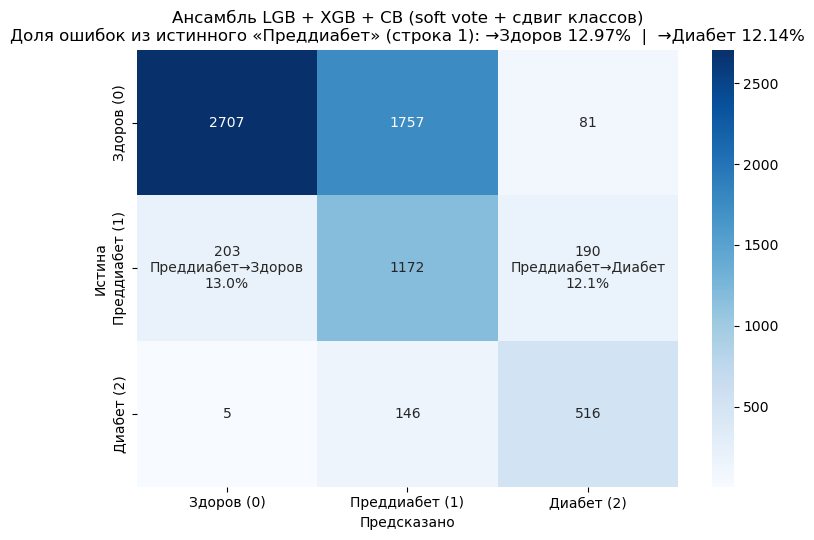

,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,Ensemble_LGB_XGB_CB_tilt_pred_diab,0.6485,0.9286,0.5956,0.7257,0.3811,0.7489,0.5052,0.6557,0.7736,0.7098,0.706,0.4526,0.8693,0.7553,0.9606


In [20]:
# Ансамбль LGB + XGB + CB: VotingClassifier (soft);
# использует ENSEMBLE_* из ячейки подбора (или из ручного override, если задан).
from sklearn.utils.class_weight import compute_sample_weight

VW_lx = globals().get("ENSEMBLE_LGB_XGB_CB_VOTE_WEIGHTS", [0.4, 0.2, 0.4])
_tilt_lx = globals().get("ENSEMBLE_LGB_XGB_CB_CLASS_TILT")
if _tilt_lx is None:
    ENSEMBLE_CLASS_WEIGHTS = np.array([1.0, 2.1, 2.5], dtype=float)
else:
    ENSEMBLE_CLASS_WEIGHTS = np.asarray(_tilt_lx, dtype=float)

# ClassifierMixin перед BaseEstimator — иначе в sklearn ≥1.6 is_classifier() = False (теги из BaseEstimator).
class _XGBoostBalancedSampleWeight(ClassifierMixin, BaseEstimator):
    """XGBoost с sample_weight balanced — VotingClassifier не задаёт разные fit-параметры по моделям."""

    def fit(self, X, y):
        self.estimator_ = make_fresh_model("XGBoost", "class_weight_balanced")
        sw = compute_sample_weight("balanced", y)
        self.estimator_.fit(X, y, sample_weight=sw)
        self.classes_ = self.estimator_.classes_
        return self

    def predict(self, X):
        return self.estimator_.predict(X)

    def predict_proba(self, X):
        return self.estimator_.predict_proba(X)


X_cw_ens, y_cw_ens = apply_balancing("class_weight_balanced", X_train_scaled, y_train)

ensemble_lgb_xgb_cb = VotingClassifier(
    estimators=[
        ("xgb", _XGBoostBalancedSampleWeight()),
        ("lgb", make_fresh_model("LightGBM", "class_weight_balanced")),
        ("cb", make_fresh_model("CatBoost", "class_weight_balanced")),
    ],
    voting="soft",
    weights=list(VW_lx),
    n_jobs=-1,
)
ensemble_lgb_xgb_cb.fit(X_cw_ens, y_cw_ens)

ensemble_lgb_xgb_cb_proba_raw = np.asarray(
    ensemble_lgb_xgb_cb.predict_proba(X_test_scaled), dtype=float
)
# Сместить итог по столбцам [0,1,2], затем renorm (ENSEMBLE_CLASS_WEIGHTS заданы в начале ячейки).
tilted = ensemble_lgb_xgb_cb_proba_raw * ENSEMBLE_CLASS_WEIGHTS
ensemble_lgb_xgb_cb_proba = tilted / tilted.sum(axis=1, keepdims=True)
ensemble_lgb_xgb_cb_pred = np.argmax(ensemble_lgb_xgb_cb_proba, axis=1)

print(
    "=== Ансамбль (LGB + XGB + CB, soft vote + сдвиг классов) ===\n"
    f"Voting weights [xgb,lgb,cb]: {list(VW_lx)}  |  tilt [0,1,2]: {ENSEMBLE_CLASS_WEIGHTS.tolist()}\n"
)
print(
    classification_report(
        y_test,
        ensemble_lgb_xgb_cb_pred,
        labels=[0, 1, 2],
        target_names=["Здоров (0)", "Преддиабет (1)", "Диабет (2)"],
        zero_division=0,
    )
)
print(f"Balanced accuracy: {balanced_accuracy_score(y_test, ensemble_lgb_xgb_cb_pred):.4f}")
print(f"MCC: {matthews_corrcoef(y_test, ensemble_lgb_xgb_cb_pred):.4f}")
print(
    "ROC-AUC OVR (macro), сырые proba ансамбля (без сдвига классов): "
    f"{roc_auc_score(y_test, ensemble_lgb_xgb_cb_proba_raw, multi_class='ovr', labels=[0, 1, 2]):.4f}"
)
print(
    "ROC-AUC OVR (macro), после сдвига (те же proba, что и для argmax): "
    f"{roc_auc_score(y_test, ensemble_lgb_xgb_cb_proba, multi_class='ovr', labels=[0, 1, 2]):.4f}"
)
cm_ens = confusion_matrix(y_test, ensemble_lgb_xgb_cb_pred, labels=LABELS)
print("\nConfusion matrix (строки — истина, столбцы — предсказание):")
print(pd.DataFrame(cm_ens, index=CLASS_NAMES, columns=CLASS_NAMES))

row1_sum_ens = cm_ens[1].sum()
pct_to_0_ens = 100.0 * cm_ens[1, 0] / row1_sum_ens if row1_sum_ens else 0.0
pct_to_2_ens = 100.0 * cm_ens[1, 2] / row1_sum_ens if row1_sum_ens else 0.0
ann_ens = np.empty((3, 3), dtype=object)
for i in range(3):
    for j in range(3):
        c = int(cm_ens[i, j])
        if i == 1 and j == 0:
            ann_ens[i, j] = f"{c}\nПреддиабет→Здоров\n{pct_to_0_ens:.1f}%"
        elif i == 1 and j == 2:
            ann_ens[i, j] = f"{c}\nПреддиабет→Диабет\n{pct_to_2_ens:.1f}%"
        else:
            ann_ens[i, j] = str(c)

fig_ens, ax_ens = plt.subplots(figsize=(7.5, 5.5))
sns.heatmap(
    cm_ens,
    annot=ann_ens,
    fmt="",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES,
    ax=ax_ens,
)
ax_ens.set_xlabel("Предсказано")
ax_ens.set_ylabel("Истина")
ax_ens.set_title(
    "Ансамбль LGB + XGB + CB (soft vote + сдвиг классов)\n"
    f"Доля ошибок из истинного «Преддиабет» (строка 1): "
    f"→Здоров {pct_to_0_ens:.2f}%  |  →Диабет {pct_to_2_ens:.2f}%"
)
plt.tight_layout()
plt.show()

if "_full_metrics_row_cb" in globals():
    from IPython.display import display

    row_ens = _full_metrics_row_cb(
        "Ensemble_LGB_XGB_CB_tilt_pred_diab",
        y_test,
        ensemble_lgb_xgb_cb_pred,
        ensemble_lgb_xgb_cb_proba,
    )
    if "_cb_full_cols" in globals():
        display(pd.DataFrame([row_ens])[_cb_full_cols].round(4))
    else:
        display(pd.DataFrame([row_ens]).round(4))
else:
    print(
        "\n(Полная строка метрик как у CatBoost balanced: выполните ячейку с `_full_metrics_row_cb`.)"
    )

In [21]:
# Ordinal classification (Frank & Hall): два бинарных CatBoost
# **PrediabFocus:** веса обучения (`sample_weight`) — аналог `scale_pos_weight` + усиление преддиабета (y=1);
#   затем лёгкий пост-сдвиг `FH_CLASS_TILT` по вероятностям.
# **База:** те же модели без ручных весов, только `auto_class_weights="Balanced"`.

from __future__ import annotations

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    matthews_corrcoef,
    mean_absolute_error,
    roc_auc_score,
)
from sklearn.utils.class_weight import compute_sample_weight
from catboost import CatBoostClassifier

try:
    _rs = RANDOM_STATE
except NameError:
    _rs = 42

try:
    X_tr = np.asarray(X_train_scaled, dtype=float)
    X_te = np.asarray(X_test_scaled, dtype=float)
    _x_src = "X_train_scaled / X_test_scaled"
except NameError:
    X_tr = np.asarray(X_train, dtype=float)
    X_te = np.asarray(X_test, dtype=float)
    _x_src = "X_train / X_test"

y_tr = np.asarray(y_train).ravel()
y_te = np.asarray(y_test).ravel()

y_gt0_tr = (y_tr > 0).astype(np.int32)
y_gt1_tr = (y_tr > 1).astype(np.int32)

# --- Веса для бинарников (CatBoost: `sample_weight`; XGBoost-аналог scale_pos_weight + акцент на y=1) ---
# clf0: положительный класс = «есть патология» (y in {1,2}). Усиливаем примеры с y=1, ослабляем y=2.
FH_CLF0_PRED_BOOST = 1.55
FH_CLF0_DIAB_DOWN = 0.88
# clf1: положительный класс = диабет (y=2). Приглушаем диабет; среди отрицательных усиливаем преддиабет (y=1).
FH_CLF1_DIAB_DOWN = 0.82
FH_CLF1_PRED_NEG_BOOST = 1.35

sw0 = compute_sample_weight("balanced", y_gt0_tr).astype(np.float64)
m = (y_gt0_tr == 1) & (y_tr == 1)
sw0[m] *= FH_CLF0_PRED_BOOST
m = (y_gt0_tr == 1) & (y_tr == 2)
sw0[m] *= FH_CLF0_DIAB_DOWN

sw1 = compute_sample_weight("balanced", y_gt1_tr).astype(np.float64)
sw1[y_tr == 2] *= FH_CLF1_DIAB_DOWN
m = (y_gt1_tr == 0) & (y_tr == 1)
sw1[m] *= FH_CLF1_PRED_NEG_BOOST

_cb_auto = dict(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    auto_class_weights="Balanced",
    random_seed=_rs,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
)
_cb_sw = dict(
    iterations=400,
    depth=6,
    learning_rate=0.05,
    loss_function="Logloss",
    random_seed=_rs,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1,
)

clf0_base = CatBoostClassifier(**_cb_auto)
clf1_base = CatBoostClassifier(**_cb_auto)
clf0_base.fit(X_tr, y_gt0_tr)
clf1_base.fit(X_tr, y_gt1_tr)

clf0 = CatBoostClassifier(**_cb_sw)
clf1 = CatBoostClassifier(**_cb_sw)
clf0.fit(X_tr, y_gt0_tr, sample_weight=sw0)
clf1.fit(X_tr, y_gt1_tr, sample_weight=sw1)

# Базовые вероятности (без ручных весов) — только auto_class_weights
p0b_gt0 = clf0_base.predict_proba(X_te)[:, 1]
p0b_gt1 = clf1_base.predict_proba(X_te)[:, 1]
p0_ = 1.0 - p0b_gt0
p1_ = np.maximum(p0b_gt0 - p0b_gt1, 0.0)
p2_ = p0b_gt1
proba_fh_base = np.column_stack([p0_, p1_, p2_])
rsb = proba_fh_base.sum(axis=1, keepdims=True)
proba_fh_base = np.where(rsb > 0, proba_fh_base / rsb, proba_fh_base)

# Взвешенное обучение → вероятности до пост-сдвига
p_gt0 = clf0.predict_proba(X_te)[:, 1]
p_gt1 = clf1.predict_proba(X_te)[:, 1]
p0 = 1.0 - p_gt0
p1 = np.maximum(p_gt0 - p_gt1, 0.0)
p2 = p_gt1
proba_fh_weighted = np.column_stack([p0, p1, p2])
rsw = proba_fh_weighted.sum(axis=1, keepdims=True)
proba_fh_weighted = np.where(rsw > 0, proba_fh_weighted / rsw, proba_fh_weighted)

# Пост-сдвиг (мягче, т.к. часть сигнала уже в sample_weight)
FH_CLASS_TILT = np.array([1.0, 2, 1], dtype=float)
proba_fh = proba_fh_weighted * FH_CLASS_TILT
proba_fh = proba_fh / proba_fh.sum(axis=1, keepdims=True)

y_pred_base = np.argmax(proba_fh_base, axis=1)
y_pred_w = np.argmax(proba_fh_weighted, axis=1)
y_pred = np.argmax(proba_fh, axis=1)

LABELS_3 = [0, 1, 2]
NAMES_3 = ["Здоров (0)", "Преддиабет (1)", "Диабет (2)"]

print("=== Frank–Hall: 2× CatBoost — база (auto Balanced) vs PrediabFocus (sample_weight + tilt) ===")
print(f"Признаки: {_x_src}, n_train={X_tr.shape[0]}, n_features={X_tr.shape[1]}")
print(
    f"PrediabFocus: sample_weight = balanced × "
    f"clf0[ y=1×{FH_CLF0_PRED_BOOST}, y=2×{FH_CLF0_DIAB_DOWN} ], "
    f"clf1[ y=2×{FH_CLF1_DIAB_DOWN}, neg_y1×{FH_CLF1_PRED_NEG_BOOST} ]"
)
print(f"Пост-сдвиг вероятностей FH_CLASS_TILT = {FH_CLASS_TILT.tolist()}\n")


def _row_metrics(name: str, y_true, y_pred_, proba_for_auc) -> dict:
    if "_full_metrics_row_cb" in globals():
        return dict(_full_metrics_row_cb(name, y_true, y_pred_, proba_for_auc))
    rep_dict = classification_report(
        y_true,
        y_pred_,
        labels=LABELS_3,
        target_names=NAMES_3,
        output_dict=True,
        zero_division=0,
    )
    aucs = roc_auc_score(
        y_true,
        proba_for_auc,
        multi_class="ovr",
        average=None,
        labels=LABELS_3,
    )
    return {
        "model": name,
        "accuracy": float(accuracy_score(y_true, y_pred_)),
        "precision_0": rep_dict[NAMES_3[0]]["precision"],
        "recall_0": rep_dict[NAMES_3[0]]["recall"],
        "f1_0": rep_dict[NAMES_3[0]]["f1-score"],
        "precision_1": rep_dict[NAMES_3[1]]["precision"],
        "recall_1": rep_dict[NAMES_3[1]]["recall"],
        "f1_1": rep_dict[NAMES_3[1]]["f1-score"],
        "precision_2": rep_dict[NAMES_3[2]]["precision"],
        "recall_2": rep_dict[NAMES_3[2]]["recall"],
        "f1_2": rep_dict[NAMES_3[2]]["f1-score"],
        "balanced_accuracy": float(balanced_accuracy_score(y_true, y_pred_)),
        "mcc": float(matthews_corrcoef(y_true, y_pred_)),
        "roc_auc_ovr_0": float(aucs[0]),
        "roc_auc_ovr_1": float(aucs[1]),
        "roc_auc_ovr_2": float(aucs[2]),
    }


row_base = _row_metrics("FrankHall_CatBoost_Base", y_te, y_pred_base, proba_fh_base)
row_w = _row_metrics("FrankHall_WeightedFH", y_te, y_pred_w, proba_fh_weighted)
row_tilt = _row_metrics("FrankHall_CatBoost_PrediabFocus", y_te, y_pred, proba_fh)
row_base["mae"] = float(mean_absolute_error(y_te, y_pred_base))
row_w["mae"] = float(mean_absolute_error(y_te, y_pred_w))
row_tilt["mae"] = float(mean_absolute_error(y_te, y_pred))

if "_cb_full_cols" in globals():
    _fh_show_cols = list(_cb_full_cols) + ["mae"]
else:
    _fh_show_cols = [
        "model",
        "accuracy",
        "precision_0",
        "recall_0",
        "f1_0",
        "precision_1",
        "recall_1",
        "f1_1",
        "precision_2",
        "recall_2",
        "f1_2",
        "balanced_accuracy",
        "mcc",
        "roc_auc_ovr_0",
        "roc_auc_ovr_1",
        "roc_auc_ovr_2",
        "mae",
    ]

cmp_df = pd.DataFrame([row_base, row_w, row_tilt])[_fh_show_cols].round(4)
display(
    cmp_df.style.set_caption(
        "Frank–Hall: база | только взвешенное обучение | веса + пост-сдвиг (PrediabFocus). "
        "Цель BA ~0.72–0.75 — крутите FH_CLF* и FH_CLASS_TILT."
    )
)
print(cmp_df.to_string(index=False))

rep_df = pd.DataFrame(
    classification_report(
        y_te,
        y_pred,
        labels=LABELS_3,
        target_names=NAMES_3,
        output_dict=True,
        zero_division=0,
    )
).T.round(4)
display(rep_df.style.set_caption("Classification report — PrediabFocus (веса + tilt)"))
print(rep_df.to_string())

dist_df = (
    pd.DataFrame(
        {
            "y_test": pd.Series(y_te).value_counts().sort_index(),
            "y_pred (PrediabFocus)": pd.Series(y_pred).value_counts().sort_index(),
            "y_pred (веса FH)": pd.Series(y_pred_w).value_counts().sort_index(),
            "y_pred (база FH)": pd.Series(y_pred_base).value_counts().sort_index(),
        }
    )
    .fillna(0)
    .astype(int)
)
dist_df.index.name = "class"
display(dist_df.style.set_caption("Распределение классов"))
print(dist_df.to_string())

cm = pd.crosstab(
    pd.Series(y_te, name="y_test"),
    pd.Series(y_pred, name="y_pred"),
    margins=True,
)
display(cm.style.set_caption("Confusion matrix — PrediabFocus"))
print(cm.to_string())


=== Frank–Hall: 2× CatBoost — база (auto Balanced) vs PrediabFocus (sample_weight + tilt) ===
Признаки: X_train_scaled / X_test_scaled, n_train=27105, n_features=44
PrediabFocus: sample_weight = balanced × clf0[ y=1×1.55, y=2×0.88 ], clf1[ y=2×0.82, neg_y1×1.35 ]
Пост-сдвиг вероятностей FH_CLASS_TILT = [1.0, 2.0, 1.0]



,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2,mae
0,FrankHall_CatBoost_Base,0.726000,0.863200,0.816100,0.839000,0.473300,0.401900,0.434700,0.505600,0.872600,0.640300,0.696800,0.469500,0.868600,0.724600,0.959100,0.306600
1,FrankHall_WeightedFH,0.698800,0.900100,0.715500,0.797300,0.427900,0.591700,0.496600,0.558000,0.836600,0.669500,0.714600,0.471100,0.868200,0.737700,0.959900,0.325400
2,FrankHall_CatBoost_PrediabFocus,0.624800,0.939600,0.551200,0.694800,0.365900,0.773200,0.496700,0.645500,0.778100,0.705600,0.700800,0.440100,0.866000,0.737700,0.959100,0.388700


                          model  accuracy  precision_0  recall_0   f1_0  precision_1  recall_1   f1_1  precision_2  recall_2   f1_2  balanced_accuracy    mcc  roc_auc_ovr_0  roc_auc_ovr_1  roc_auc_ovr_2    mae
        FrankHall_CatBoost_Base    0.7260       0.8632    0.8161 0.8390       0.4733    0.4019 0.4347       0.5056    0.8726 0.6403             0.6968 0.4695         0.8686         0.7246         0.9591 0.3066
           FrankHall_WeightedFH    0.6988       0.9001    0.7155 0.7973       0.4279    0.5917 0.4966       0.5580    0.8366 0.6695             0.7146 0.4711         0.8682         0.7377         0.9599 0.3254
FrankHall_CatBoost_PrediabFocus    0.6248       0.9396    0.5512 0.6948       0.3659    0.7732 0.4967       0.6455    0.7781 0.7056             0.7008 0.4401         0.8660         0.7377         0.9591 0.3887


,precision,recall,f1-score,support
Здоров (0),0.939600,0.551200,0.694800,4545.000000
Преддиабет (1),0.365900,0.773200,0.496700,1565.000000
Диабет (2),0.645500,0.778100,0.705600,667.000000
accuracy,0.624800,0.624800,0.624800,0.624800
macro avg,0.650300,0.700800,0.632400,6777.000000
weighted avg,0.778200,0.624800,0.650100,6777.000000


                precision  recall  f1-score    support
Здоров (0)         0.9396  0.5512    0.6948  4545.0000
Преддиабет (1)     0.3659  0.7732    0.4967  1565.0000
Диабет (2)         0.6455  0.7781    0.7056   667.0000
accuracy           0.6248  0.6248    0.6248     0.6248
macro avg          0.6503  0.7008    0.6324  6777.0000
weighted avg       0.7782  0.6248    0.6501  6777.0000


,y_test,y_pred (PrediabFocus),y_pred (веса FH),y_pred (база FH)
class,,,,
0,4545,2666,3613,4297
1,1565,3307,2164,1329
2,667,804,1000,1151


       y_test  y_pred (PrediabFocus)  y_pred (веса FH)  y_pred (база FH)
class                                                                   
0        4545                   2666              3613              4297
1        1565                   3307              2164              1329
2         667                    804              1000              1151


y_pred,0,1,2,All
y_test,,,,
0,2505,1954,86,4545
1,156,1210,199,1565
2,5,143,519,667
All,2666,3307,804,6777


y_pred     0     1    2   All
y_test                       
0       2505  1954   86  4545
1        156  1210  199  1565
2          5   143  519   667
All     2666  3307  804  6777


In [22]:
# RFECV CatBoost + Pathology Dominance (по аналогии с CatBoost balanced)
# Требуются выполненные ячейки RFE: rfe_results, _X_rfe, _y_rfe, _X_test_rfe, _y_test_rfe,
# а также функции/константы: EarlyStoppingBoostingClassifier, rfe_full_metrics_row, RFE_FULL_METRICS_COLS.

PATHOLOGY_PATH_VS_HEALTHY_MARGIN_PP_RFE = 0.1


def apply_pathology_dominance_rule_rfe(proba: np.ndarray, margin: float = PATHOLOGY_PATH_VS_HEALTHY_MARGIN_PP_RFE) -> np.ndarray:
    """
    Правило:
    1) если P(0) < 0.5 -> выбираем max(P(1), P(2));
    2) иначе, если P(1)+P(2) > P(0)-margin -> класс 1;
    3) иначе -> argmax(proba).
    """
    p = np.asarray(proba, dtype=float)
    if p.ndim != 2 or p.shape[1] != 3:
        raise ValueError(f"Ожидается proba формы (n, 3), получено {p.shape}")

    preds = np.argmax(p, axis=1).astype(int)
    p0 = p[:, 0]
    p1 = p[:, 1]
    p2 = p[:, 2]

    mask_pathology_dominates = p0 < 0.5
    preds[mask_pathology_dominates] = np.where(
        p1[mask_pathology_dominates] >= p2[mask_pathology_dominates],
        1,
        2,
    )

    mask_borderline_healthy = (~mask_pathology_dominates) & ((p1 + p2) > (p0 - margin))
    preds[mask_borderline_healthy] = 1
    return preds


if "rfe_results" not in globals() or "CatBoost" not in rfe_results:
    raise RuntimeError("Сначала выполните ячейку запуска RFECV: нужен rfe_results['CatBoost']")
if "_X_test_rfe" not in globals() or _X_test_rfe is None or "_y_test_rfe" not in globals() or _y_test_rfe is None:
    raise RuntimeError("Нужны тестовые данные для RFE: _X_test_rfe и _y_test_rfe")

rfe_cb = rfe_results["CatBoost"]
mask_rfe_cb = np.asarray(rfe_cb.rfecv.support_, dtype=bool)

X_train_rfe_sel = np.asarray(_X_rfe, dtype=float)[:, mask_rfe_cb]
X_test_rfe_sel = np.asarray(_X_test_rfe, dtype=float)[:, mask_rfe_cb]
y_train_rfe = np.asarray(_y_rfe).ravel()
y_test_rfe = np.asarray(_y_test_rfe).ravel()

rfe_catboost_final = EarlyStoppingBoostingClassifier(
    model_key="CatBoost",
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
    val_size=0.15,
)
rfe_catboost_final.fit(X_train_rfe_sel, y_train_rfe)

proba_rfe_cb = rfe_catboost_final.predict_proba(X_test_rfe_sel)
y_pred_rfe_cb_base = rfe_catboost_final.predict(X_test_rfe_sel)
y_pred_rfe_cb_path = apply_pathology_dominance_rule_rfe(proba_rfe_cb)

print("=== RFECV CatBoost: Base (argmax) ===")
print(classification_report(y_test_rfe, y_pred_rfe_cb_base, digits=4, zero_division=0))
print("confusion_matrix (labels 0,1,2):")
print(confusion_matrix(y_test_rfe, y_pred_rfe_cb_base, labels=LABELS_3))

print("\n=== RFECV CatBoost: PathologyDominance ===")
print(classification_report(y_test_rfe, y_pred_rfe_cb_path, digits=4, zero_division=0))
print("confusion_matrix (labels 0,1,2):")
print(confusion_matrix(y_test_rfe, y_pred_rfe_cb_path, labels=LABELS_3))

rfe_cb_pathology_df = pd.DataFrame(
    [
        rfe_full_metrics_row(
            "RFECV_CatBoost_Base",
            y_test_rfe,
            y_pred_rfe_cb_base,
            proba_rfe_cb,
        ),
        rfe_full_metrics_row(
            "RFECV_CatBoost_PathologyDominance",
            y_test_rfe,
            y_pred_rfe_cb_path,
            proba_rfe_cb,
        ),
    ]
)

print("\n=== Полная таблица метрик: RFECV CatBoost Base vs PathologyDominance ===")
rfe_cb_pathology_table = rfe_cb_pathology_df[RFE_FULL_METRICS_COLS].round(4)
try:
    from IPython.display import display

    display(
        rfe_cb_pathology_table.style.set_caption(
            "RFECV CatBoost: Base vs PathologyDominance (ROC-AUC по базовым вероятностям модели)"
        )
    )
except ImportError:
    print(rfe_cb_pathology_table.to_string(index=False))

recall_1_base = float(
    rfe_cb_pathology_df.loc[
        rfe_cb_pathology_df["model"] == "RFECV_CatBoost_Base", "recall_1"
    ].iloc[0]
)
recall_1_path = float(
    rfe_cb_pathology_df.loc[
        rfe_cb_pathology_df["model"] == "RFECV_CatBoost_PathologyDominance", "recall_1"
    ].iloc[0]
)
print(f"\nΔ Recall класса 1 (PathologyDominance - Base): {recall_1_path - recall_1_base:+.4f}")


=== RFECV CatBoost: Base (argmax) ===
              precision    recall  f1-score   support

           0     0.9019    0.7083    0.7934      4545
           1     0.4297    0.6524    0.5181      1565
           2     0.6394    0.7976    0.7098       667

    accuracy                         0.7041      6777
   macro avg     0.6570    0.7194    0.6738      6777
weighted avg     0.7670    0.7041    0.7216      6777

confusion_matrix (labels 0,1,2):
[[3219 1232   94]
 [ 338 1021  206]
 [  12  123  532]]

=== RFECV CatBoost: PathologyDominance ===
              precision    recall  f1-score   support

           0     0.9170    0.6414    0.7548      4545
           1     0.3983    0.7035    0.5087      1565
           2     0.6391    0.7991    0.7102       667

    accuracy                         0.6712      6777
   macro avg     0.6515    0.7147    0.6579      6777
weighted avg     0.7698    0.6712    0.6936      6777

confusion_matrix (labels 0,1,2):
[[2915 1535   95]
 [ 258 1101  206]

,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,f1_macro,roc_auc_macro,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,RFECV_CatBoost_Base,0.704100,0.901900,0.708300,0.793400,0.429700,0.652400,0.518100,0.639400,0.797600,0.709800,0.719400,0.483200,0.673800,0.864700,0.867300,0.765700,0.961100
1,RFECV_CatBoost_PathologyDominance,0.671200,0.917000,0.641400,0.754800,0.398300,0.703500,0.508700,0.639100,0.799100,0.710200,0.714700,0.463600,0.657900,0.864700,0.867300,0.765700,0.961100



Δ Recall класса 1 (PathologyDominance - Base): +0.0511


In [31]:
# Ансамбль: RFECV CatBoost + SMOTEENN XGBoost + SMOTEENN LightGBM
# + Optuna: веса голосования [CatBoost, XGB, LGB] и class-tilt (как в ансамбле LGB+XGB+CB).
# Нужны: RFECV (EarlyStoppingBoostingClassifier, _X_rfe, _X_test_rfe, mask_rfe_cb или rfe_results),
# Pathology (proba_rfe_cb, y_pred_rfe_cb_base), сравнение балансировок (apply_balancing, make_fresh_model, scores_to_proba_local).

import optuna
from optuna.samplers import TPESampler
from sklearn.model_selection import train_test_split

if "rfe_catboost_final" not in globals() or "proba_rfe_cb" not in globals():
    raise RuntimeError("Сначала выполните ячейку RFECV CatBoost + Pathology Dominance.")
if "apply_balancing" not in globals() or "make_fresh_model" not in globals():
    raise RuntimeError("Сначала выполните ячейку сравнения методов балансировки.")
if "EarlyStoppingBoostingClassifier" not in globals():
    raise RuntimeError("Нужен EarlyStoppingBoostingClassifier (ячейка RFECV).")
if "_X_rfe" not in globals() or "_X_test_rfe" not in globals():
    raise RuntimeError("Нужны _X_rfe и _X_test_rfe (ячейка RFECV).")

if "mask_rfe_cb" in globals():
    _mask_rfe = np.asarray(mask_rfe_cb, dtype=bool)
else:
    _mask_rfe = np.asarray(rfe_results["CatBoost"].rfecv.support_, dtype=bool)

y_te = np.asarray(y_test_rfe).ravel()
if len(y_te) != len(np.asarray(y_test).ravel()):
    raise RuntimeError("Несовпадение размера y_test и y_test_rfe — проверьте split.")

# --- Конфиг Optuna (аналогия: ансамбль LGB+XGB+CB) ---
ENSEMBLE3_OPTUNA_TRIALS = 50
ENSEMBLE3_OPTUNA_VAL_SIZE = 0.2
ENSEMBLE3_UNHEALTHY_BIAS = 0.035

X_all = np.asarray(X_train_scaled, dtype=float)
y_all = np.asarray(y_train).ravel()
X_rfe_all = np.asarray(_X_rfe, dtype=float)
X_test_rfe_sel = np.asarray(_X_test_rfe, dtype=float)[:, _mask_rfe]

idx = np.arange(len(y_all))
idx_tr, idx_va = train_test_split(
    idx,
    test_size=ENSEMBLE3_OPTUNA_VAL_SIZE,
    random_state=RANDOM_STATE,
    stratify=y_all,
)
X_tr, X_va = X_all[idx_tr], X_all[idx_va]
y_tr, y_va = y_all[idx_tr], y_all[idx_va]
X_rfe_tr = X_rfe_all[idx_tr][:, _mask_rfe]
X_rfe_va = X_rfe_all[idx_va][:, _mask_rfe]

X_res_tr, y_res_tr = apply_balancing("smote_enn", X_tr, pd.Series(y_tr))

cb_val = EarlyStoppingBoostingClassifier(
    model_key="CatBoost",
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
    val_size=0.15,
)
cb_val.fit(X_rfe_tr, y_tr)
p_cb_va = np.asarray(cb_val.predict_proba(X_rfe_va), dtype=float)

clf_xgb_val = make_fresh_model("XGBoost", "smote_enn")
clf_xgb_val.fit(X_res_tr, y_res_tr)
p_xgb_va = np.asarray(clf_xgb_val.predict_proba(X_va), dtype=float)

clf_lgb_val = make_fresh_model("LightGBM", "smote_enn")
clf_lgb_val.fit(X_res_tr, y_res_tr)
p_lgb_va = np.asarray(clf_lgb_val.predict_proba(X_va), dtype=float)


def _eval_ensemble3_vote_tilt(
    vote: np.ndarray, tilt: np.ndarray, p0: np.ndarray, p1: np.ndarray, p2: np.ndarray
) -> tuple[float, float, float, float]:
    vote = np.asarray(vote, dtype=float)
    vote = vote / np.clip(vote.sum(), 1e-12, None)
    base = vote[0] * p0 + vote[1] * p1 + vote[2] * p2
    tilted = base * tilt
    proba = tilted / np.clip(tilted.sum(axis=1, keepdims=True), 1e-12, None)
    pred = np.argmax(proba, axis=1).astype(int)
    bacc = float(balanced_accuracy_score(y_va, pred))
    r1 = float(recall_score(y_va, pred, labels=[1], average="macro", zero_division=0))
    r2 = float(recall_score(y_va, pred, labels=[2], average="macro", zero_division=0))
    return bacc, r1, r2, float(f1_score(y_va, pred, average="macro", labels=LABELS_3, zero_division=0))


def objective(trial: optuna.Trial) -> float:
    w_cb = trial.suggest_float("w_cb", 0.15, 1.0)
    w_xgb = trial.suggest_float("w_xgb", 0.15, 1.0)
    w_lgb = trial.suggest_float("w_lgb", 0.15, 1.0)
    vote = np.array([w_cb, w_xgb, w_lgb], dtype=float)

    t1 = trial.suggest_float("tilt_1", 1.0, 3.0)
    t2 = trial.suggest_float("tilt_2", 1.0, 3.5)
    tilt = np.array([1.0, t1, t2], dtype=float)

    bacc, r1, r2, _ = _eval_ensemble3_vote_tilt(vote, tilt, p_cb_va, p_xgb_va, p_lgb_va)
    score = bacc + ENSEMBLE3_UNHEALTHY_BIAS * (0.5 * r1 + 0.5 * r2)
    trial.set_user_attr("bacc", bacc)
    trial.set_user_attr("recall_1", r1)
    trial.set_user_attr("recall_2", r2)
    return float(score)


study3 = optuna.create_study(
    direction="maximize",
    sampler=TPESampler(seed=RANDOM_STATE),
    study_name="ensemble3_rfecv_xgb_lgb",
)
study3.optimize(objective, n_trials=ENSEMBLE3_OPTUNA_TRIALS, show_progress_bar=True)

bp3 = study3.best_params
vote_best = np.array([bp3["w_cb"], bp3["w_xgb"], bp3["w_lgb"]], dtype=float)
vote_best = vote_best / np.clip(vote_best.sum(), 1e-12, None)
tilt_best = np.array([1.0, bp3["tilt_1"], bp3["tilt_2"]], dtype=float)

ENSEMBLE3_VOTE_WEIGHTS = vote_best.tolist()
ENSEMBLE3_CLASS_TILT = tilt_best

print(
    "=== Optuna (ансамбль RFECV-CB + SMOTEENN XGB + SMOTEENN LGB), внутренний val ===\n"
    f"Trials: {ENSEMBLE3_OPTUNA_TRIALS}, val_size={ENSEMBLE3_OPTUNA_VAL_SIZE}\n"
    f"Метрика objective: balanced_accuracy + {ENSEMBLE3_UNHEALTHY_BIAS} * (0.5*recall_1 + 0.5*recall_2).\n"
    f"Best objective: {study3.best_value:.4f}\n"
    f"Best val balanced_accuracy: {study3.best_trial.user_attrs.get('bacc', float('nan')):.4f}\n"
    f"Best val recall_1 / recall_2: "
    f"{study3.best_trial.user_attrs.get('recall_1', float('nan')):.4f} / "
    f"{study3.best_trial.user_attrs.get('recall_2', float('nan')):.4f}\n"
    f"Voting weights [cb,xgb,lgb]: {ENSEMBLE3_VOTE_WEIGHTS}\n"
    f"Class tilt [0,1,2]: {ENSEMBLE3_CLASS_TILT.tolist()}\n"
)

# --- Финальный fit на полном train (тест без утечки) ---
X_res_enn, y_res_enn = apply_balancing("smote_enn", X_train_scaled, y_train)

clf_xgb_enn = make_fresh_model("XGBoost", "smote_enn")
clf_xgb_enn.fit(X_res_enn, y_res_enn)
proba_xgb_te = scores_to_proba_local(clf_xgb_enn, X_test_scaled)
y_pred_xgb_te = clf_xgb_enn.predict(X_test_scaled)

clf_lgb_enn = make_fresh_model("LightGBM", "smote_enn")
clf_lgb_enn.fit(X_res_enn, y_res_enn)
proba_lgb_te = scores_to_proba_local(clf_lgb_enn, X_test_scaled)
y_pred_lgb_te = clf_lgb_enn.predict(X_test_scaled)

cb_full = EarlyStoppingBoostingClassifier(
    model_key="CatBoost",
    random_state=RANDOM_STATE,
    early_stopping_rounds=50,
    val_size=0.15,
)
cb_full.fit(X_rfe_all[:, _mask_rfe], y_all)
proba_cb_te = np.asarray(cb_full.predict_proba(X_test_rfe_sel), dtype=float)


def apply_vote_tilt_proba(
    p_cb: np.ndarray, p_xgb: np.ndarray, p_lgb: np.ndarray, vote: np.ndarray, tilt: np.ndarray
) -> np.ndarray:
    vote = np.asarray(vote, dtype=float)
    vote = vote / np.clip(vote.sum(), 1e-12, None)
    base = vote[0] * p_cb + vote[1] * p_xgb + vote[2] * p_lgb
    tilted = base * np.asarray(tilt, dtype=float)
    return tilted / np.clip(tilted.sum(axis=1, keepdims=True), 1e-12, None)


proba_ensemble_equal = (
    np.asarray(proba_rfe_cb, dtype=float)
    + np.asarray(proba_xgb_te, dtype=float)
    + np.asarray(proba_lgb_te, dtype=float)
) / 3.0
y_pred_ensemble_equal = np.argmax(proba_ensemble_equal, axis=1).astype(int)

proba_ensemble_opt = apply_vote_tilt_proba(
    proba_cb_te, proba_xgb_te, proba_lgb_te, vote_best, tilt_best
)
y_pred_ensemble_opt = np.argmax(proba_ensemble_opt, axis=1).astype(int)

ensemble_three_df = pd.DataFrame(
    [
        rfe_full_metrics_row("RFECV_CatBoost_Base", y_te, y_pred_rfe_cb_base, proba_rfe_cb),
        rfe_full_metrics_row("SMOTEENN_XGBoost", y_te, y_pred_xgb_te, proba_xgb_te),
        rfe_full_metrics_row("SMOTEENN_LightGBM", y_te, y_pred_lgb_te, proba_lgb_te),
        rfe_full_metrics_row(
            "Ensemble_SoftVote_3_equal",
            y_te,
            y_pred_ensemble_equal,
            proba_ensemble_equal,
        ),
        rfe_full_metrics_row(
            "Ensemble_Optuna_vote_tilt_refitCB",
            y_te,
            y_pred_ensemble_opt,
            proba_ensemble_opt,
        ),
    ]
)

print(
    "=== Сравнение: RFECV CatBoost (Pathology), SMOTEENN XGB/LGB, soft vote 1/3, Optuna vote+tilt (refit CB) ==="
)
ensemble_three_table = ensemble_three_df[RFE_FULL_METRICS_COLS].round(4)
try:
    from IPython.display import display

    display(
        ensemble_three_table.style.set_caption(
            "Тест: Optuna на train/val; строка Optuna — веса + tilt на proba от refit CatBoost (RFECV-маска) "
            "и SMOTEENN XGB/LGB. Soft vote — среднее с вероятностями CatBoost из ячейки Pathology."
        )
    )
except ImportError:
    pass
print(ensemble_three_table.to_string(index=False))

print("\n=== Ensemble_Optuna_vote_tilt_refitCB: classification_report ===")
print(classification_report(y_te, y_pred_ensemble_opt, digits=4, zero_division=0))
print("confusion_matrix (labels 0,1,2):")
print(confusion_matrix(y_te, y_pred_ensemble_opt, labels=LABELS_3))


/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
[I 2026-04-20 21:51:17,279] A new study created in memory with name: ensemble3_rfecv_xgb_lgb


  0%|          | 0/50 [00:00<?, ?it/s]

[I 2026-04-20 21:51:17,286] Trial 0 finished with value: 0.7411057953782938 and parameters: {'w_cb': 0.46835910102025813, 'w_xgb': 0.9581071604484287, 'w_lgb': 0.7721948505396943, 'tilt_1': 2.197316968394073, 'tilt_2': 1.3900466011060912}. Best is trial 0 with value: 0.7411057953782938.
[I 2026-04-20 21:51:17,288] Trial 1 finished with value: 0.7444916807849836 and parameters: {'w_cb': 0.28259534228577227, 'w_xgb': 0.19937107034296953, 'w_lgb': 0.8862497239086948, 'tilt_1': 2.2022300234864174, 'tilt_2': 2.7701814444901136}. Best is trial 1 with value: 0.7444916807849836.
[I 2026-04-20 21:51:17,293] Trial 2 finished with value: 0.7476020468494929 and parameters: {'w_cb': 0.16749682015143208, 'w_xgb': 0.9744233743376951, 'w_lgb': 0.8575762446803584, 'tilt_1': 1.4246782213565523, 'tilt_2': 1.4545624180177517}. Best is trial 2 with value: 0.7476020468494929.
[I 2026-04-20 21:51:17,297] Trial 3 finished with value: 0.7459612604718493 and parameters: {'w_cb': 0.30589383337541876, 'w_xgb': 0.

/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/opt/anaconda3/lib/python3.13/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


=== Сравнение: RFECV CatBoost (Pathology), SMOTEENN XGB/LGB, soft vote 1/3, Optuna vote+tilt (refit CB) ===


,model,accuracy,precision_0,recall_0,f1_0,precision_1,recall_1,f1_1,precision_2,recall_2,f1_2,balanced_accuracy,mcc,f1_macro,roc_auc_macro,roc_auc_ovr_0,roc_auc_ovr_1,roc_auc_ovr_2
0,RFECV_CatBoost_Base,0.704100,0.901900,0.708300,0.793400,0.429700,0.652400,0.518100,0.639400,0.797600,0.709800,0.719400,0.483200,0.673800,0.864700,0.867300,0.765700,0.961100
1,SMOTEENN_XGBoost,0.655900,0.926900,0.605500,0.732500,0.387700,0.750800,0.511300,0.666700,0.776600,0.717500,0.711000,0.459800,0.653800,0.854000,0.855900,0.750200,0.956000
2,SMOTEENN_LightGBM,0.658100,0.922100,0.612300,0.736000,0.388700,0.741200,0.510000,0.667100,0.775100,0.717100,0.709500,0.458000,0.654300,0.854500,0.856600,0.751400,0.955600
3,Ensemble_SoftVote_3_equal,0.664200,0.923100,0.620900,0.742400,0.392900,0.738700,0.513000,0.672200,0.784100,0.723900,0.714600,0.464500,0.659800,0.862600,0.866100,0.761300,0.960400
4,Ensemble_Optuna_vote_tilt_refitCB,0.660500,0.925700,0.613900,0.738200,0.391000,0.738000,0.511200,0.656400,0.796100,0.719500,0.716000,0.462800,0.656300,0.860500,0.866000,0.755300,0.960300


                            model  accuracy  precision_0  recall_0   f1_0  precision_1  recall_1   f1_1  precision_2  recall_2   f1_2  balanced_accuracy    mcc  f1_macro  roc_auc_macro  roc_auc_ovr_0  roc_auc_ovr_1  roc_auc_ovr_2
              RFECV_CatBoost_Base    0.7041       0.9019    0.7083 0.7934       0.4297    0.6524 0.5181       0.6394    0.7976 0.7098             0.7194 0.4832    0.6738         0.8647         0.8673         0.7657         0.9611
                 SMOTEENN_XGBoost    0.6559       0.9269    0.6055 0.7325       0.3877    0.7508 0.5113       0.6667    0.7766 0.7175             0.7110 0.4598    0.6538         0.8540         0.8559         0.7502         0.9560
                SMOTEENN_LightGBM    0.6581       0.9221    0.6123 0.7360       0.3887    0.7412 0.5100       0.6671    0.7751 0.7171             0.7095 0.4580    0.6543         0.8545         0.8566         0.7514         0.9556
        Ensemble_SoftVote_3_equal    0.6642       0.9231    0.6209 0.7424       

In [29]:
# Корреляции всех признаков с target: Pearson + Spearman (сортировка по Spearman)

if "X_train_prep" in globals() and "y_train" in globals():
    _corr_df = X_train_prep.copy()
    _corr_df[TARGET_COL] = np.asarray(y_train).ravel()
elif "X" in globals() and "y" in globals():
    _corr_df = X.copy()
    _corr_df[TARGET_COL] = np.asarray(y).ravel()
else:
    raise RuntimeError("Нужны X_train_prep/y_train или X/y для расчёта корреляций")

_num = _corr_df.select_dtypes(include=[np.number]).copy()
if TARGET_COL not in _num.columns:
    raise RuntimeError(f"В числовых колонках не найден target: {TARGET_COL}")

features_all = [c for c in _num.columns if c != TARGET_COL]

pearson_all = _num[features_all + [TARGET_COL]].corr(method="pearson")[TARGET_COL].drop(TARGET_COL)
spearman_all = _num[features_all + [TARGET_COL]].corr(method="spearman")[TARGET_COL].drop(TARGET_COL)

corr_all_table = (
    pd.concat(
        [pearson_all.rename("pearson"), spearman_all.rename("spearman")],
        axis=1,
    )
    .sort_values("spearman", ascending=False)
    .round(4)
)

print("Таблица корреляций всех признаков с target (сортировка по Spearman):")
print(corr_all_table.to_string())

try:
    from IPython.display import display

    display(corr_all_table)
except ImportError:
    pass


Таблица корреляций всех признаков с target (сортировка по Spearman):
                pearson  spearman
Age_x_Glucose    0.6177    0.5195
LBXGLU           0.6209    0.4959
Age_x_WC         0.4153    0.4274
RIDAGEYR         0.3636    0.3813
TyG_WC           0.3991    0.3719
METS_IR          0.3703    0.3503
TyG_Index        0.4136    0.3481
WHtR             0.3226    0.3246
BMXWAIST         0.3075    0.3081
hypertension     0.2888    0.2892
PhenoAge_accel   0.3624    0.2750
BMXBMI           0.2463    0.2493
LBXRDW           0.1872    0.2438
HSD010           0.2201    0.2121
LBXTR            0.2066    0.2105
LBXCRP           0.1226    0.1913
MCQ160A          0.1871    0.1911
LBXSBU           0.2109    0.1904
URXUMA           0.2425    0.1785
Log_SUA          0.1353    0.1476
LBXSUA           0.1382    0.1476
MCQ300C          0.1476    0.1341
LBXSAPSI         0.1394    0.1280
MCQ160E          0.1258    0.1207
Log_CRP          0.1154    0.1204
LBXWBCSI         0.1042    0.0985
MCQ160F      

,pearson,spearman
Age_x_Glucose,0.6177,0.5195
LBXGLU,0.6209,0.4959
Age_x_WC,0.4153,0.4274
RIDAGEYR,0.3636,0.3813
TyG_WC,0.3991,0.3719
METS_IR,0.3703,0.3503
TyG_Index,0.4136,0.3481
WHtR,0.3226,0.3246
BMXWAIST,0.3075,0.3081
hypertension,0.2888,0.2892


In [35]:
# =============================================================================
# Расширенная сравнительная таблица: готовые y_pred / proba из памяти + метрики CM
# Не переобучает модели — только globals().get(...) и метрики на y_test.
# =============================================================================
from __future__ import annotations

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    matthews_corrcoef,
    recall_score,
)

_y_true = np.asarray(globals().get("y_test")).ravel()
_labels = list(globals().get("LABELS", [0, 1, 2]))

support_0 = int((_y_true == 0).sum())
support_1 = int((_y_true == 1).sum())
support_2 = int((_y_true == 2).sum())


def _smoteenn_listed_in_balance_df(model_name: str) -> bool:
    """Если balance_compare_df есть — берём SMOTEENN только если есть строка SMOTEENN × model."""
    bdf = globals().get("balance_compare_df")
    if bdf is None:
        return True
    try:
        return bool(((bdf["balancing"] == "SMOTEENN") & (bdf["model"] == model_name)).any())
    except Exception:
        return True


def _metrics_row_from_pred(display_name: str, y_pred) -> dict | None:
    try:
        y_p = np.asarray(y_pred).astype(int).ravel()
        if len(y_p) != len(_y_true):
            return None
        cm = confusion_matrix(_y_true, y_p, labels=_labels)
        pred1_as_2 = int(cm[1, 2])
        pred2_as_0 = int(cm[2, 0])
        pred1_as_2_pct = 100.0 * pred1_as_2 / support_1 if support_1 else 0.0
        pred2_as_0_pct = 100.0 * pred2_as_0 / support_2 if support_2 else 0.0
        # Доля истинных преддиабетиков (класс 1), отнесённых к «больным»: предсказание 1 или 2, не 0
        pred1_id_sick_pct = (
            100.0 * (int(cm[1, 1]) + int(cm[1, 2])) / support_1 if support_1 else 0.0
        )
        rec = recall_score(_y_true, y_p, labels=[0, 1, 2], average=None, zero_division=0)
        return {
            "model": display_name,
            "accuracy": float(accuracy_score(_y_true, y_p)),
            "balanced_accuracy": float(balanced_accuracy_score(_y_true, y_p)),
            "recall_0": float(rec[0]),
            "recall_1": float(rec[1]),
            "recall_2": float(rec[2]),
            "f1_1": float(
                f1_score(_y_true, y_p, labels=[1], average="macro", zero_division=0)
            ),
            "mcc": float(matthews_corrcoef(_y_true, y_p)),
            "pred1_id_sick_pct": float(pred1_id_sick_pct),
            "pred1_as_2": pred1_as_2,
            "pred1_as_2_pct": float(pred1_as_2_pct),
            "pred2_as_0": pred2_as_0,
            "pred2_as_0_pct": float(pred2_as_0_pct),
        }
    except Exception:
        return None


rows: list[dict] = []

_main_specs: list[tuple[str, str]] = [
    ("CatBoost Balanced", "y_pred_cb_bal_base"),
    ("RFECV CatBoost Base", "y_pred_rfe_cb_base"),
    ("RFECV CatBoost PathDom", "y_pred_rfe_cb_path"),
    ("Cascade Tuned (S1=0.45, S2=0.40)", "final_preds_tuned"),
    ("Ensemble LGB+XGB+CB (tilt)", "ensemble_lgb_xgb_cb_pred"),
    ("Voting Soft (argmax)", "y_pred_voting_base"),
    # RFECV CatBoost + SMOTEENN XGB/LGB (ячейка «Ансамбль: RFECV CatBoost + …»)
    ("Ensemble_SoftVote_3_equal", "y_pred_ensemble_equal"),
    ("Ensemble_Optuna_vote_tilt_refitCB", "y_pred_ensemble_opt"),
]

for disp, var_name in _main_specs:
    try:
        arr = globals().get(var_name)
        if arr is None:
            continue
        r = _metrics_row_from_pred(disp, arr)
        if r is not None:
            rows.append(r)
    except Exception:
        continue

for disp, var_name, bal_model in [
    ("SMOTEENN XGBoost", "y_pred_xgb_te", "XGBoost"),
    ("SMOTEENN LightGBM", "y_pred_lgb_te", "LightGBM"),
]:
    try:
        if not _smoteenn_listed_in_balance_df(bal_model):
            continue
        arr = globals().get(var_name)
        if arr is None:
            continue
        r = _metrics_row_from_pred(disp, arr)
        if r is not None:
            rows.append(r)
    except Exception:
        continue

extended_compare_df = pd.DataFrame(rows)

if extended_compare_df.empty:
    print(
        "extended_compare_df пуст: не найдено ни одной переменной с предсказаниями "
        "(выполните соответствующие ячейки выше)."
    )
else:
    _cols = [
        "model",
        "accuracy",
        "balanced_accuracy",
        "recall_0",
        "recall_1",
        "recall_2",
        "f1_1",
        "mcc",
        "pred1_id_sick_pct",
        "pred1_as_2",
        "pred1_as_2_pct",
        "pred2_as_0",
        "pred2_as_0_pct",
    ]
    extended_compare_df = extended_compare_df[_cols].sort_values(
        "balanced_accuracy",
        ascending=False,
    ).reset_index(drop=True)

    _disp = extended_compare_df.copy()
    for _c in ("pred1_as_2", "pred2_as_0"):
        _disp[_c] = _disp[_c].astype(int)
    _disp_num = _disp.round(4)

    _cap = (
        "Расширенные метрики: стандартные + ошибки по confusion matrix. "
        "pred1_id_sick_pct — доля истинных преддиабетиков, отнесённых к классам 1 или 2 "
        "(идентификация как «больные», не норма). "
        "pred2_as_0 — диабетик принят за норму; pred1_as_2 — преддиабетик принят за диабет."
    )

    display(
        _disp_num.style.set_caption(_cap).set_table_styles(
            [{"selector": "caption", "props": [("caption-side", "bottom"), ("font-size", "0.95em")]}]
        )
    )

    print(
        f"Поддержка классов в тесте: норма={support_0}, преддиабет={support_1}, диабет={support_2}"
    )
    _best_safe = extended_compare_df.loc[extended_compare_df["pred2_as_0_pct"].idxmin(), "model"]
    _best_r1 = extended_compare_df.loc[extended_compare_df["recall_1"].idxmax(), "model"]
    print(f"Самая безопасная модель по pred2_as_0_pct: {_best_safe}")
    print(f"Самая чувствительная к преддиабету по recall_1: {_best_r1}")


,model,accuracy,balanced_accuracy,recall_0,recall_1,recall_2,f1_1,mcc,pred1_id_sick_pct,pred1_as_2,pred1_as_2_pct,pred2_as_0,pred2_as_0_pct
0,RFECV CatBoost Base,0.704100,0.719400,0.708300,0.652400,0.797600,0.518100,0.483200,78.402600,206,13.162900,12,1.799100
1,CatBoost Balanced,0.707800,0.717300,0.717300,0.646000,0.788600,0.519400,0.484400,77.508000,202,12.907300,14,2.099000
2,Ensemble_Optuna_vote_tilt_refitCB,0.660500,0.716000,0.613900,0.738000,0.796100,0.511200,0.462800,86.198100,194,12.396200,8,1.199400
3,RFECV CatBoost PathDom,0.671200,0.714700,0.641400,0.703500,0.799100,0.508700,0.463600,83.514400,206,13.162900,6,0.899600
4,Ensemble_SoftVote_3_equal,0.664200,0.714600,0.620900,0.738700,0.784100,0.513000,0.464500,85.495200,182,11.629400,8,1.199400
5,"Cascade Tuned (S1=0.45, S2=0.40)",0.684100,0.713300,0.668200,0.687500,0.784100,0.514500,0.469800,81.597400,201,12.843500,13,1.949000
6,SMOTEENN XGBoost,0.655900,0.711000,0.605500,0.750800,0.776600,0.511300,0.459800,86.581500,180,11.501600,7,1.049500
7,SMOTEENN LightGBM,0.658100,0.709500,0.612300,0.741200,0.775100,0.510000,0.458000,85.814700,183,11.693300,13,1.949000
8,Ensemble LGB+XGB+CB (tilt),0.648500,0.706000,0.595600,0.748900,0.773600,0.505200,0.452600,87.028800,190,12.140600,5,0.749600
9,Voting Soft (argmax),0.735900,0.704500,0.792100,0.562900,0.758600,0.510100,0.492300,67.923300,182,11.629400,21,3.148400


Поддержка классов в тесте: норма=4545, преддиабет=1565, диабет=667
Самая безопасная модель по pred2_as_0_pct: Ensemble LGB+XGB+CB (tilt)
Самая чувствительная к преддиабету по recall_1: SMOTEENN XGBoost


In [36]:
import os
import json
import joblib
import numpy as np

os.makedirs("ml/models", exist_ok=True)

required_vars = [
    "rfe_catboost_final",
    "cb_full",
    "clf_xgb_enn",
    "clf_lgb_enn",
    "vote_best",
    "tilt_best",
    "scaler",
    "X_train_prep",
]
missing_vars = [name for name in required_vars if name not in globals()]
if missing_vars:
    raise RuntimeError(
        "Отсутствуют обязательные переменные. Выполните нужные ячейки выше: "
        + ", ".join(missing_vars)
    )

mask_rfe = globals().get("mask_rfe_cb", globals().get("_mask_rfe"))
if mask_rfe is None:
    raise RuntimeError("Не найдена RFE-маска: ожидается mask_rfe_cb или _mask_rfe")
mask_rfe = np.asarray(mask_rfe, dtype=bool)

# 1. RFECV CatBoost — стандартный режим (BA=0.719)
rfe_catboost_final.estimator_.save_model("ml/models/rfecv_catboost.cbm")
print("OK RFECV CatBoost saved -> rfecv_catboost.cbm")

# 2. Ensemble Optuna RFECV+SMOTEENN — режим групп риска (BA=0.716)
ensemble_optuna_bundle = {
    "cb_full": cb_full,
    "xgb_smoteenn": clf_xgb_enn,
    "lgb_smoteenn": clf_lgb_enn,
    "vote_weights": np.asarray(vote_best, dtype=float),
    "class_tilt": np.asarray(tilt_best, dtype=float),
    "rfe_mask": mask_rfe,
    "meta": {
        "name": "Ensemble_Optuna_vote_tilt_refitCB",
        "order": ["cb_full", "xgb_smoteenn", "lgb_smoteenn"],
    },
}
joblib.dump(ensemble_optuna_bundle, "ml/models/ensemble_optuna.pkl")
print("OK Ensemble Optuna bundle saved -> ensemble_optuna.pkl")

# 3. SMOTEENN XGBoost — агрессивный режим (BA=0.711, Recall1=0.751)
joblib.dump(clf_xgb_enn, "ml/models/smoteenn_xgboost.pkl")
print("OK SMOTEENN XGBoost saved -> smoteenn_xgboost.pkl")

# 4. Scaler
joblib.dump(scaler, "ml/models/scaler.joblib")
print("OK Scaler saved -> scaler.joblib")

# 5. Медианы из тренировочной выборки ДО масштабирования
medians = X_train_prep.median().to_dict()
medians_clean = {k: (float(v) if not np.isnan(v) else 0.0) for k, v in medians.items()}
with open("ml/models/medians.json", "w") as f:
    json.dump(medians_clean, f, indent=2)
print("OK Medians saved -> medians.json")

# 6. Список признаков в правильном порядке
feature_cols = list(X_train_prep.columns)
with open("ml/models/feature_cols.json", "w") as f:
    json.dump(feature_cols, f, indent=2)
print("OK Feature list saved -> feature_cols.json")

# 7. Версии библиотек — важно для воспроизводимости на бэкенде
import catboost
import xgboost
import lightgbm
import sklearn

versions = {
    "catboost": catboost.__version__,
    "xgboost": xgboost.__version__,
    "lightgbm": lightgbm.__version__,
    "sklearn": sklearn.__version__,
    "joblib": joblib.__version__,
}
with open("ml/models/versions.json", "w") as f:
    json.dump(versions, f, indent=2)
print("OK Library versions saved -> versions.json")

# Итог
print("\n=== All files saved ===")
for fname in sorted(os.listdir("ml/models")):
    size = os.path.getsize(f"ml/models/{fname}")
    print(f"  {fname:40} {size / 1024:.1f} KB")

OK RFECV CatBoost saved -> rfecv_catboost.cbm
OK Ensemble Optuna bundle saved -> ensemble_optuna.pkl
OK SMOTEENN XGBoost saved -> smoteenn_xgboost.pkl
OK Scaler saved -> scaler.joblib
OK Medians saved -> medians.json
OK Feature list saved -> feature_cols.json
OK Library versions saved -> versions.json

=== All files saved ===
  ensemble_optuna.pkl                      7231.4 KB
  feature_cols.json                        0.6 KB
  medians.json                             1.0 KB
  rfecv_catboost.cbm                       655.2 KB
  scaler.joblib                            1.9 KB
  smoteenn_xgboost.pkl                     3404.9 KB
  versions.json                            0.1 KB


In [ ]:
import json
import os
import numpy as np
import pandas as pd

os.makedirs('ml/models', exist_ok=True)

# Проверка что X_train_prep доступен
assert 'X_train_prep' in dir() or 'X_train_prep' in globals(), \
    "X_train_prep не найден — выполни ячейку с build_preprocessor"

# ── 1. Групповые медианы по RIDAGEYR × RIAGENDR (для всех признаков кроме LBXGLU и LBXCRP)
numeric_cols = X_train_prep.select_dtypes(include=[np.number]).columns.tolist()
cols_for_group = [c for c in numeric_cols if c not in ('LBXGLU', 'LBXCRP')]

group_medians = {}
for col in cols_for_group:
    if col not in X_train_prep.columns:
        continue
    gm = (
        X_train_prep
        .groupby(['RIDAGEYR', 'RIAGENDR'], observed=True)[col]
        .median()
        .dropna()
    )
    group_medians[col] = {
        f"{int(age)}_{int(sex)}": float(val)
        for (age, sex), val in gm.items()
    }

with open('ml/models/group_medians.json', 'w') as f:
    json.dump(group_medians, f, indent=2)
print(f'✓ group_medians.json — {len(group_medians)} признаков')

# ── 2. Глобальные медианы (fallback когда группа не найдена)
global_medians = {}
for col in numeric_cols:
    if col == 'LBXGLU':
        continue
    val = X_train_prep[col].median()
    if not pd.isna(val):
        global_medians[col] = float(val)

with open('ml/models/global_medians.json', 'w') as f:
    json.dump(global_medians, f, indent=2)
print(f'✓ global_medians.json — {len(global_medians)} признаков')

# ── 3. LBXCRP — группировка по возраст × пол × квартиль ИМТ
bmi = pd.to_numeric(X_train_prep['BMXBMI'], errors='coerce')
q1, q2, q3 = bmi.quantile([0.25, 0.5, 0.75]).tolist()

bmi_q = pd.cut(
    bmi,
    bins=[-np.inf, q1, q2, q3, np.inf],
    labels=False,
    include_lowest=True,
)

crp_df = pd.DataFrame({
    'age':   pd.to_numeric(X_train_prep['RIDAGEYR'], errors='coerce').astype('Int64'),
    'sex':   pd.to_numeric(X_train_prep['RIAGENDR'], errors='coerce').astype('Int64'),
    'bmi_q': bmi_q.astype('Int64'),
    'crp':   pd.to_numeric(X_train_prep['LBXCRP'],  errors='coerce'),
}).dropna(subset=['age', 'sex', 'bmi_q', 'crp'])

crp_grouped = (
    crp_df
    .groupby(['age', 'sex', 'bmi_q'], observed=True)['crp']
    .median()
)

lbxcrp_stats = {
    'bmi_quartiles': [float(q1), float(q2), float(q3)],
    'global_median': float(
        pd.to_numeric(X_train_prep['LBXCRP'], errors='coerce').median()
    ),
    'group_medians': {
        f"{int(a)}_{int(s)}_{int(b)}": float(v)
        for (a, s, b), v in crp_grouped.items()
    }
}

with open('ml/models/lbxcrp_group_stats.json', 'w') as f:
    json.dump(lbxcrp_stats, f, indent=2)
print(f'✓ lbxcrp_group_stats.json — {len(lbxcrp_stats["group_medians"])} групп CRP')

# ── Итог
print('\n=== Сохранённые файлы ===')
for fname in sorted(os.listdir('ml/models')):
    size = os.path.getsize(f'ml/models/{fname}')
    print(f'  {fname:45} {size / 1024:.1f} KB')